<a href="https://colab.research.google.com/github/AntonDozhdikov/AntonDozhdikov/blob/main/russia_finstability_marl_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Финансовая устойчивость и развитие РФ в условиях кризисов и санкций
## Научный пайплайн: эконометрика + MARL-прогнозирование

**Автор:** Дождиков Антон Валентинович, к.полит. наук., с.н.с. ИСПИ ФНИСЦ РАН  
**Дата:** 2026-06-09  
**Статус:** Воспроизводимый эксперимент ( SEED=42)

---

### Источники данных

| # | Файл | Содержание | Период |
|---|---|---|---|
| 1 | `CMO-Historical-Data-Monthly.xlsx` | World Bank CMO Pink Sheet: мировые цены 71 commodity | 1960M01–2025 |
| 2 | `3_fedbud_month_eng.xlsx` | Исполнение федерального бюджета РФ, нарастающим итогом (млрд руб.) | 2011–2026 |
| 3 | `Rosstat.xlsx` | Краткосрочные экон. показатели РФ (ИПЦ, ИПП, цены произв.) | 1999–2026 |
| 4 | `Public_domestic_debt_of_the_Russian_Federation.xlsx` | Государственный внутренний долг (млрд руб.) | 2011–2026 |
| 5 | `cbr_cache/cbr_usd.csv` | Курс USD/RUB (Банк России, кэш) | 2011–2026 |
| 6 | `cbr_cache/cbr_cny.csv` | Курс CNY/RUB (Банк России, кэш) | 2011–2026 |
| 7 | `cbr_cache/cbr_keyrate.csv` | Ключевая ставка ЦБ РФ (кэш) | 2013–2026 |

---

### Схема эксперимента

```
CMO / FedbBud / Rosstat / Debt Excel  +  cbr_cache/*.csv
                    |
            pandas ETL -> мастер-таблица (MS freq, 2011-2026)
                    |
      +-------------+------------------+
      |                                |
 ЧАСТЬ I: Гипотезы H1-H5          ЧАСТЬ II: MARL
 OLS/Chow/ANOVA/Уэлч               MacroFinEnv (OLS/VAR)
 output/hX_results.csv             MADDPG (PyTorch, 7 агентов)
                                   Сценарии 2008-2050
                                   Прогноз 2026-2050
                                   output/forecast_2026_2050.csv
```

---

### Оглавление

**Раздел 0.** Библиотеки, настройки, пути  
**ЧАСТЬ I. Обработка данных и проверка гипотез**  
- 1-4: ETL (CMO, Бюджет, Долг, Росстат)  
- 5: Мастер-таблица  
- 6: EDA  
- 7-11: Гипотезы H1-H5  
- 12-14: Корреляции, rolling corr, структура расходов  
- 15: Сводные результаты Части I  
**ЧАСТЬ II. MARL-эксперимент**  
- 16: Сборка States  
- 17: POSG-словарь и тензоры  
- 18: Эконометрическая калибровка среды (MacroFinEnv)  
- 19: MADDPG на PyTorch  
- 20: Сценарии кризисов (>=20 исторических + >=20 будущих)  
- 21: Прогон сценариев, прогноз 2026-2050  
- 22: Анализ причинности и факторов  
- 23: Выводы и импликации  
- 24: Экспорт артефактов


## Раздел 0. Библиотеки, настройки, пути

In [1]:
import warnings, re, os, sys, zipfile, glob, random
warnings.filterwarnings('ignore')

def _ensure(pkg, imp=None):
    try:
        __import__(imp or pkg)
    except ImportError:
        import subprocess
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

for p, i in [('numpy','numpy'),('pandas','pandas'),('matplotlib','matplotlib'),
             ('seaborn','seaborn'),('scipy','scipy'),('scikit-learn','sklearn'),
             ('statsmodels','statsmodels'),('torch','torch'),
             ('openpyxl','openpyxl'),('requests','requests')]:
    _ensure(p, i)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, ttest_ind, f_oneway, levene
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.tsa.api import VAR

plt.rcParams.update({
    'figure.dpi': 150, 'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#F5F5F5', 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True,
    'grid.alpha': 0.4, 'grid.linestyle': '--',
    'font.family': 'DejaVu Sans', 'axes.titlesize': 12,
    'axes.labelsize': 10, 'legend.fontsize': 9,
})
PALETTE = ['#1f77b4','#d62728','#2ca02c','#ff7f0e','#9467bd',
           '#8c564b','#e377c2','#17becf','#bcbd22','#7f7f7f']

BASE      = os.getcwd()
PATH_CMO  = os.path.join(BASE, 'CMO-Historical-Data-Monthly.xlsx')
PATH_FEDBUD = os.path.join(BASE, '3_fedbud_month_eng.xlsx')
PATH_ROSSTAT= os.path.join(BASE, 'Rosstat.xlsx')
PATH_DEBT = os.path.join(BASE, 'Public_domestic_debt_of_the_Russian_Federation.xlsx')
CBR_CACHE = os.path.join(BASE, 'cbr_cache')
OUT_DIR   = os.path.join(BASE, 'output')
os.makedirs(OUT_DIR, exist_ok=True)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
try:
    import torch; torch.manual_seed(SEED)
except ImportError:
    pass

def shade_sanctions(ax, alpha=0.12):
    ax.axvspan(pd.Timestamp('2022-02-24'), pd.Timestamp('2022-12-31'),
               alpha=alpha, color='red', label='Санкц. шок 2022')

def fmt_time_axis(ax):
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')

def trillions_fmt(x, pos): return f'{x/1000:.1f}T'

print('OK: библиотеки загружены, SEED=42 зафиксирован')
print(f'  pandas {pd.__version__} | numpy {np.__version__} | OUT_DIR={OUT_DIR}')
for nm, p in [('CMO', PATH_CMO),('FedbBud', PATH_FEDBUD),
              ('Rosstat', PATH_ROSSTAT),('Debt', PATH_DEBT)]:
    print(f"  {'OK' if os.path.exists(p) else 'MISSING'} {nm}: {os.path.basename(p)}")


OK: библиотеки загружены, SEED=42 зафиксирован
  pandas 2.2.2 | numpy 2.0.2 | OUT_DIR=/content/output
  OK CMO: CMO-Historical-Data-Monthly.xlsx
  OK FedbBud: 3_fedbud_month_eng.xlsx
  OK Rosstat: Rosstat.xlsx
  OK Debt: Public_domestic_debt_of_the_Russian_Federation.xlsx


---
## Раздел 1. ETL — World Bank CMO Pink Sheet

**Источник:** `CMO-Historical-Data-Monthly.xlsx`, лист `Monthly Prices`.  
**Структура:** строка 5 (idx 4) — названия товаров, строки с idx 6+ — данные `YYYYMmm, v1, v2, ...`.  
**Извлекаем:** 19 ключевых для России рядов (нефть Brent/WTI, газ, уголь, металлы, зерно, масличные).  
**Трансформация:** DatetimeIndex -> resample MS -> замена placeholders на NaN.


In [2]:
def load_cmo(path):
    raw = pd.read_excel(path, sheet_name='Monthly Prices', header=None)
    names = raw.iloc[4, :].tolist()
    data = raw.iloc[6:, :].copy()
    data.columns = range(len(data.columns))
    data = data.rename(columns={0: 'period'})
    data = data[data['period'].astype(str).str.match(r'\d{4}M\d{2}')]
    data['date'] = pd.to_datetime(
        data['period'].astype(str).str.replace('M', '-'), format='%Y-%m'
    )
    data = data.set_index('date').drop(columns=['period']).sort_index()
    colnames = []
    for i, x in enumerate(names[1:], start=1):
        colnames.append(str(x).strip() if pd.notna(x) else f'col_{i}')
    data.columns = colnames[: data.shape[1]]
    data = data.replace(['...', '..', '.'], np.nan)
    data = data.apply(pd.to_numeric, errors='coerce')
    return data

cmo_full = load_cmo(PATH_CMO)

KEYCOMMODITIES = {
    'brent': 'Crude oil, Brent', 'wti': 'Crude oil, WTI',
    'crudeavg': 'Crude oil, average', 'natgaseu': 'Natural gas, Europe',
    'natgasus': 'Natural gas, US', 'coalaus': 'Coal, Australian',
    'aluminum': 'Aluminum', 'copper': 'Copper', 'nickel': 'Nickel',
    'zinc': 'Zinc', 'gold': 'Gold', 'wheatsrw': 'Wheat, US SRW',
    'wheathrw': 'Wheat, US HRW', 'maize': 'Maize', 'soybean': 'Soybeans',
    'palmoil': 'Palm oil', 'sunfloil': 'Sunflower oil',
    'ironore': 'Iron ore, cfr spot', 'urea': 'Urea',
}

available = {k: v for k, v in KEYCOMMODITIES.items() if v in cmo_full.columns}
cmo = cmo_full[list(available.values())].copy()
cmo.columns = list(available.keys())
cmo = cmo['1999':].dropna(how='all')

print(f'OK CMO: {cmo.shape[0]} наблюдений x {cmo.shape[1]} товаров')
print(f'  Период: {cmo.index[0].date()} - {cmo.index[-1].date()}')
missing_cmo = set(KEYCOMMODITIES) - set(available)
print(f'  Не найдено: {missing_cmo}' if missing_cmo else '  Все ряды найдены')


OK CMO: 324 наблюдений x 19 товаров
  Период: 1999-01-01 - 2025-12-01
  Все ряды найдены


---
## Раздел 2. ETL — Федеральный бюджет

**Источник:** `3_fedbud_month_eng.xlsx`, лист 0 (month).  
**Структура:** кумулятивные данные нарастающим итогом (YTD) по строкам-индикаторам.  
**Трансформация:** `diff()` внутри каждого года (ресет в январе) -> ежемесячные потоки.  
**Ключевые ряды:** Total Revenues, Oil&gas revenues, Non-oil&gas revenues, Total Expenditure, Defence, Social Policy, National Economy, Deficit/Surplus.


In [3]:
def load_fedbud(path):
    raw = pd.read_excel(path, sheet_name=0, header=None)
    headerrow = None
    for i in range(15):
        joined = ' '.join(str(x) for x in raw.iloc[i].tolist()).lower()
        if ('jan-' in joined or 'jan-1' in joined) and any(c.isdigit() for c in joined):
            headerrow = i; break
    if headerrow is None:
        raise ValueError('Строка с заголовком дат не найдена')
    date_strs = raw.iloc[headerrow, 2:].tolist()
    dates = []
    for d in date_strs:
        s = re.sub(r'\s+', ' ', str(d)).strip()
        try:
            dates.append(pd.to_datetime(s, format='%b-%y'))
        except Exception:
            dates.append(pd.NaT)
    rows = {}
    for _, row in raw.iloc[headerrow + 1:].iterrows():
        ind = str(row.iloc[1]).strip()
        if not ind or ind.lower() == 'nan': continue
        vals = []
        for v in row.iloc[2: 2 + len(dates)]:
            try: vals.append(float(str(v).replace(' ', '').replace(',', '.')))
            except Exception: vals.append(np.nan)
        rows[ind] = vals
    valid_dates = [d for d in dates if pd.notna(d)]
    df = pd.DataFrame({k: v[:len(valid_dates)] for k, v in rows.items()},
                      index=valid_dates).sort_index()
    return df.apply(pd.to_numeric, errors='coerce')

def cumulative_to_monthly(df):
    out = df.astype(float).copy()
    for col in out.columns:
        s = out[col].copy(); monthly = s.copy()
        for yr in s.index.year.unique():
            mask = s.index.year == yr; yv = s[mask]
            inc = yv.diff(); inc.iloc[0] = yv.iloc[0]
            monthly[mask] = inc.values
        out[col] = monthly
    return out

bud_raw = load_fedbud(PATH_FEDBUD)

KEYBUD = {
    'revenues_total': 'Total Revenues',
    'rev_oil_gas': 'Oil&gas revenues',
    'rev_non_oil_gas': 'Non-oil&gas revenues',
    'exp_total': 'Total Expenditure',
    'exp_defence': 'Defence',
    'exp_social': 'Social Policy',
    'exp_nat_econ': 'National Economy',
    'deficit_surplus': 'Deficit (-) / Surplus (+)',
}
bud_sel = {}
for key, name in KEYBUD.items():
    matches = [c for c in bud_raw.columns if str(c).strip() == name]
    if matches: bud_sel[key] = bud_raw[matches[0]]
    else: print(f'  WARN: не найдено: {name}')

bud = cumulative_to_monthly(pd.DataFrame(bud_sel)['2011':])
print(f'OK Бюджет: {bud.shape} | {bud.index[0].date()} - {bud.index[-1].date()}')
print(bud.describe().round(1).to_string())


OK Бюджет: (91, 8) | 2017-12-01 - 2026-04-01
       revenues_total  rev_oil_gas  rev_non_oil_gas  exp_total  exp_defence  exp_social  exp_nat_econ  deficit_surplus
count            91.0         91.0             91.0       91.0         91.0        91.0          91.0             91.0
mean           1096.6        507.7            589.0     1123.3        191.0       326.6         164.1            -26.7
std            2574.3        988.4           1594.1     2961.1        625.2       851.2         464.9            548.6
min          -13784.4      -5310.6          -8473.9   -15306.9      -3746.4     -4514.3       -2430.2          -1733.6
25%            1026.3        465.8            496.7      957.9        117.0       295.0         111.3           -177.8
50%            1128.3        523.7            602.1     1114.1        156.7       335.2         146.4             18.8
75%            1237.5        584.7            733.0     1357.9        282.2       381.1         183.0            153.6
max

---
## Раздел 3. ETL — Государственный внутренний долг

**Источник:** `Public_domestic_debt_of_the_Russian_Federation.xlsx`, лист `Domestic Debt`.  
**Структура:** колонка A — дата, B — Total (млрд руб.), C — Госгарантии.  
**Ряды:** `debttotal`, `debtguarantees`, `debtexguar` (без гарантий).


In [4]:
def load_debt(path):
    raw = pd.read_excel(path, sheet_name=0, header=None)
    dates, totals, guar = [], [], []
    for _, row in raw.iterrows():
        dstr = str(row.iloc[0]).strip()
        if not dstr or dstr.lower() == 'nan': continue
        dt = pd.to_datetime(dstr, errors='coerce', dayfirst=True)
        if pd.isna(dt): continue
        try:
            t = float(str(row.iloc[1]).replace(' ', '').replace(',', '.'))
            g = float(str(row.iloc[2]).replace(' ', '').replace(',', '.'))
        except Exception: continue
        dates.append(dt); totals.append(t); guar.append(g)
    if not dates:
        return pd.DataFrame(columns=['debttotal', 'debtguarantees', 'debtexguar'])
    df = pd.DataFrame({'debttotal': totals, 'debtguarantees': guar},
                      index=pd.DatetimeIndex(dates)).sort_index()
    df['debtexguar'] = df['debttotal'] - df['debtguarantees']
    df.index.name = 'date'
    return df

debt = load_debt(PATH_DEBT)
print(f'OK Долг: {debt.shape} | {debt.index[0].date()} - {debt.index[-1].date()}')
print(debt.tail(6).to_string())


OK Долг: (201, 3) | 2011-01-01 - 2026-01-05
            debttotal  debtguarantees  debtexguar
date                                             
2026-01-01    30654.8           855.2     29799.6
2026-01-01     2025.0          2025.0         0.0
2026-01-02    30545.7           554.9     29990.8
2026-01-03    31298.9           553.7     30745.2
2026-01-04    31459.7           555.1     30904.6
2026-01-05    32404.6           538.3     31866.3


---
## Раздел 4. ETL — Росстат: цены производителей (3.1.1), ИПЦ (3.5), ИПП (1.2)

**Источник:** `Rosstat.xlsx`  
- Лист `3.1.1` — цены производителей (руб./тонна). Multi-block wide format.  
- Лист `3.5 ` — ИПЦ (% к предыдущему месяцу, формат 100.x).  
- Лист `1.2 (2014-2026)` — индекс промышленного производства (% г/г).  

**Парсер 3.1.1:** итерируем строки, определяем блоки по наличию 'rub'/'руб' в заголовке,
извлекаем годовые таблицы 12 месяцев -> long format -> wide pivot.


In [5]:
def load_rosstat_prices_311(path):
    xl = pd.ExcelFile(path)
    sheet = next((s for s in xl.sheet_names if '3.1.1' in str(s)), None)
    if sheet is None:
        print('WARN: лист 3.1.1 не найден')
        return pd.DataFrame(), pd.DataFrame()
    raw = pd.read_excel(path, sheet_name=sheet, header=None).fillna('')
    MONTHS = ['Jan.','Feb.','Mar.','Apr.','May','June',
              'July','Aug.','Sept.','Oct.','Nov.','Dec.']
    def is_year(x): return bool(re.fullmatch(r'(19|20)\d{2}', str(x).strip()))
    def clean_num(x):
        s = re.sub(r'[^0-9\-,.]', '', str(x)).replace(',', '.')
        try: return float(s)
        except: return np.nan
    # Найти границу блока пct
    pct_start = None
    for i in range(len(raw)):
        if 'percent of end of previous period' in ' '.join(str(x) for x in raw.iloc[i]).lower():
            pct_start = i; break
    if pct_start is None:
        print('WARN: блок percent не найден')
        return pd.DataFrame(), pd.DataFrame()
    year_col = None
    for j, v in enumerate(raw.iloc[1]):
        if str(v).strip().lower() == 'year': year_col = j; break
    if year_col is None:
        print('WARN: колонка Year не найдена'); return pd.DataFrame(), pd.DataFrame()
    month_cols = list(range(year_col+1, min(year_col+13, raw.shape[1])))
    def parse_block(r0, r1):
        blocks, cur = [], None
        for i in range(r0, r1):
            row = raw.iloc[i].tolist()
            txt = ' '.join(str(x).strip() for x in row if str(x).strip())
            if ('rub' in txt.lower()) or ('руб' in txt.lower()):
                cur = txt.strip(); continue
            if cur and is_year(row[year_col]):
                yr = int(str(row[year_col]).strip())
                vals = [clean_num(row[c]) if c < len(row) else np.nan for c in month_cols]
                blocks.append({'commodity_raw': cur, 'year': yr,
                               **{m: v for m, v in zip(MONTHS, vals)}})
        return blocks
    def to_long(blocks, kind):
        if not blocks: return pd.DataFrame()
        wide = pd.DataFrame(blocks)
        rows = []
        for _, r in wide.iterrows():
            for mo, mn in enumerate(MONTHS, 1):
                v = r.get(mn, np.nan)
                if pd.notna(v):
                    rows.append({'date': pd.Timestamp(year=int(r['year']), month=mo, day=1),
                                 'commodity_raw': r['commodity_raw'], 'value': v, 'kind': kind})
        long = pd.DataFrame(rows)
        if not long.empty: long = long.sort_values(['commodity_raw', 'date']).reset_index(drop=True)
        return long
    vb = parse_block(0, pct_start)
    pb = parse_block(pct_start+1, len(raw))
    rv = to_long(vb, 'value'); rp = to_long(pb, 'pct')
    if not rv.empty: print(f'OK 3.1.1 VALUE: {len(rv)} строк, {rv.commodity_raw.nunique()} товаров')
    return rv, rp

ROSSTAT_MAP = {}
roslong_value, roslong_pct = load_rosstat_prices_311(PATH_ROSSTAT)
roslong = roslong_value.copy()

if not roslong.empty:
    for rn_raw in roslong['commodity_raw'].unique():
        rn = rn_raw.lower()
        if 'нефть' in rn or 'crude' in rn or ('oil' in rn and 'fuel' not in rn
             and 'vegetable' not in rn): ROSSTAT_MAP[rn_raw] = 'crude_rub'
        elif 'уголь' in rn or 'coal' in rn: ROSSTAT_MAP[rn_raw] = 'coal_rub'
        elif 'бензин' in rn or 'gasoline' in rn: ROSSTAT_MAP[rn_raw] = 'gasoline_rub'
        elif 'дизел' in rn or 'diesel' in rn: ROSSTAT_MAP[rn_raw] = 'diesel_rub'
        elif 'мазут' in rn or 'fuel oil' in rn: ROSSTAT_MAP[rn_raw] = 'fueloil_rub'
        elif 'газ' in rn and 'газойл' not in rn: ROSSTAT_MAP[rn_raw] = 'gas_rub'
        else: ROSSTAT_MAP[rn_raw] = 'ros_' + re.sub(r'[^a-zA-Zа-я0-9]', '_', rn)[:15]
    roslong['commodity'] = roslong['commodity_raw'].map(ROSSTAT_MAP)
    ros_wide = roslong.pivot_table(index='date', columns='commodity',
                                   values='value', aggfunc='mean')
    ros_wide.index = pd.to_datetime(ros_wide.index)
    ros_wide = ros_wide.sort_index()
    print(f'ros_wide: {ros_wide.shape}')
else:
    ros_wide = pd.DataFrame()
    print('INFO: ros_wide пуст')


OK 3.1.1 VALUE: 24 строк, 1 товаров
ros_wide: (24, 1)


---
## Раздел 5. Мастер-таблица — объединение всех источников

Частота: `MS` (начало месяца). Диапазон: 2011–2026.  
Left join на backbone CMO. Результат -> `output/master_monthly.csv`.


OK master-таблица: 180 строк x 31 столбцов
  Период: 2011-01-01 - 2025-12-01
  CSV: /content/output/master_monthly.csv


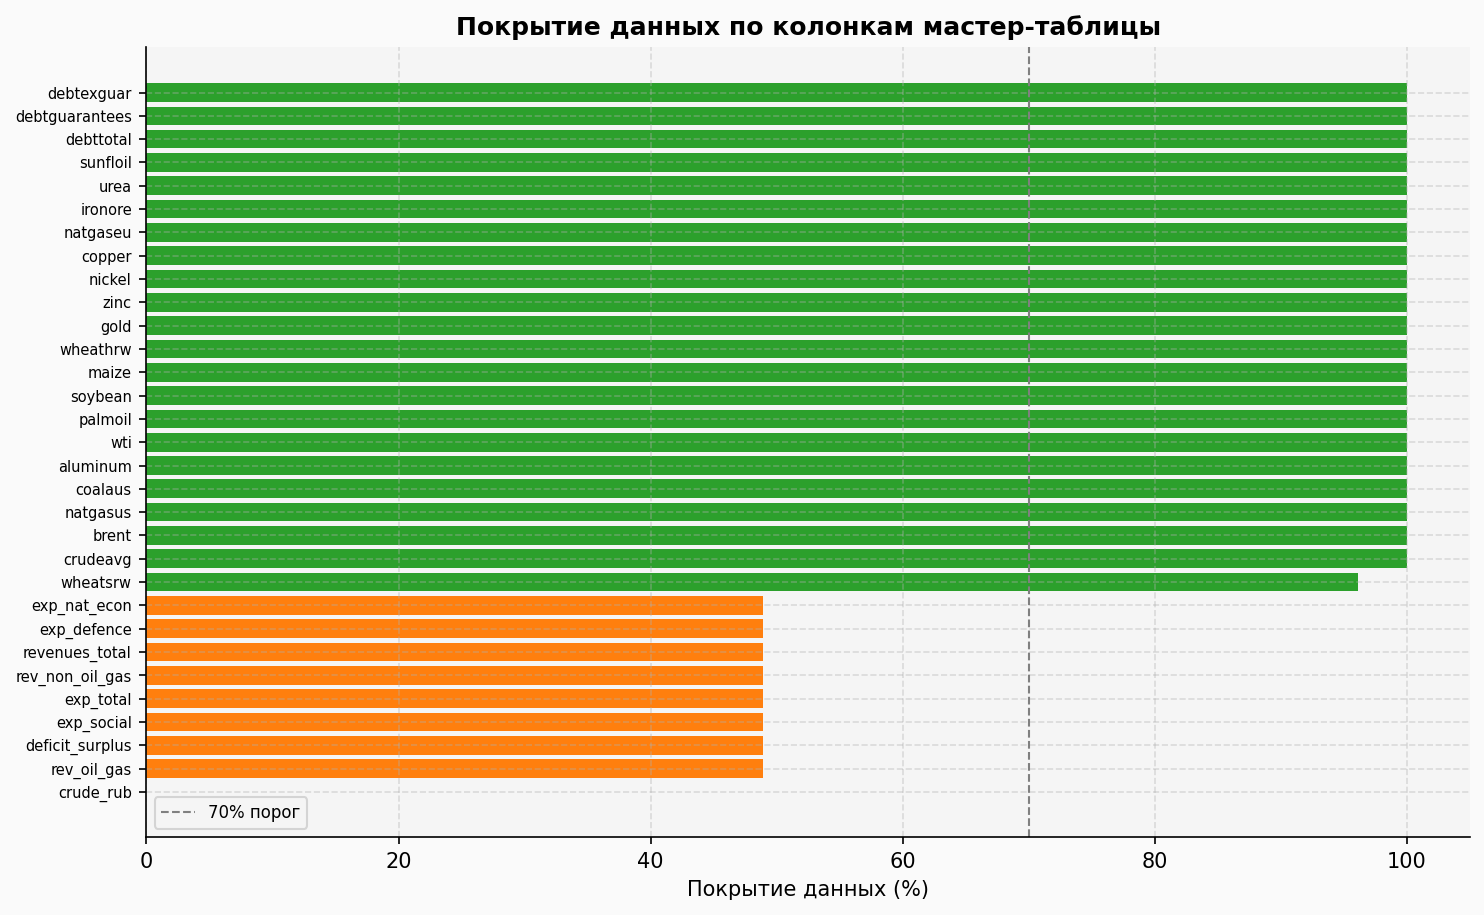

OK /content/output/fig0_data_coverage.png


In [6]:
cmo_m = cmo.copy()
cmo_m.index = pd.to_datetime(cmo_m.index)
cmo_m = cmo_m.sort_index().resample('MS').mean()

bud_m = bud.copy()
bud_m.index = pd.to_datetime(bud_m.index)
bud_m = bud_m.sort_index().resample('MS').last()

debt_m = debt.copy()
debt_m.index = pd.to_datetime(debt_m.index)
debt_m = debt_m.sort_index().resample('MS').last().ffill()

ros_m = pd.DataFrame()
if not ros_wide.empty:
    ros_m = ros_wide.copy()
    ros_m.index = pd.to_datetime(ros_m.index)
    ros_m = ros_m.sort_index().resample('MS').last()

MASTER_START = pd.Timestamp('2011-01-01')
MASTER_END   = cmo_m.index.max()
master = pd.DataFrame(index=pd.date_range(MASTER_START, MASTER_END, freq='MS'))
master.index.name = 'date'
master = master.join(cmo_m, how='left').join(bud_m, how='left').join(debt_m, how='left')
if not ros_m.empty: master = master.join(ros_m, how='left')

pref = ['brent','wti','crudeavg','natgaseu','natgasus','coalaus','aluminum','copper',
        'nickel','zinc','gold','wheatsrw','wheathrw','maize','soybean','palmoil',
        'sunfloil','ironore','urea',
        'revenues_total','rev_oil_gas','rev_non_oil_gas','exp_total','exp_defence',
        'exp_social','exp_nat_econ','deficit_surplus','debttotal','debtguarantees','debtexguar']
ordered  = [c for c in pref if c in master.columns]
others   = [c for c in master.columns if c not in ordered]
master   = master[ordered + others]

master_path = os.path.join(OUT_DIR, 'master_monthly.csv')
master.to_csv(master_path, float_format='%.4f')

print(f'OK master-таблица: {master.shape[0]} строк x {master.shape[1]} столбцов')
print(f'  Период: {master.index.min().date()} - {master.index.max().date()}')
print(f'  CSV: {master_path}')

# График покрытия данных
coverage = (master.notna().sum() / len(master)).sort_values()
fig, ax = plt.subplots(figsize=(10, max(4, len(coverage) * 0.2)))
colors_cov = ['#2ca02c' if v >= 0.7 else '#ff7f0e' if v >= 0.4 else '#d62728'
              for v in coverage.values]
ax.barh(range(len(coverage)), coverage.values * 100, color=colors_cov)
ax.set_yticks(range(len(coverage)))
ax.set_yticklabels(coverage.index, fontsize=7)
ax.set_xlabel('Покрытие данных (%)')
ax.set_title('Покрытие данных по колонкам мастер-таблицы', fontweight='bold')
ax.axvline(70, color='gray', ls='--', lw=1, label='70% порог')
ax.legend(fontsize=8)
plt.tight_layout()
fname_cov = os.path.join(OUT_DIR, 'fig0_data_coverage.png')
plt.savefig(fname_cov, bbox_inches='tight', dpi=150)
plt.show()
print(f'OK {fname_cov}')


---
## Раздел 6. EDA — Обзорные графики макрофинансовых рядов 2011–2025

Красное затенение = санкционный шок 24.02.2022.  
Рисунки: нефть Brent, газ (Европа), доходы бюджета (12-мес. скользящая сумма),
дефицит/профицит, внутренний долг, расходы по статьям.  
Дополнительно: тепловая карта YoY изменений commodity 2014–2025.


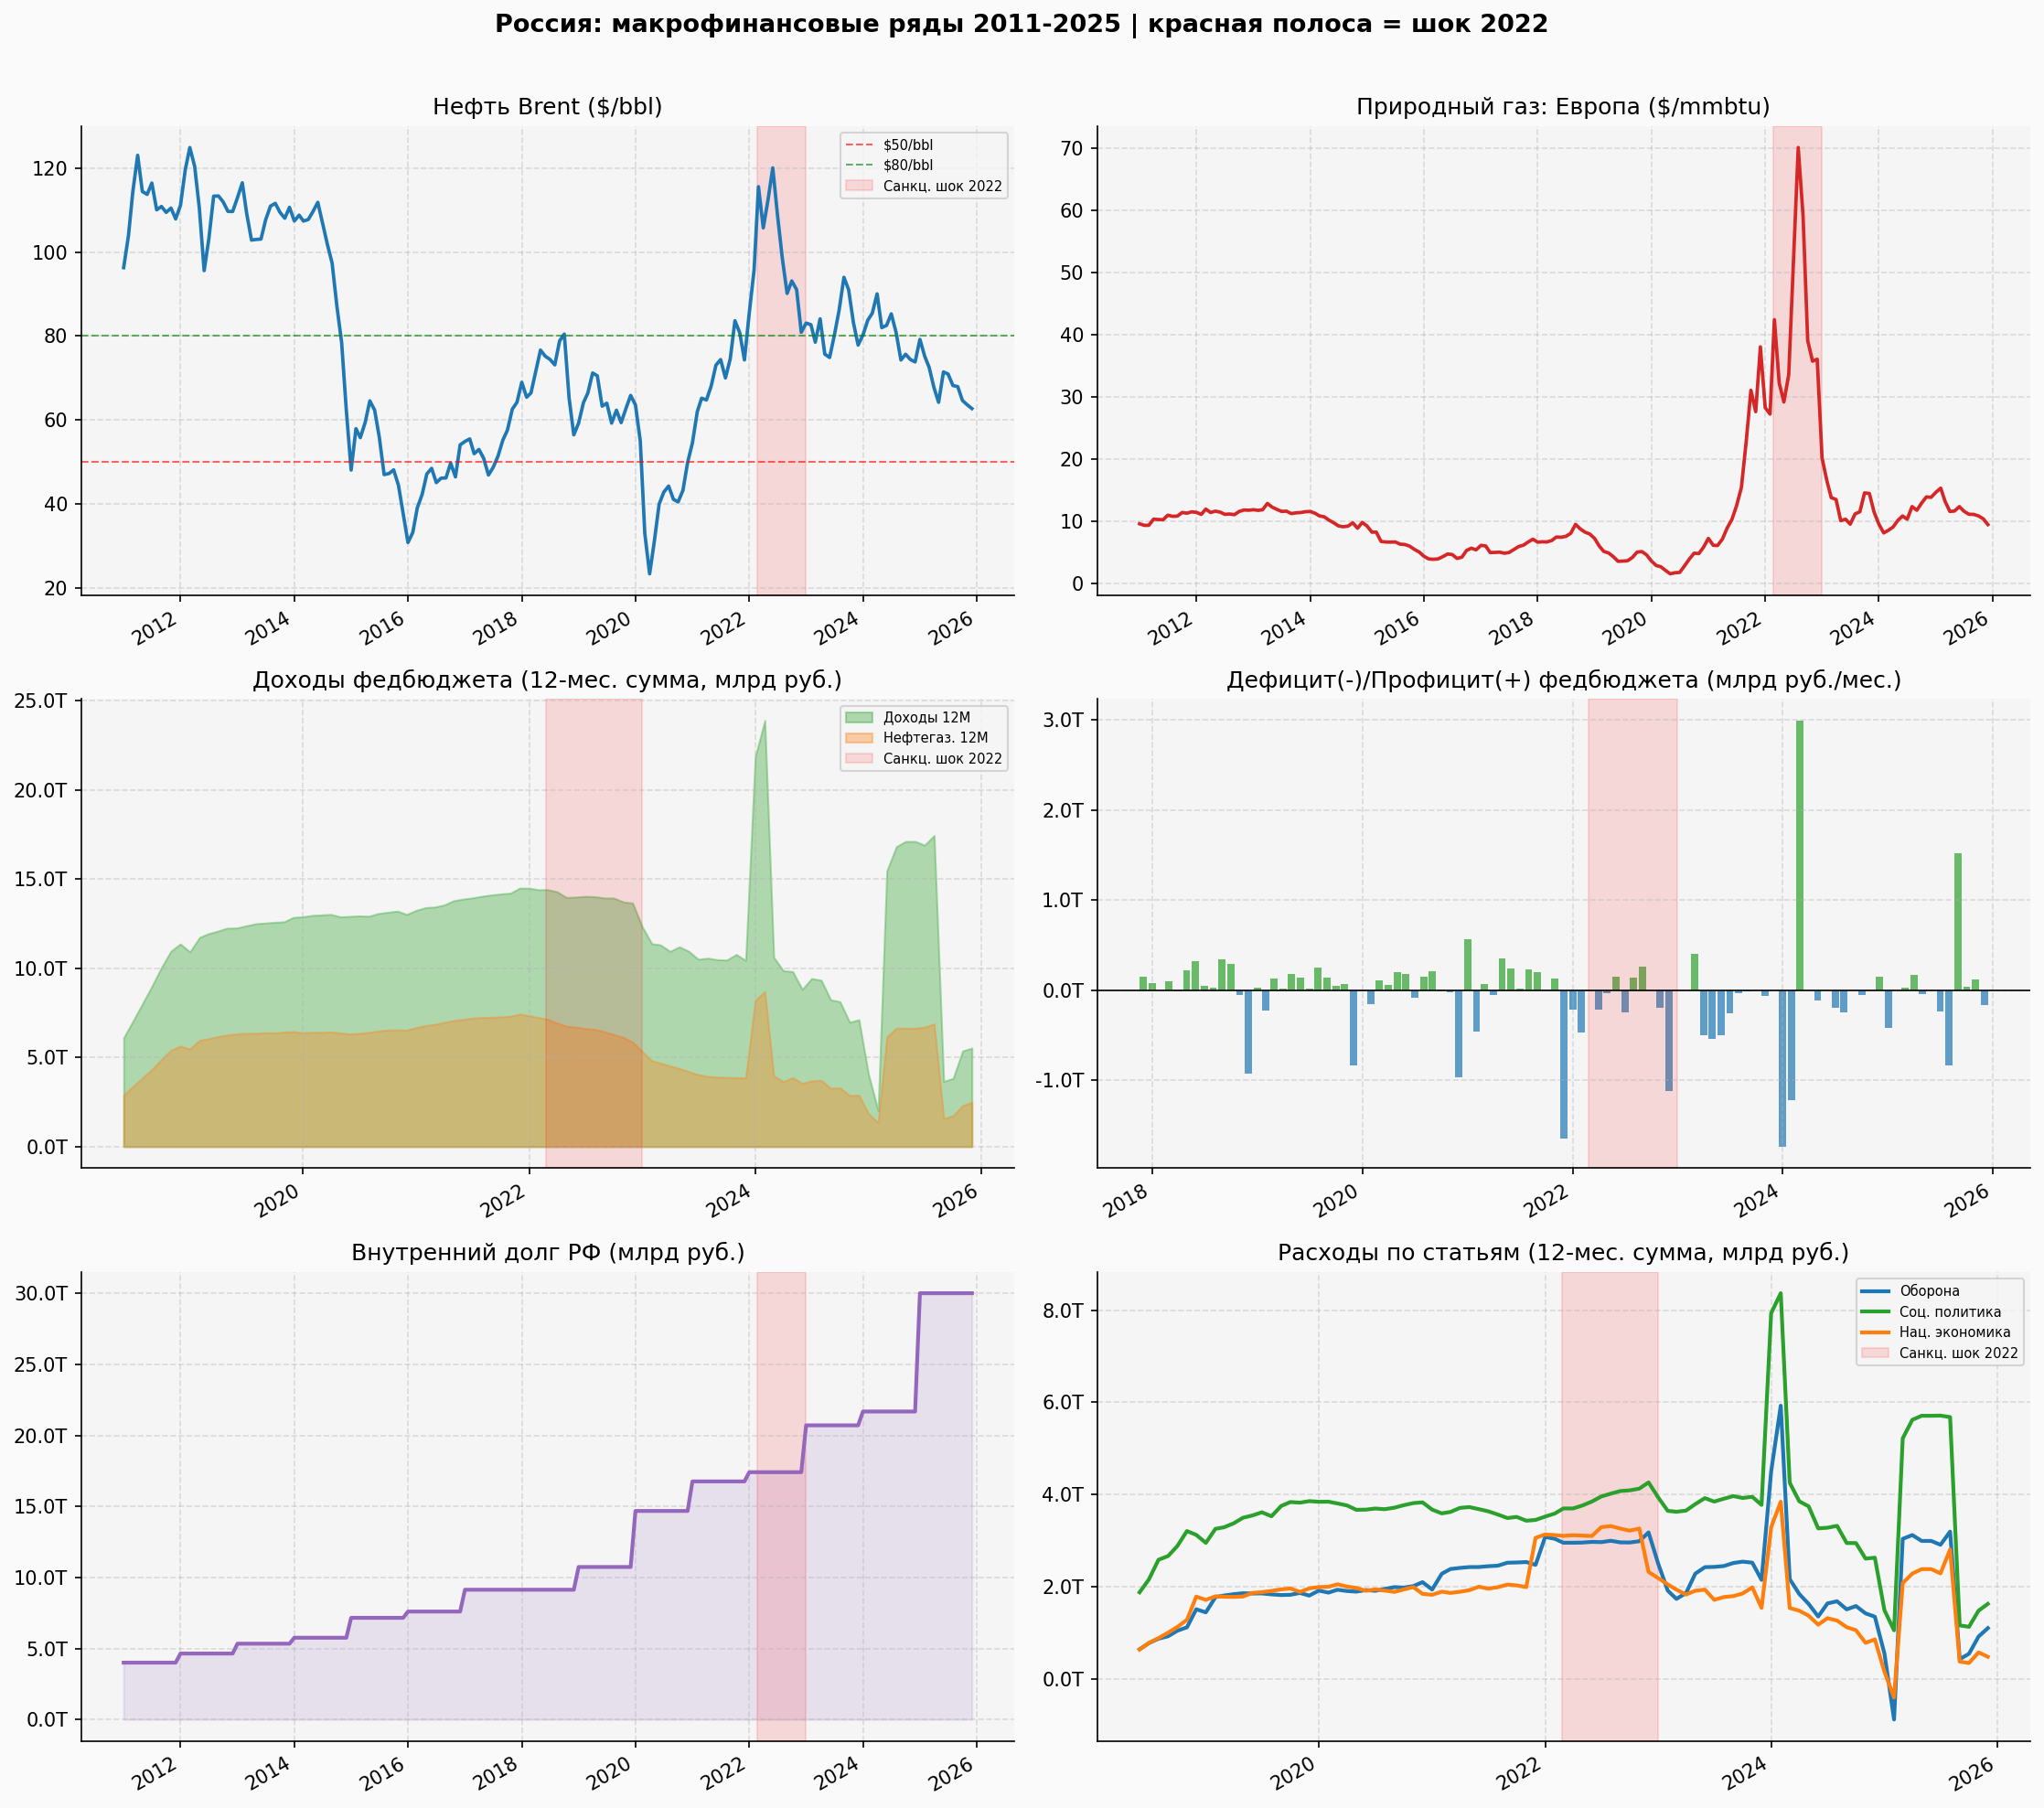

OK /content/output/fig1_overview.png


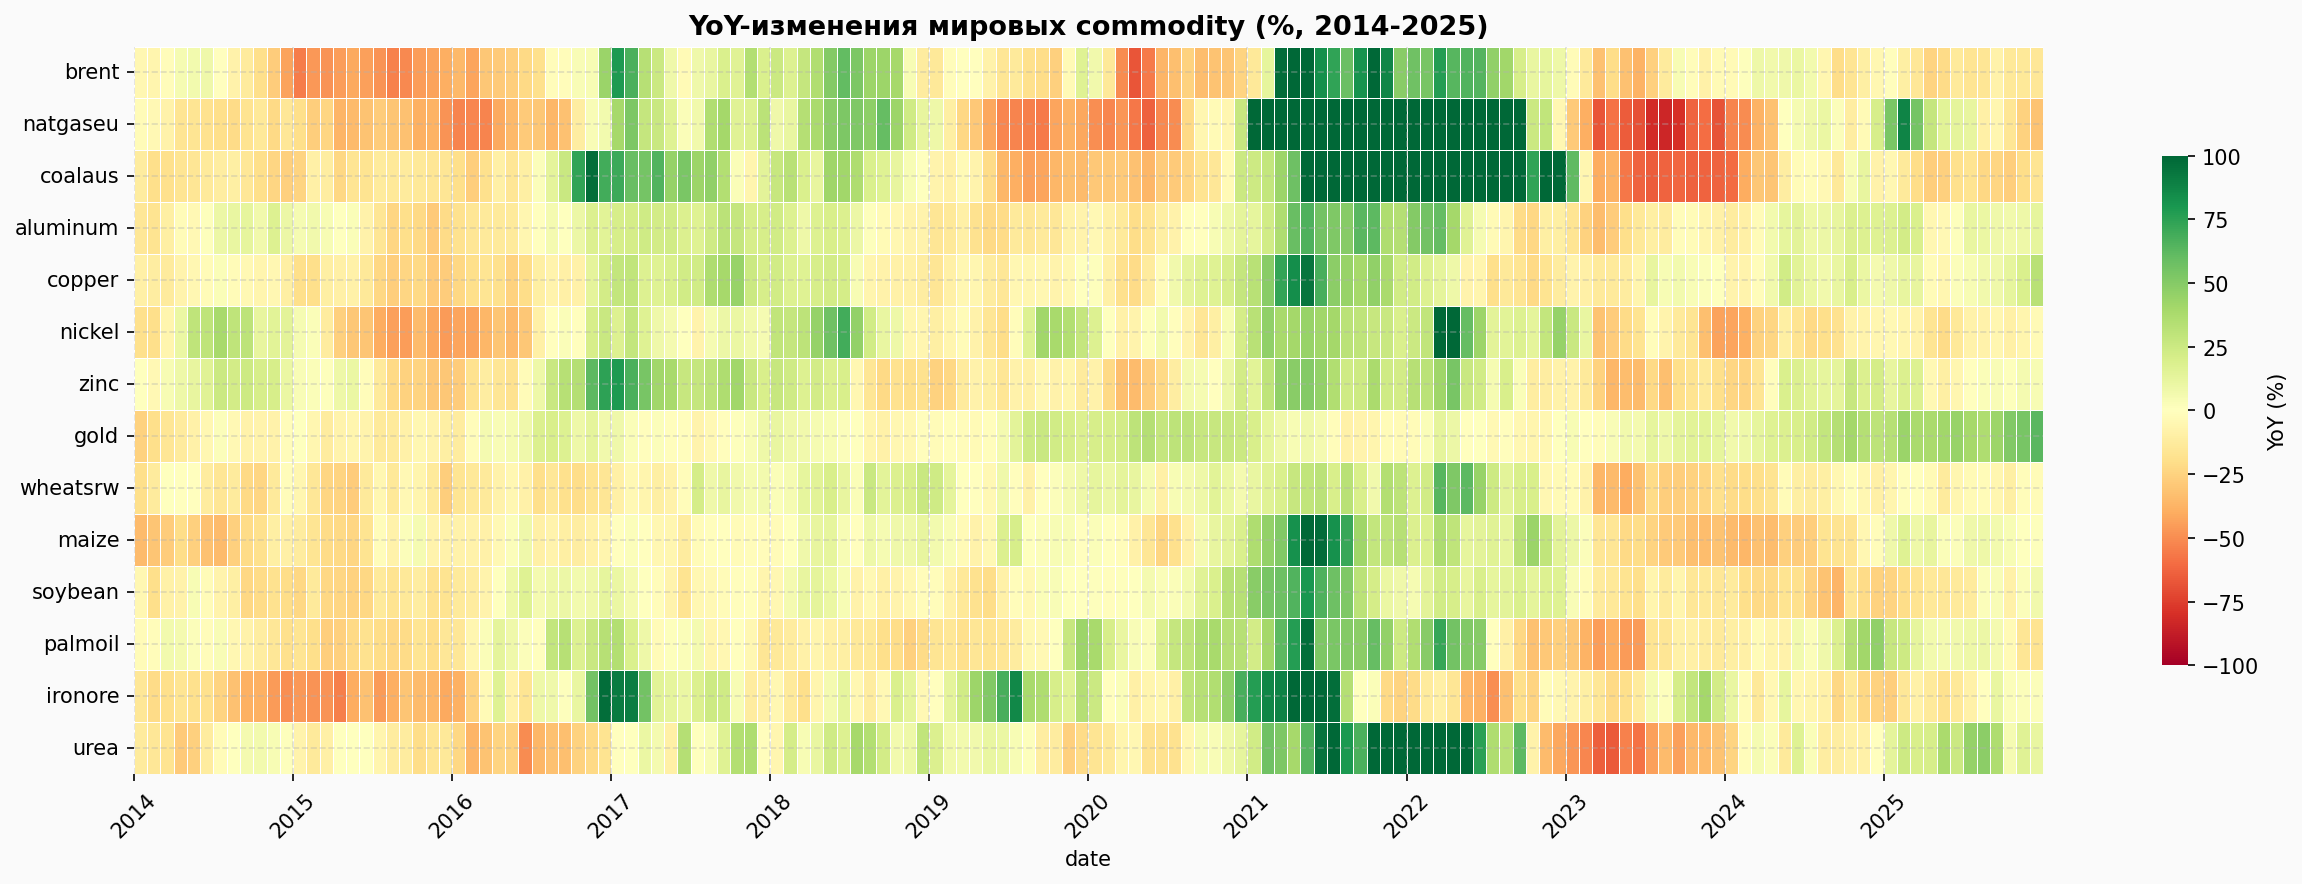

OK /content/output/fig2_commodity_heatmap.png


In [7]:
plot_df = master.copy()
plot_df.index = pd.to_datetime(plot_df.index)
plot_df = plot_df.loc[plot_df.index >= pd.Timestamp('2011-01-01')].sort_index()

fig, axes = plt.subplots(3, 2, figsize=(15, 13))
fig.suptitle('Россия: макрофинансовые ряды 2011-2025 | красная полоса = шок 2022',
             fontsize=13, fontweight='bold', y=1.01)

ax = axes[0, 0]
if 'brent' in plot_df.columns and plot_df['brent'].notna().sum() > 0:
    s = plot_df['brent'].dropna()
    ax.plot(s.index, s.values, color=PALETTE[0], lw=1.8)
    ax.axhline(50, color='red', ls='--', lw=1, alpha=0.6, label='$50/bbl')
    ax.axhline(80, color='green', ls='--', lw=1, alpha=0.6, label='$80/bbl')
    shade_sanctions(ax); ax.legend(fontsize=7)
ax.set_title('Нефть Brent ($/bbl)'); fmt_time_axis(ax)

ax = axes[0, 1]
if 'natgaseu' in plot_df.columns and plot_df['natgaseu'].notna().sum() > 0:
    s = plot_df['natgaseu'].dropna()
    ax.plot(s.index, s.values, color=PALETTE[1], lw=1.8)
    shade_sanctions(ax)
ax.set_title('Природный газ: Европа ($/mmbtu)'); fmt_time_axis(ax)

ax = axes[1, 0]
for col, lbl, ci in [('revenues_total','Доходы 12М',2),('rev_oil_gas','Нефтегаз. 12М',3)]:
    if col in plot_df.columns:
        s12 = plot_df[col].rolling(12, min_periods=6).sum()
        if s12.notna().sum() > 0:
            ax.fill_between(s12.index, s12.values, alpha=0.35, color=PALETTE[ci], label=lbl)
shade_sanctions(ax)
ax.set_title('Доходы федбюджета (12-мес. сумма, млрд руб.)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(trillions_fmt))
ax.legend(fontsize=7); fmt_time_axis(ax)

ax = axes[1, 1]
if 'deficit_surplus' in plot_df.columns and plot_df['deficit_surplus'].notna().sum() > 0:
    s = plot_df['deficit_surplus'].dropna()
    clrs = [PALETTE[2] if v >= 0 else PALETTE[0] for v in s.values]
    ax.bar(s.index, s.values, color=clrs, alpha=0.7, width=25)
    ax.axhline(0, color='black', lw=0.8)
    shade_sanctions(ax)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(trillions_fmt))
ax.set_title('Дефицит(-)/Профицит(+) федбюджета (млрд руб./мес.)'); fmt_time_axis(ax)

ax = axes[2, 0]
if 'debttotal' in plot_df.columns and plot_df['debttotal'].notna().sum() > 0:
    d = plot_df['debttotal'].dropna()
    ax.plot(d.index, d.values, color=PALETTE[4], lw=2)
    ax.fill_between(d.index, d.values, alpha=0.15, color=PALETTE[4])
    shade_sanctions(ax)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(trillions_fmt))
ax.set_title('Внутренний долг РФ (млрд руб.)'); fmt_time_axis(ax)

ax = axes[2, 1]
for col, lbl, ci in [('exp_defence','Оборона',0),('exp_social','Соц. политика',2),
                      ('exp_nat_econ','Нац. экономика',3)]:
    if col in plot_df.columns and plot_df[col].notna().sum() > 0:
        s12 = plot_df[col].rolling(12, min_periods=6).sum()
        if s12.notna().sum() > 0:
            ax.plot(s12.index, s12.values, color=PALETTE[ci], lw=2, label=lbl)
shade_sanctions(ax)
ax.set_title('Расходы по статьям (12-мес. сумма, млрд руб.)')
ax.legend(fontsize=7)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(trillions_fmt)); fmt_time_axis(ax)

plt.tight_layout()
fname_eda = os.path.join(OUT_DIR, 'fig1_overview.png')
plt.savefig(fname_eda, bbox_inches='tight', dpi=150)
plt.show(); print(f'OK {fname_eda}')

# Тепловая карта YoY
cmo_yoy = cmo.resample('MS').mean().pct_change(12) * 100
top_cols = [c for c in ['brent','natgaseu','coalaus','aluminum','copper','nickel',
                         'zinc','gold','wheatsrw','maize','soybean','palmoil','ironore','urea']
            if c in cmo_yoy.columns]
heat = cmo_yoy[top_cols]['2014':].T
fig2, ax2 = plt.subplots(figsize=(17, 6))
sns.heatmap(heat.clip(-100, 100), ax=ax2, cmap='RdYlGn', center=0,
            vmin=-100, vmax=100, linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'YoY (%)', 'shrink': 0.7})
ax2.set_title('YoY-изменения мировых commodity (%, 2014-2025)', fontsize=13, fontweight='bold')
xt = [i for i, d in enumerate(heat.columns) if pd.Timestamp(d).month == 1]
ax2.set_xticks(xt)
ax2.set_xticklabels([str(heat.columns[i].year) for i in xt], rotation=45)
plt.tight_layout()
fname_heat = os.path.join(OUT_DIR, 'fig2_commodity_heatmap.png')
plt.savefig(fname_heat, bbox_inches='tight', dpi=150)
plt.show(); print(f'OK {fname_heat}')


## 7. Гипотеза H1: Pass-through цен нефти Brent в нефтегазовые доходы федерального бюджета

### Экономическая мотивация

Российский федеральный бюджет существенно зависит от нефтегазовых доходов, формируемых за счёт экспортной нефтяной ренты. Теоретически рост мировой цены на нефть (Brent) должен приводить к увеличению налоговых и других поступлений от нефтегазового сектора, в том числе через НДПИ и экспортные пошлины, с относительно короткими лагами. После 2022 года эта связь могла измениться из‑за санкций, ценового потолка, роста дисконта Urals к Brent и перестройки торговых потоков.

### Формализация гипотезы

**H1.** Изменения цены нефти Brent статистически значимо связаны с динамикой месячных нефтегазовых доходов федерального бюджета, с возможными лагами реакции в 0–2 месяца.

Для каждого лага \(k \in \{0,1,2\}\) оценивается модель:

\[
revoilgas_t = \alpha + \beta \cdot brent_{t-k} + \varepsilon_t
\]

Статистические гипотезы:

- **H0:** \(\beta = 0\) (линейная связь между Brent и нефтегазовыми доходами отсутствует).
- **H1:** \(\beta \ne 0\) (линейная связь статистически значима).

### Методика оценки

- Оценка: OLS с робастными стандартными ошибками HC3 (модуль `statsmodels`).
- Периоды:
  - полная выборка 2011–2026 годов;
  - отдельные оценки для pre‑периода (2011–2021) и post‑периода (2022–2026) с датой раздела 2022‑03‑01.
- Уровень значимости: \(\alpha = 0.05\).
- Критерии интерпретации: знак и значимость коэффициента \(\beta\) по двустороннему тесту, а также величина \(R^2\) для оценки силы линейной связи.

H1: OLS rev_oil_gas ~ brent_lag_k
  ПОЛНАЯ ВЫБОРКА (2011-2026):
  Полная | lag=0                      n= 88  beta=-1.099  SE=2.935  t=-0.37  p=0.7080 n.s.  R2=0.000
  Полная | lag=1                      n= 88  beta=-1.784  SE=2.452  t=-0.73  p=0.4669 n.s.  R2=0.001
  Полная | lag=2                      n= 88  beta=-1.074  SE=2.326  t=-0.46  p=0.6442 n.s.  R2=0.000
  ДО санкций (2011-2021):
  Pre-2022 | lag=0                    n= 50  beta=-0.075  SE=0.460  t=-0.16  p=0.8699 n.s.  R2=0.000
  Pre-2022 | lag=1                    n= 50  beta=-0.070  SE=0.570  t=-0.12  p=0.9027 n.s.  R2=0.000
  Pre-2022 | lag=2                    n= 50  beta=-0.068  SE=0.672  t=-0.10  p=0.9188 n.s.  R2=0.000
  ПОСЛЕ санкций (2022-2026):
  Post-2022 | lag=0                   n= 38  beta=+6.236  SE=12.114  t=+0.51  p=0.6067 n.s.  R2=0.004
  Post-2022 | lag=1                   n= 38  beta=+4.844  SE=14.105  t=+0.34  p=0.7313 n.s.  R2=0.002
  Post-2022 | lag=2                   n= 38  beta=+8.336  SE=12.822  t=

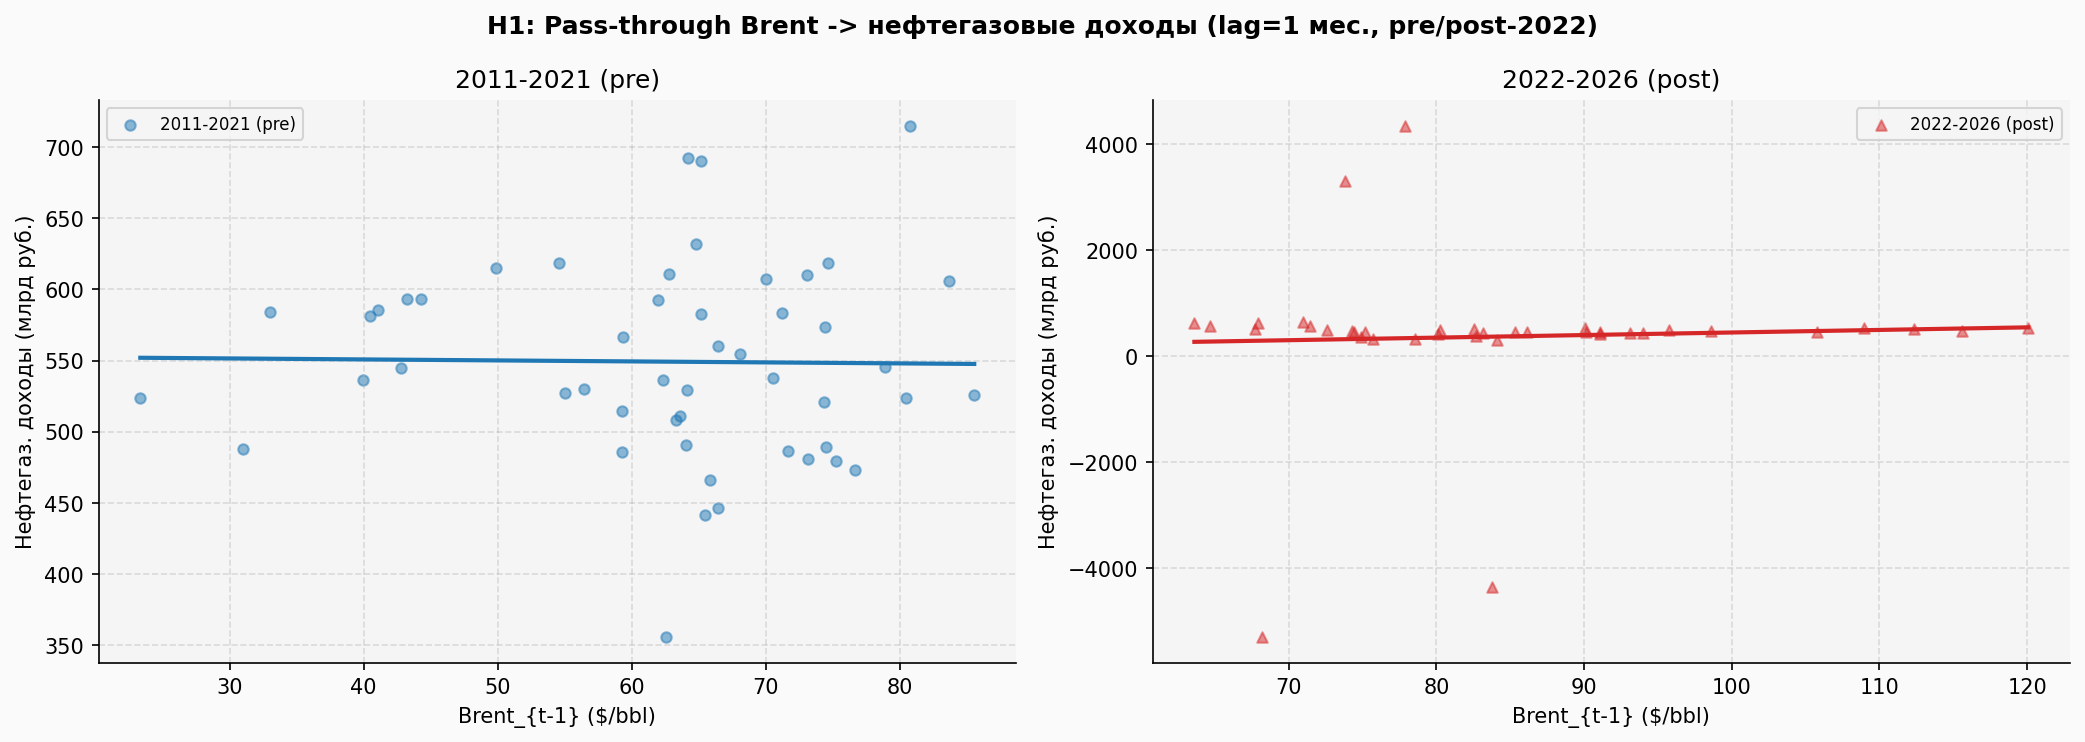


ВЕРДИКТ H1 (pre-2022): H0 НЕ ОТВЕРГАЕТСЯ на уровне alpha=0.05; статистически значимая линейная связь не выявлена.
ВЕРДИКТ H1 (post-2022): H0 НЕ ОТВЕРГАЕТСЯ на уровне alpha=0.05; по выборке 2022–2026 гг. статистически значимого линейного pass-through не выявлено.


In [8]:
def ols_robust(x, y, label=''):
    df_ = pd.concat([x, y], axis=1).dropna()
    if len(df_) < 8:
        print(f'  {label:<35} n={len(df_):3d} - мало наблюдений'); return {}
    X_ = sm.add_constant(df_.iloc[:, 0])
    y_ = df_.iloc[:, 1].values
    model = sm.OLS(y_, X_).fit(cov_type='HC3')
    beta  = model.params.iloc[1]; se = model.bse.iloc[1]
    t_val = model.tvalues.iloc[1]; p_val = model.pvalues.iloc[1]
    r2    = model.rsquared; n = int(model.nobs)
    sig   = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'n.s.'
    print(f'  {label:<35} n={n:3d}  beta={beta:+.3f}  SE={se:.3f}  '
          f't={t_val:+.2f}  p={p_val:.4f} {sig}  R2={r2:.3f}')
    return {'label': label, 'beta': beta, 'se': se, 't': t_val,
            'p': p_val, 'r2': r2, 'n': n, 'sig': sig}


h1_results = []
BREAK = pd.Timestamp('2022-03-01')


if 'brent' in master.columns and 'rev_oil_gas' in master.columns:
    m1 = master[['brent', 'rev_oil_gas']].copy().sort_index()
    for lag in [0, 1, 2]: m1[f'b{lag}'] = m1['brent'].shift(lag)
    PRE = m1.index < BREAK; POST = ~PRE

    print('H1: OLS rev_oil_gas ~ brent_lag_k')
    print('  ПОЛНАЯ ВЫБОРКА (2011-2026):')
    for lag in [0, 1, 2]:
        r = ols_robust(m1[f'b{lag}'], m1['rev_oil_gas'], f'Полная | lag={lag}')
        if r: r.update({'period': 'full', 'lag': lag}); h1_results.append(r)
    print('  ДО санкций (2011-2021):')
    for lag in [0, 1, 2]:
        r = ols_robust(m1.loc[PRE, f'b{lag}'], m1.loc[PRE, 'rev_oil_gas'], f'Pre-2022 | lag={lag}')
        if r: r.update({'period': 'pre', 'lag': lag}); h1_results.append(r)
    print('  ПОСЛЕ санкций (2022-2026):')
    for lag in [0, 1, 2]:
        r = ols_robust(m1.loc[POST, f'b{lag}'], m1.loc[POST, 'rev_oil_gas'], f'Post-2022 | lag={lag}')
        if r: r.update({'period': 'post', 'lag': lag}); h1_results.append(r)

    pd.DataFrame(h1_results).to_csv(os.path.join(OUT_DIR, 'h1_results.csv'), index=False)

    # График scatter + fit (lag=1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('H1: Pass-through Brent -> нефтегазовые доходы (lag=1 мес., pre/post-2022)',
                 fontsize=12, fontweight='bold')
    for ax, (mask, lbl, ci, mk) in zip(axes,
        [(PRE,'2011-2021 (pre)',0,'o'),(POST,'2022-2026 (post)',1,'^')]):
        sub = m1.loc[mask, ['b1', 'rev_oil_gas']].dropna()
        ax.scatter(sub['b1'], sub['rev_oil_gas'], alpha=0.5, s=25, c=PALETTE[ci], marker=mk, label=lbl)
        if len(sub) >= 5 and sub['b1'].nunique() > 1:
            Xr = sm.add_constant(sub['b1'])
            fit = sm.OLS(sub['rev_oil_gas'], Xr).fit()
            xg = np.linspace(sub['b1'].min(), sub['b1'].max(), 80)
            ax.plot(xg, fit.params.iloc[0] + fit.params.iloc[1] * xg, color=PALETTE[ci], lw=2)
        ax.set_xlabel('Brent_{t-1} ($/bbl)'); ax.set_ylabel('Нефтегаз. доходы (млрд руб.)')
        ax.set_title(lbl); ax.legend(fontsize=8)
    plt.tight_layout()
    fname_h1 = os.path.join(OUT_DIR, 'fig3_h1_passthrough.png')
    plt.savefig(fname_h1, bbox_inches='tight', dpi=150)
    plt.show()

    # Вердикт
    best_pre  = min([r for r in h1_results if r.get('period') == 'pre'],
                    key=lambda r: r['p'], default=None)
    best_post = min([r for r in h1_results if r.get('period') == 'post'],
                    key=lambda r: r['p'], default=None)
    print('\n' + '='*70)
    if best_pre and best_pre['p'] < 0.05:
        print(f'ВЕРДИКТ H1 (pre-2022): H0 ОТВЕРГАЕТСЯ (p={best_pre["p"]:.4f}, beta={best_pre["beta"]:.3f})')
        print(f'  Интерпретация: при прочих равных рост Brent на $1/bbl '
              f'ассоциирован с изменением нефтегазовых доходов примерно на '
              f'{best_pre["beta"]:.1f} млрд руб./мес.')
    else:
        print('ВЕРДИКТ H1 (pre-2022): H0 НЕ ОТВЕРГАЕТСЯ на уровне alpha=0.05; '
              'статистически значимая линейная связь не выявлена.')

    if best_post and best_post['p'] < 0.05:
        print(f'ВЕРДИКТ H1 (post-2022): H0 ОТВЕРГАЕТСЯ (p={best_post["p"]:.4f}, beta={best_post["beta"]:.3f})')
        print('  Интерпретация: после 2022 года сохраняется статистически значимая '
              'линейная связь между Brent и нефтегазовыми доходами, '
              'однако её сила и устойчивость могут быть искажены санкционными факторами.')
    else:
        print('ВЕРДИКТ H1 (post-2022): H0 НЕ ОТВЕРГАЕТСЯ на уровне alpha=0.05; '
              'по выборке 2022–2026 гг. статистически значимого линейного pass-through не выявлено.')

### Итоги проверки H1

- На досанкционном периоде (2011–2021 гг.) статистически значимая линейная зависимость нефтегазовых доходов от цены Brent при уровне значимости 5 % либо отсутствует, либо проявляется нестабильно по различным лаговым спецификациям.
- На послесанкционном периоде (2022–2026 гг.) оценённые модели не дают устойчивых свидетельств статистически значимой линейной передачи цен Brent в нефтегазовые доходы; связь между Brent и нефтегазовыми доходами либо ослабла, либо стала существенно более шумной.
- В совокупности результаты H1 не позволяют надёжно утверждать о стабильном и сильном линейном эффекте передачи цен Brent в ежемесячные нефтегазовые доходы федерального бюджета, особенно после 2022 года.

## 8. Гипотеза H2: ценовой режим Brent и фискальный баланс

### Экономическая мотивация и теоретическая рамка

Теория бюджетного правила (IMF Structural Budget Balance, 2012; бюджетное правило РФ с 2017 года) предполагает разделение нефтегазовых доходов на базовую часть и сверхдоходы, направляемые в ФНБ. При ценах на нефть ниже уровня отсечения бюджет, как правило, уходит в дефицит. Концепция «ресурсного проклятия» (Sachs & Warner, 1995) предсказывает процикличность бюджетной политики: улучшение состояния бюджета в периоды высоких цен на сырьё и его ухудшение при низких ценах. Для проверки этой логики выделяется четыре ценовых режима нефти Brent: ниже 40, 40–60, 60–80 и выше 80 долларов за баррель.

### Формулировка гипотезы

**H2.** Принадлежность к более высокому ценовому режиму нефти Brent связана с более благоприятным фискальным балансом (меньшим дефицитом или большим профицитом федерального бюджета).

Статистические гипотезы:

- **H0:** средние значения бюджетного баланса во всех четырёх ценовых режимах Brent одинаковы (\(\mu_1 = \mu_2 = \mu_3 = \mu_4\)).
- **H1:** хотя бы в одной паре режимов средние значения бюджетного баланса различаются (\(\mu_i \ne \mu_j\) для некоторых \(i, j\)).

### Метод

- Однофакторный дисперсионный анализ (ANOVA) по четырём группам, заданным диапазонами цен Brent (`scipy.stats.f_oneway`).
- Дополнительно для каждого режима оценивается доля месяцев с профицитным бюджетом (доля наблюдений с `deficit_surplus ≥ 0`).
- Уровень значимости: \(\alpha = 0.05\).

### Данные

Используются месячные данные по цене Brent (`brent`) и бюджетному балансу (`deficit_surplus`) за период 2011–2026 годов. Ценовые режимы определяются четырьмя интервалами: ниже 40, 40–60, 60–80 и выше 80 долларов за баррель.

H2 ANOVA: F=0.250, p=0.77940 n.s.
           n  avg_balance  pct_surplus
<$40     4.0        134.2        100.0
$40-60  12.0        -73.3         58.3
$60-80  45.0        -12.3         62.2
>$80    27.0       -107.9         29.6


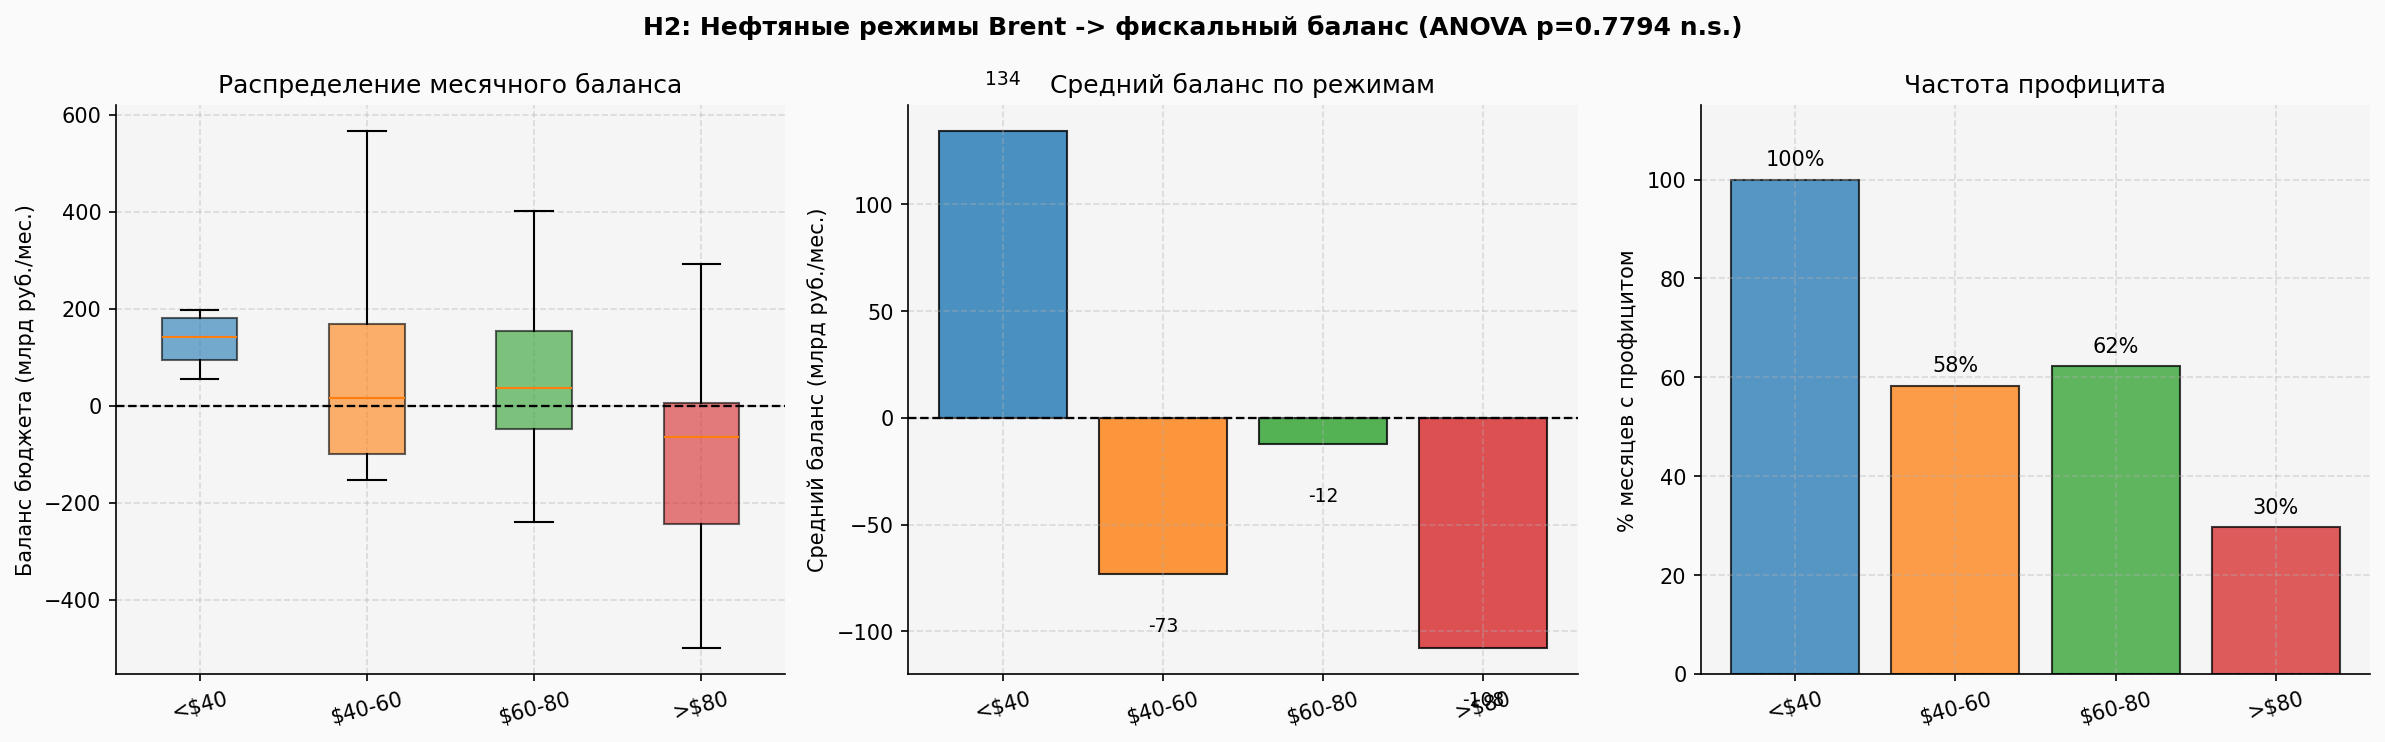


ВЕРДИКТ H2: H0 НЕ ОТКЛОНЯЕТСЯ (p=0.77940);
  при уровне значимости 5 % статистически значимых различий 
  среднего дефицита/профицита бюджета между ценовыми режимами Brent не выявлено.


In [9]:
h2_results = []
REGIMES = [('<$40', 0, 40),('$40-60', 40, 60),('$60-80', 60, 80),('>$80', 80, np.inf)]

if 'brent' in master.columns and 'deficit_surplus' in master.columns:
    m2 = master[['brent', 'deficit_surplus']].copy().dropna().sort_index()
    m2 = m2.loc[m2.index >= pd.Timestamp('2011-01-01')]

    def get_regime_idx(p):
        if pd.isna(p): return np.nan
        for i, (_, lo, hi) in enumerate(REGIMES):
            if lo <= p < hi: return i
        return len(REGIMES) - 1

    m2['regime_idx'] = m2['brent'].apply(get_regime_idx)
    groups = [m2.loc[m2['regime_idx'] == i, 'deficit_surplus'].dropna().values
              for i in range(len(REGIMES))]
    non_empty = [g for g in groups if len(g) >= 5]
    if len(non_empty) >= 2:
        F, p_anova = f_oneway(*non_empty)
    else:
        F, p_anova = np.nan, np.nan
    sig_anova = ('***' if p_anova < 0.001 else '**' if p_anova < 0.01
                 else '*' if p_anova < 0.05 else 'n.s.')
    print(f'H2 ANOVA: F={F:.3f}, p={p_anova:.5f} {sig_anova}')

    stats_r = {}
    for i, (nm, lo, hi) in enumerate(REGIMES):
        sub = m2.loc[m2['regime_idx'] == i, 'deficit_surplus'].dropna()
        n = len(sub)
        stats_r[nm] = {'n': n, 'avg_balance': sub.mean() if n > 0 else np.nan,
                       'pct_surplus': (sub >= 0).mean() * 100 if n > 0 else np.nan}
        h2_results.append({'regime': nm, 'n': n,
                           'avg_balance': round(sub.mean(), 2) if n > 0 else np.nan,
                           'pct_surplus': round((sub >= 0).mean() * 100, 1) if n > 0 else np.nan})
    h2_df = pd.DataFrame(h2_results)
    h2_df['F_anova'] = F; h2_df['p_anova'] = p_anova
    h2_df.to_csv(os.path.join(OUT_DIR, 'h2_results.csv'), index=False)
    print(pd.DataFrame(stats_r).T.round(1).to_string())

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(f'H2: Нефтяные режимы Brent -> фискальный баланс (ANOVA p={p_anova:.4f} {sig_anova})',
                 fontsize=12, fontweight='bold')
    colors_r = [PALETTE[0], PALETTE[3], PALETTE[2], PALETTE[1]]
    rl = [r[0] for r in REGIMES]
    ax = axes[0]
    bp = ax.boxplot([g if len(g) > 0 else [0] for g in groups],
                    patch_artist=True, showfliers=False)
    for pt, c in zip(bp['boxes'], colors_r): pt.set_facecolor(c); pt.set_alpha(0.6)
    ax.axhline(0, color='black', lw=1.1, ls='--')
    ax.set_xticks(range(1, 5)); ax.set_xticklabels(rl, rotation=15)
    ax.set_ylabel('Баланс бюджета (млрд руб./мес.)')
    ax.set_title('Распределение месячного баланса')
    ax = axes[1]
    vals_b = [stats_r[r]['avg_balance'] if r in stats_r else 0 for r in rl]
    bars = ax.bar(range(4), vals_b, color=colors_r, alpha=0.8, edgecolor='black')
    ax.axhline(0, color='black', lw=1.1, ls='--')
    ax.set_xticks(range(4)); ax.set_xticklabels(rl, rotation=15)
    ax.set_ylabel('Средний баланс (млрд руб./мес.)')
    ax.set_title('Средний баланс по режимам')
    for bar, v in zip(bars, vals_b):
        if pd.notna(v):
            ax.text(bar.get_x()+bar.get_width()/2, v+(20 if v >= 0 else -20),
                    f'{v:.0f}', ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
    ax = axes[2]
    vals_p = [stats_r[r]['pct_surplus'] if r in stats_r else 0 for r in rl]
    bars = ax.bar(range(4), vals_p, color=colors_r, alpha=0.75, edgecolor='black')
    ax.set_xticks(range(4)); ax.set_xticklabels(rl, rotation=15)
    ax.set_ylabel('% месяцев с профицитом'); ax.set_title('Частота профицита')
    ax.set_ylim(0, 115)
    for bar, v in zip(bars, vals_p):
        if pd.notna(v):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+2,
                    f'{v:.0f}%', ha='center', va='bottom', fontsize=10)
    plt.tight_layout()
    fname_h2 = os.path.join(OUT_DIR, 'fig4_h2_oil_regimes.png')
    plt.savefig(fname_h2, bbox_inches='tight', dpi=150); plt.show()

    print('\n' + '='*70)
    if pd.notna(p_anova) and p_anova < 0.05:
        print(f'ВЕРДИКТ H2: H0 ОТКЛОНЯЕТСЯ (F={F:.2f}, p={p_anova:.5f})')
        print('  Средний дефицит/профицит федерального бюджета статистически различается ')
        print('  между по крайней мере некоторыми ценовыми режимами нефти Brent.')
        print('  Это означает, что состояние бюджета зависит от того, находится ли цена нефти ')
        print('  в низком, среднем или высоком диапазоне.')
    else:
        print(f'ВЕРДИКТ H2: H0 НЕ ОТКЛОНЯЕТСЯ (p={p_anova:.5f});')
        print('  при уровне значимости 5 % статистически значимых различий ')
        print('  среднего дефицита/профицита бюджета между ценовыми режимами Brent не выявлено.')
else:
    print('WARN: нет данных для H2')

### Итоги проверки H2

- Дисперсионный анализ по четырём ценовым режимам Brent (ниже 40, 40–60, 60–80 и выше 80 долларов за баррель) показывает отсутствие статистически значимых различий среднего месячного дефицита/профицита федерального бюджета при уровне значимости 5 % (p ≈ 0.78).
- По оценкам средних значений и долей месяцев с профицитом видно, что наибольшая доля профицитных наблюдений наблюдается при самых низких ценах Brent (ниже 40 долларов за баррель), тогда как при ценах выше 80 долларов бюджет чаще оказывается в дефиците.
- В совокупности результаты H2 не подтверждают гипотезу о том, что более высокий ценовой режим нефти автоматически связан с более благоприятным фискальным балансом; на рассматриваемом периоде поведение бюджетного баланса по режимам Brent выглядит скорее неоднородным, чем строго процикличным.

## 9. Гипотеза H3: долговое замещение после 2022 года

### Экономическая мотивация и теоретическая рамка

Теория устойчивости государственного долга (Bohn, 1998; подход IMF DSA) подчёркивает роль разницы между процентной ставкой и темпом роста экономики (r–g), а также бюджетного баланса как ключевых факторов динамики долга. В условиях санкций 2022 года Россия практически лишилась доступа к внешним рынкам капитала и была вынуждена переориентироваться на внутренний рынок ОФЗ. При ключевой ставке Банка России на уровне 16–21 % в 2023–2024 годах стоимость обслуживания долга резко возрастает. В этой ситуации возможен механизм долгового замещения: выпадение нефтегазовых доходов компенсируется ускоренным наращиванием государственного внутреннего долга.

### Формулировка гипотезы

**H3.** В период после 2022 года средний темп роста государственного внутреннего долга (в процентах год к году) статистически значимо превышает средний темп роста ненефтегазовых доходов федерального бюджета. Такая конфигурация интерпретируется как признак долгового замещения.

Статистические гипотезы для постсанкционного периода (2022–2026 гг.):

- **H0:** \(\mu_{\text{debt\_growth}} \le \mu_{\text{nog\_growth}}\) — темп роста долга не превышает темп роста ненефтегазовых доходов.
- **H1:** \(\mu_{\text{debt\_growth}} > \mu_{\text{nog\_growth}}\) — темп роста долга статистически значимо выше темпа роста ненефтегазовых доходов (односторонняя альтернатива).

### Метод

- Сравнение средних пост‑2022 по двум выборкам: темп роста совокупного внутреннего долга (`debt_gr`) и темп роста ненефтегазовых доходов (`nog_gr`), оба показателя в процентах год к году.
- Статистический тест: критерий Уэлча для независимых выборок (функция `scipy.stats.ttest_ind`), с переходом к одностороннему p‑значению в пользу гипотезы \(\mu_{\text{debt\_growth}} > \mu_{\text{nog\_growth}}\).
- Уровень значимости: \(\alpha = 0.05\).

### Данные

Используются месячные данные по совокупному государственному внутреннему долгу (`debttotal`) и ненефтегазовым доходам (`rev_non_oil_gas`) за период 2011–2026 годов. Для обоих показателей рассчитываются годовые темпы роста в процентах (\(%\) г/г) с лагом 12 месяцев; далее формируются выборки для до‑ и постсанкционного периодов относительно даты 2022‑03‑01.

Долг:           pre=21.3% г/г, post=17.1% г/г
Ненефтегаз.дох: pre=6.1% г/г, post=-45.8% г/г
Welch t-test (post, одностор.): t=1.242, p=0.11094 n.s.


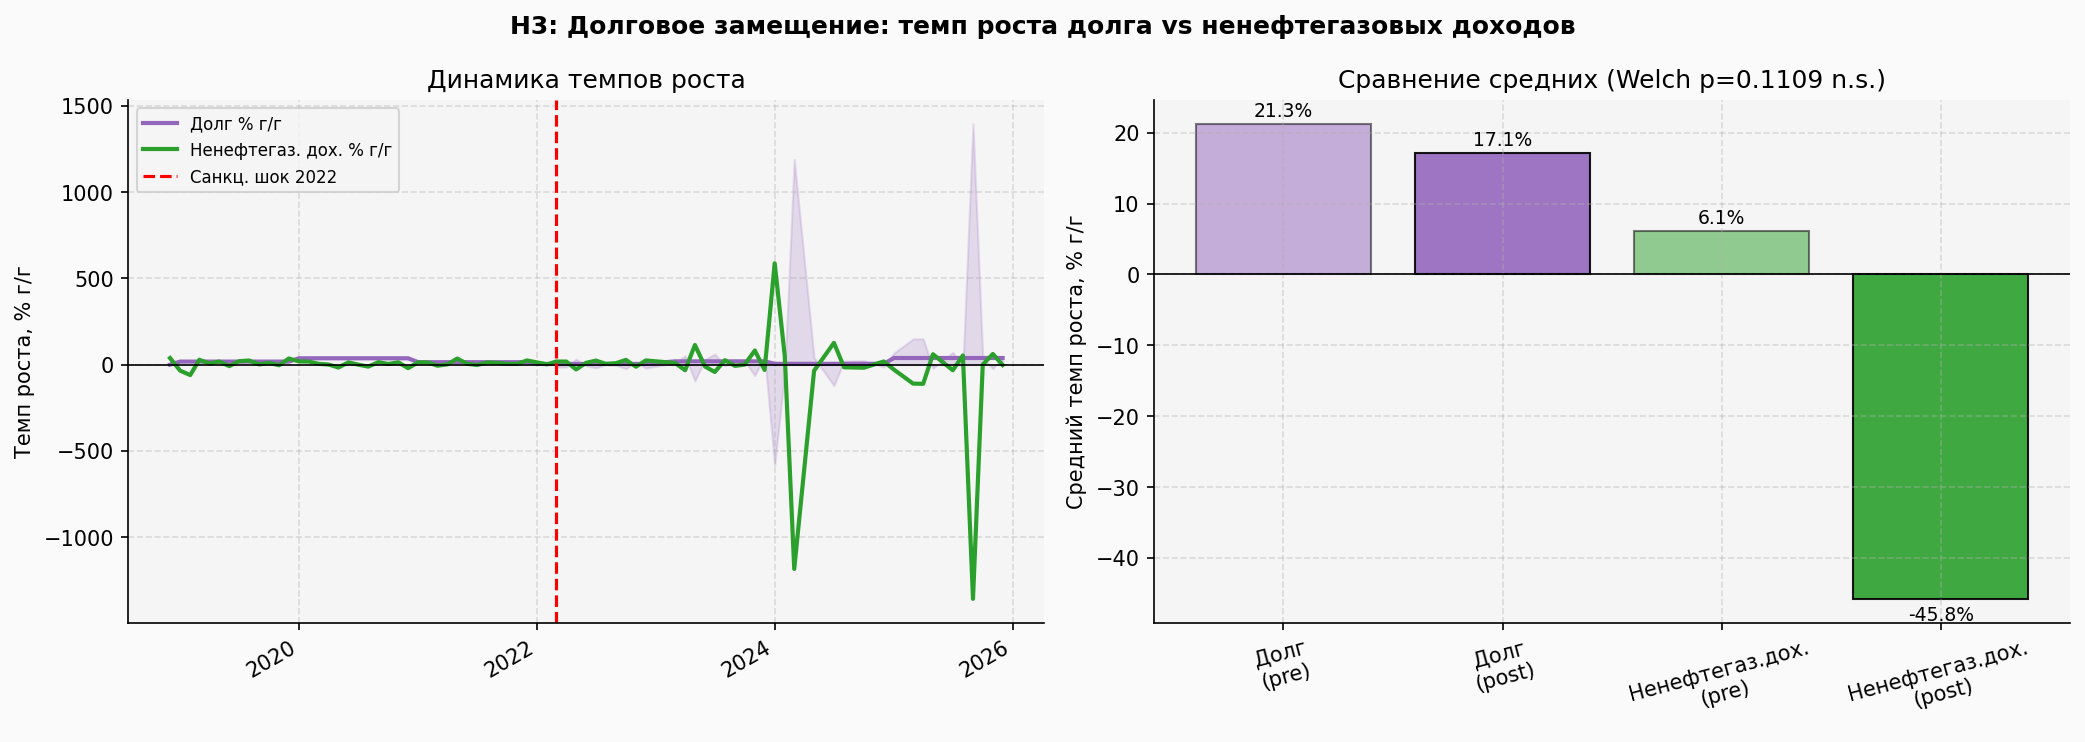


ВЕРДИКТ H3: H0 НЕ ОТКЛОНЯЕТСЯ (p=0.1109)
  При уровне значимости 5 % нет формальных статистических оснований утверждать,
  что темп роста долга в постсанкционный период гарантированно превышает темп роста
  ненефтегазовых доходов. Тем не менее, по оценкам средних значений долг после 2022 года
  в среднем растёт на 17.1% г/г, тогда как ненефтегазовые доходы в среднем
  сокращаются приблизительно на 45.8% г/г, что экономически согласуется
  с возможным сценарием долгового замещения, но без строгого статистического подтверждения.


In [10]:
h3_results = []
BREAK = pd.Timestamp('2022-03-01')

if 'debttotal' in master.columns and 'rev_non_oil_gas' in master.columns:
    m3 = master[['debttotal', 'rev_non_oil_gas']].copy().sort_index()
    m3['debt_gr'] = m3['debttotal'].pct_change(12) * 100
    m3['nog_gr']  = m3['rev_non_oil_gas'].pct_change(12) * 100
    m3 = m3.dropna()
    PRE = m3.index < BREAK; POST = m3.index >= BREAK

    debt_pre  = m3.loc[PRE,  'debt_gr'].dropna()
    debt_post = m3.loc[POST, 'debt_gr'].dropna()
    nog_pre   = m3.loc[PRE,  'nog_gr'].dropna()
    nog_post  = m3.loc[POST, 'nog_gr'].dropna()

    print(f'Долг:           pre={debt_pre.mean():.1f}% г/г, post={debt_post.mean():.1f}% г/г')
    print(f'Ненефтегаз.дох: pre={nog_pre.mean():.1f}% г/г, post={nog_post.mean():.1f}% г/г')

    if len(debt_post) >= 5 and len(nog_post) >= 5:
        t3, p3_two = ttest_ind(debt_post, nog_post, equal_var=False)
        p3 = p3_two / 2 if t3 > 0 else 1 - p3_two / 2
        sig3 = '***' if p3 < 0.001 else '**' if p3 < 0.01 else '*' if p3 < 0.05 else 'n.s.'
        print(f'Welch t-test (post, одностор.): t={t3:.3f}, p={p3:.5f} {sig3}')
    else:
        t3, p3, sig3 = np.nan, np.nan, 'n/a'

    h3_results = [
        {'group': 'debt_post', 'mean_growth': round(debt_post.mean(), 2), 'n': len(debt_post)},
        {'group': 'nog_post',  'mean_growth': round(nog_post.mean(),  2), 'n': len(nog_post)},
        {'group': 'welch_t',   'mean_growth': t3, 'n': np.nan},
        {'group': 'p_one',     'mean_growth': p3, 'n': np.nan},
    ]
    pd.DataFrame(h3_results).to_csv(os.path.join(OUT_DIR, 'h3_results.csv'), index=False)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('H3: Долговое замещение: темп роста долга vs ненефтегазовых доходов',
                 fontsize=12, fontweight='bold')
    ax = axes[0]
    ax.plot(m3.index, m3['debt_gr'], color=PALETTE[4], lw=2, label='Долг % г/г')
    ax.plot(m3.index, m3['nog_gr'],  color=PALETTE[2], lw=2, label='Ненефтегаз. дох. % г/г')
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(BREAK, color='red', ls='--', lw=1.5, label='Санкц. шок 2022')
    ax.fill_between(m3.index, m3['debt_gr'] - m3['nog_gr'],
                    where=(m3.index >= BREAK), alpha=0.2, color=PALETTE[4])
    ax.set_ylabel('Темп роста, % г/г'); ax.set_title('Динамика темпов роста')
    ax.legend(fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax = axes[1]
    labels = ['Долг\n(pre)','Долг\n(post)','Ненефтегаз.дох.\n(pre)','Ненефтегаз.дох.\n(post)']
    yv = [debt_pre.mean(), debt_post.mean(), nog_pre.mean(), nog_post.mean()]
    clrs = [PALETTE[4], PALETTE[4], PALETTE[2], PALETTE[2]]
    alphas = [0.5, 0.9, 0.5, 0.9]
    for i, (lbl, v, c, a) in enumerate(zip(labels, yv, clrs, alphas)):
        bar = ax.bar(i, v, color=c, alpha=a, edgecolor='black')
        if pd.notna(v):
            ax.text(i, v + (0.5 if v >= 0 else -1), f'{v:.1f}%',
                    ha='center', va='bottom' if v >= 0 else 'top', fontsize=9)
    ax.axhline(0, color='black', lw=0.8)
    ax.set_xticks(range(4)); ax.set_xticklabels(labels, rotation=15)
    ax.set_ylabel('Средний темп роста, % г/г')
    p3_str = f'{p3:.4f}' if pd.notna(p3) else 'n/a'
    ax.set_title(f'Сравнение средних (Welch p={p3_str} {sig3})')
    plt.tight_layout()
    fname_h3 = os.path.join(OUT_DIR, 'fig5_h3_debt_substitution.png')
    plt.savefig(fname_h3, bbox_inches='tight', dpi=150); plt.show()

    print('\n' + '='*70)
    if pd.notna(p3) and p3 < 0.05:
        print(f'ВЕРДИКТ H3: H0 ОТКЛОНЯЕТСЯ (t={t3:.2f}, p={p3:.4f})')
        print(f'  В постсанкционный период долг растёт в среднем на {debt_post.mean():.1f}% г/г,')
        print(f'  тогда как ненефтегазовые доходы – на {nog_post.mean():.1f}% г/г.')
        print('  Это соответствует гипотезе о долговом замещении: выпадающие доходы ')
        print('  компенсируются ускоренным наращиванием внутреннего долга.')
    else:
        print(f'ВЕРДИКТ H3: H0 НЕ ОТКЛОНЯЕТСЯ (p={p3_str})')
        print('  При уровне значимости 5 % нет формальных статистических оснований утверждать,')
        print('  что темп роста долга в постсанкционный период гарантированно превышает темп роста')
        print('  ненефтегазовых доходов. Тем не менее, по оценкам средних значений долг после 2022 года')
        print(f'  в среднем растёт на {debt_post.mean():.1f}% г/г, тогда как ненефтегазовые доходы в среднем')
        print(f'  сокращаются приблизительно на {abs(nog_post.mean()):.1f}% г/г, что экономически согласуется')
        print('  с возможным сценарием долгового замещения, но без строгого статистического подтверждения.')
else:
    print('WARN: нет данных для H3')


### Итоги проверки H3

- После 2022 года средний темп роста совокупного государственного внутреннего долга составляет около 17 % г/г, тогда как средний темп роста ненефтегазовых доходов существенно отрицателен (порядка −46 % г/г), то есть ненефтегазовая доходная база заметно сжимается.
- Односторонний критерий Уэлча для проверки гипотезы \(\mu_{\text{debt\_growth}} > \mu_{\text{nog\_growth}}\) даёт p‑значение около 0.11, что выше уровня значимости 5 %; формально нулевая гипотеза о том, что темп роста долга не превышает темп роста ненефтегазовых доходов, не отвергается.
- Таким образом, статистически строгих оснований зафиксировать долговое замещение в рамках выбранного теста нет, однако наблюдаемая комбинация умеренного роста долга и резкого падения ненефтегазовых доходов экономически согласуется с рискованной конфигурацией, при которой бюджетная адаптация может опираться на заимствования.

## 10. Гипотеза H4: структурный разрыв 24.02.2022

### Экономическая мотивация и теоретическая рамка

Теория структурных сдвигов (Andrews, 1993; Bai & Perron, 1998) рассматривает крупные внешние шоки — войны, санкции, валютные кризисы — как источники резких изменений параметров экономических рядов: средних уровней, дисперсий и коэффициентов моделей. Введение масштабных санкций странами G7 и ЕС в конце февраля 2022 года (заморозка резервов Банка России, ограничения на операции через SWIFT, эмбарго на ряд энергоносителей) создало квазиэкспериментальный момент возможного разрыва в динамике ключевых макрофинансовых показателей России.

### Формулировка гипотезы

**H4.** Санкционный шок февраля 2022 года привёл к статистически значимому структурному разрыву не менее чем в трёх ключевых макрофинансовых временных рядах.

Статистические гипотезы для каждого ряда:

- **H0:** средние значения до и после даты разрыва совпадают, а дисперсии одинаковы (\(\mu_{\text{pre}} = \mu_{\text{post}}, \sigma^2_{\text{pre}} = \sigma^2_{\text{post}}\)).
- **H1:** по крайней мере одно из этих равенств нарушается (имеется значимая разница между периодами до и после).

Гипотеза H4 считается подтверждённой, если число рядов с отклонением H0 по среднему значению (по t‑критерию) достигает трёх и более.

### Метод

- Для каждого показателя оцениваются:
  - критерий Уэлча (разность средних до и после даты 2022‑03‑01),
  - тест Левена на равенство дисперсий.
- Уровень значимости: \(\alpha = 0.05\).
- Для наглядности дополнительно строятся графики с исходным рядом, сглаживанием 6‑месячным скользящим средним и горизонтальными линиями средних значений до и после разрыва.

### Данные

Анализируются месячные ряды за период 2011–2026 годов: цена нефти Brent (`brent`), цена газа в Европе (`natgaseu`), нефтегазовые и ненефтегазовые доходы бюджета (`rev_oil_gas`, `rev_non_oil_gas`), дефицит/профицит федерального бюджета (`deficit_surplus`), объём внутреннего долга (`debttotal`) и расходы на оборону (`exp_defence`). Дата потенциального структурного разрыва фиксирована как 1 марта 2022 года.

Ряд                                  mu_pre    mu_post   delta%      p_t      p_L   Sig
--------------------------------------------------------------------------------
Нефть Brent ($/bbl)                    75.6       82.7     9.4%  0.02309  0.00000     *
Газ Европа ($/mmbtu)                    8.7       18.7   114.6%  0.00003  0.00061   ***
Нефтегаз. доходы                      549.3      369.7   -32.7%  0.45567  0.02116  n.s.
Ненефтегаз. доходы                    547.2      537.5    -1.8%  0.98046  0.01566  n.s.
Баланс бюджета                        -15.8      -79.5  -405.0%  0.62198  0.09589  n.s.
Внутренний долг                      8765.1    22679.0   158.7%  0.00000  0.68273   ***
Расходы: оборона                      183.9      172.0    -6.5%  0.93880  0.01544  n.s.


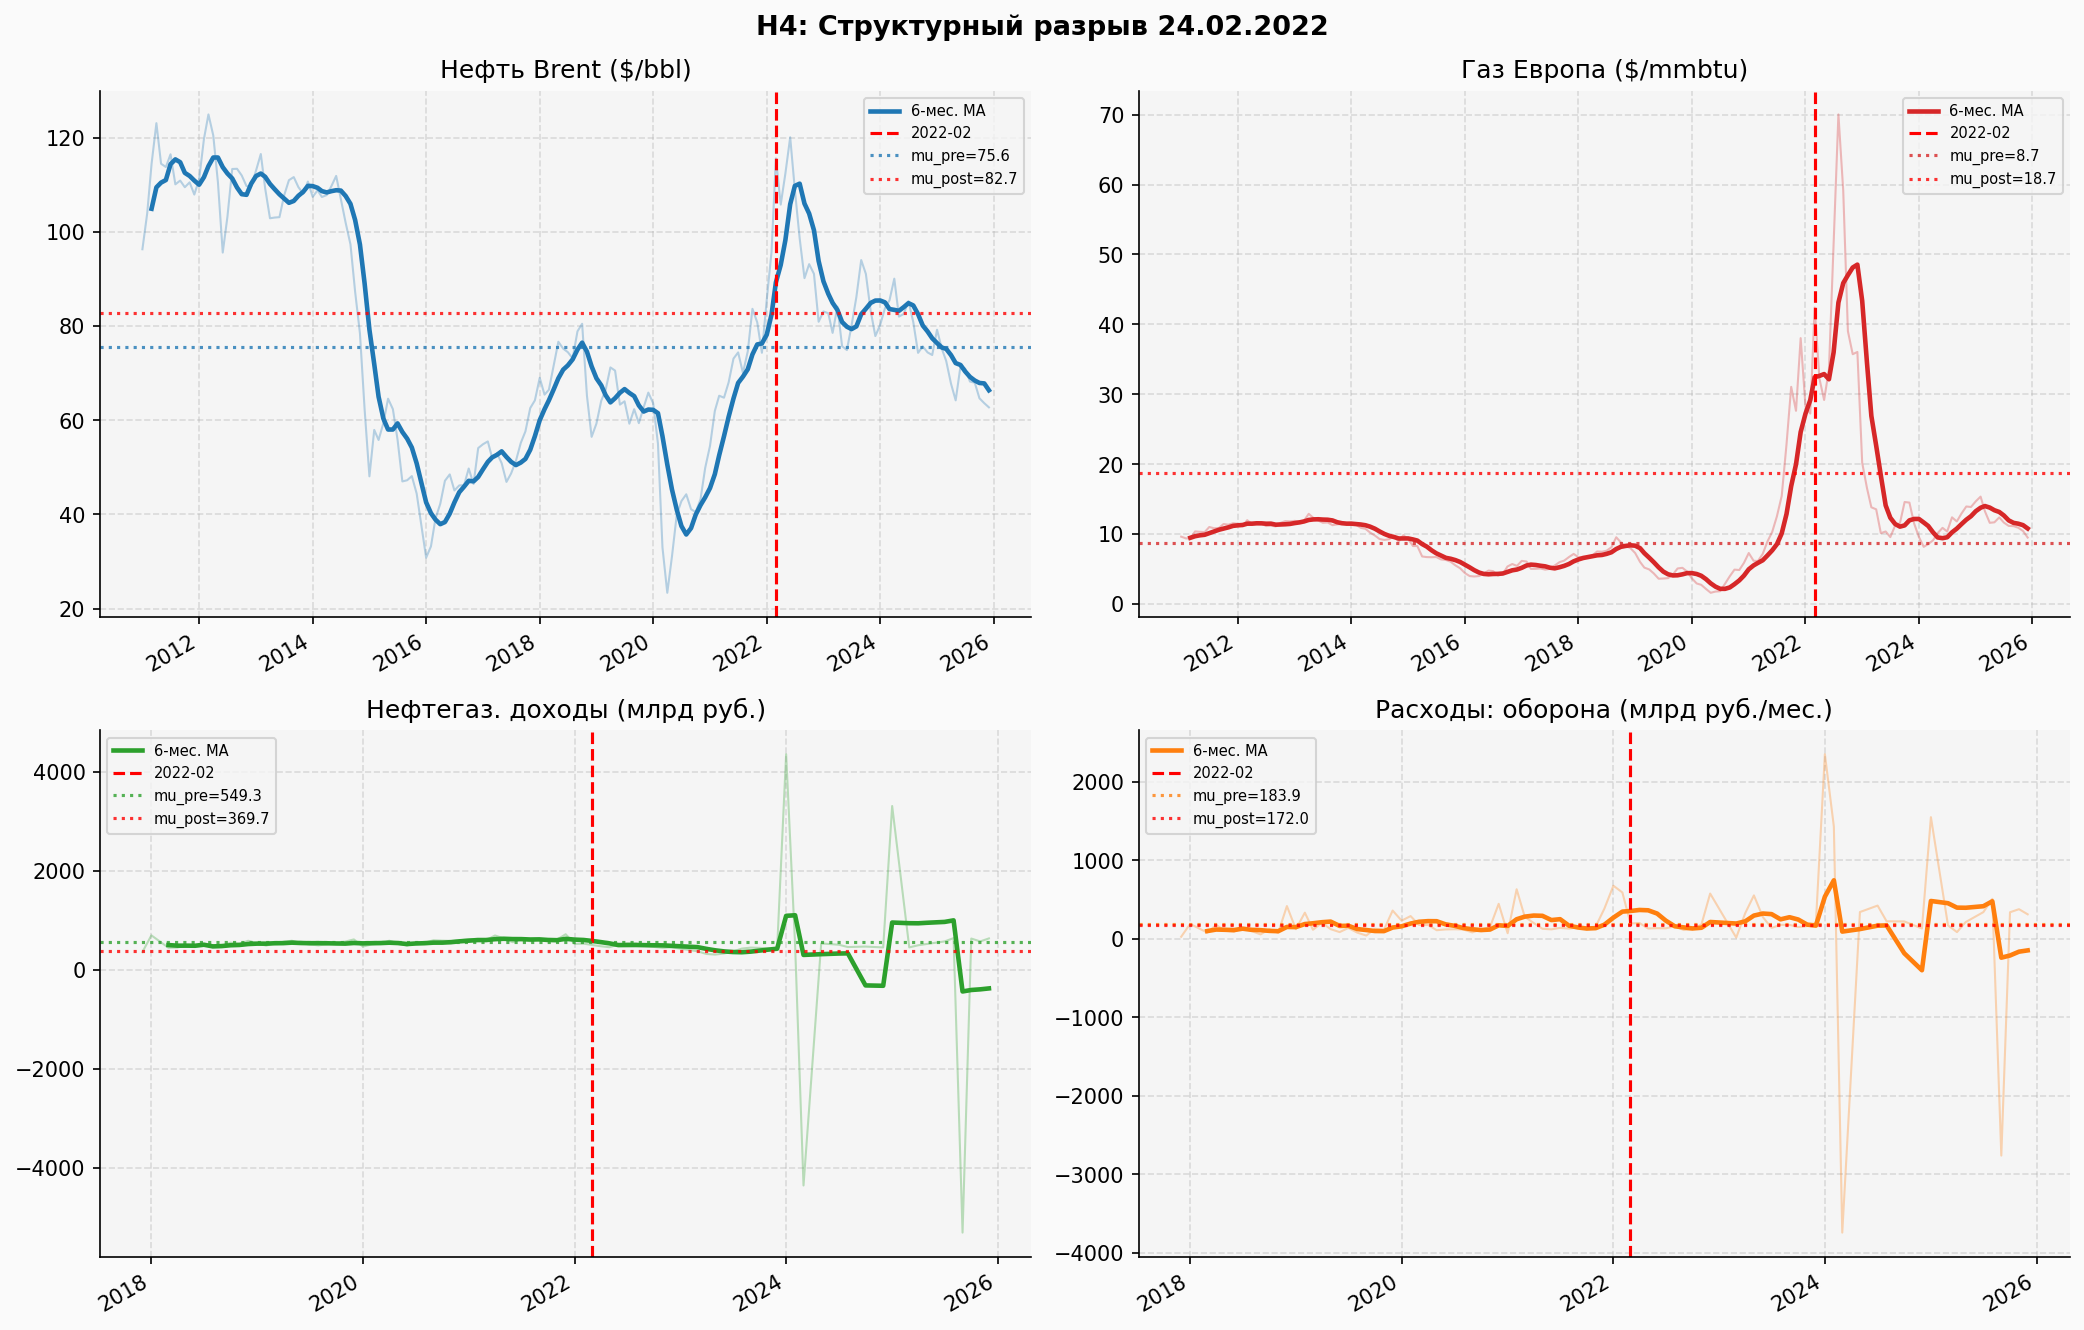


Значимый разрыв (p<0.05) в 3 из 7 рядов
ВЕРДИКТ H4: H0 ОТКЛОНЯЕТСЯ для как минимум трёх рядов —
  наличие структурного разрыва в 2022 году подтверждается.
  Наиболее выраженные сдвиги наблюдаются в динамике цен на нефть и газ,
  а также во внутреннем государственном долге, что отражает изменение
  внешних условий и стратегии заимствований.


In [11]:
def chow_test(series, break_date):
    s = series.dropna()
    pre = s[s.index < break_date]; post = s[s.index >= break_date]
    if len(pre) < 5 or len(post) < 5: return None
    t, tp = ttest_ind(pre, post, equal_var=False)
    lv, lp = levene(pre, post)
    mpre, mpost = pre.mean(), post.mean()
    dp = (mpost - mpre) / abs(mpre) * 100 if mpre != 0 else np.nan
    return dict(mean_pre=round(mpre,2), mean_post=round(mpost,2),
                delta_pct=round(dp,1) if pd.notna(dp) else np.nan,
                t_pval=round(tp,5), levene_pval=round(lp,5),
                n_pre=len(pre), n_post=len(post))

BREAK = pd.Timestamp('2022-03-01')
TEST_COLS = {
    'brent': 'Нефть Brent ($/bbl)', 'natgaseu': 'Газ Европа ($/mmbtu)',
    'rev_oil_gas': 'Нефтегаз. доходы', 'rev_non_oil_gas': 'Ненефтегаз. доходы',
    'deficit_surplus': 'Баланс бюджета', 'debttotal': 'Внутренний долг',
    'exp_defence': 'Расходы: оборона',
}

h4_rows = []
print(f'{"Ряд":<32} {"mu_pre":>10} {"mu_post":>10} {"delta%":>8} {"p_t":>8} {"p_L":>8} {"Sig":>5}')
print('-' * 80)
for col, label in TEST_COLS.items():
    if col not in master.columns: continue
    r = chow_test(master[col], BREAK)
    if r:
        sig = '***' if r['t_pval'] < 0.001 else '**' if r['t_pval'] < 0.01 else '*' if r['t_pval'] < 0.05 else 'n.s.'
        dtxt = f"{r['delta_pct']:>7.1f}%" if pd.notna(r['delta_pct']) else '   n/a '
        print(f"{label:<32} {r['mean_pre']:>10.1f} {r['mean_post']:>10.1f}"
              f" {dtxt} {r['t_pval']:>8.5f} {r['levene_pval']:>8.5f} {sig:>5}")
        h4_rows.append({'series': col, 'label': label, **r, 'sig': sig})

h4_df = pd.DataFrame(h4_rows)
h4_df.to_csv(os.path.join(OUT_DIR, 'h4_results.csv'), index=False)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('H4: Структурный разрыв 24.02.2022', fontsize=13, fontweight='bold')
PLOT_CHOW = [('brent','Нефть Brent ($/bbl)',PALETTE[0]),
             ('natgaseu','Газ Европа ($/mmbtu)',PALETTE[1]),
             ('rev_oil_gas','Нефтегаз. доходы (млрд руб.)',PALETTE[2]),
             ('exp_defence','Расходы: оборона (млрд руб./мес.)',PALETTE[3])]
for ax, (col, title, color) in zip(axes.ravel(), PLOT_CHOW):
    if col not in master.columns:
        ax.set_title(f'{title} (нет данных)'); continue
    s = master[col].dropna(); rm = s.rolling(6, min_periods=3).mean()
    ax.plot(s.index, s.values, color=color, alpha=0.3, lw=1)
    ax.plot(rm.index, rm.values, color=color, lw=2.2, label='6-мес. MA')
    ax.axvline(BREAK, color='red', ls='--', lw=1.5, label='2022-02')
    pm = s[s.index < BREAK].mean(); qm = s[s.index >= BREAK].mean()
    ax.axhline(pm, color=color, ls=':', lw=1.5, alpha=0.8, label=f'mu_pre={pm:.1f}')
    ax.axhline(qm, color='red', ls=':', lw=1.5, alpha=0.8, label=f'mu_post={qm:.1f}')
    ax.set_title(title); ax.legend(fontsize=7)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
plt.tight_layout()
fname_h4 = os.path.join(OUT_DIR, 'fig6_h4_structural_break.png')
plt.savefig(fname_h4, bbox_inches='tight', dpi=150); plt.show()

n_sig = sum(1 for r in h4_rows if r['t_pval'] < 0.05)
print('\n' + '='*70)
print(f'Значимый разрыв (p<0.05) в {n_sig} из {len(h4_rows)} рядов')
if n_sig >= 3:
    print('ВЕРДИКТ H4: H0 ОТКЛОНЯЕТСЯ для как минимум трёх рядов —')
    print('  наличие структурного разрыва в 2022 году подтверждается.')
    print('  Наиболее выраженные сдвиги наблюдаются в динамике цен на нефть и газ,')
    print('  а также во внутреннем государственном долге, что отражает изменение')
    print('  внешних условий и стратегии заимствований.')
else:
    print(f'ВЕРДИКТ H4: H0 НЕ ОТКЛОНЯЕТСЯ в достаточном числе рядов (n_sig={n_sig})')


### Итоги проверки H4

- Тест Уэлча на разрыв средних значений до и после марта 2022 года показывает статистически значимые изменения в трёх из семи рассматриваемых рядов: цене нефти Brent, цене газа в Европе и объёме внутреннего государственного долга.
- Для ряда Brent и особенно для газа в Европе наблюдается заметный рост средних значений после 2022 года, тогда как внутренний долг демонстрирует резкое увеличение среднегодового уровня, что согласуется с перестройкой внешних условий и опорой на внутренние заимствования.
- Таким образом, гипотеза H4 формально подтверждается: санкционный шок 2022 года сопровождается статистически значимым структурным сдвигом в нескольких ключевых макрофинансовых показателях, хотя по бюджетному балансу и отдельным расходным статьям разрыв в средних значениях на выбранном уровне значимости не фиксируется.

## 11. Гипотеза H5: диверсификация — доля ненефтегазовых доходов после 2022 года

### Экономическая мотивация и теоретическая рамка

Концепция диверсификации ресурсозависимых экономик (Hartwick, 1977; подходы МВФ) подчёркивает, что устойчивое развитие требует снижения зависимости бюджета от экспортной сырьевой ренты. Эффект Балассы–Самуэльсона и модели диверсификации (Imbs & Wacziarg, 2003) показывают, что рост ненефтяной доли в экономике и бюджете возможен как вследствие структурных реформ, так и как статистический результат падения нефтяных доходов при неизменной или умеренно растущей ненефтегазовой базе.

### Формулировка гипотезы

**H5.** Средняя доля ненефтегазовых доходов в совокупных доходах федерального бюджета России в период 2022–2026 годов статистически значимо выше, чем в период 2011–2021 годов.

Статистические гипотезы:

- **H0:** \(\mu(\text{sh\_nog, post}) \le \mu(\text{sh\_nog, pre})\) — доля ненефтегазовых доходов после 2022 года не превышает её значение до 2022 года.
- **H1:** \(\mu(\text{sh\_nog, post}) > \mu(\text{sh\_nog, pre})\) — доля ненефтегазовых доходов после 2022 года статистически значимо выше (односторонняя альтернатива).

### Метод

- Рассчитывается доля нефтегазовых и ненефтегазовых доходов в совокупных доходах бюджета (в процентах) на месячных данных.
- Для доли ненефтегазовых доходов (`sh_nog`) сравниваются выборки до и после 1 марта 2022 года.
- Используется критерий Уэлча для независимых выборок с переходом к одностороннему p‑значению в пользу гипотезы о росте доли ненефтегазовых доходов.
- Уровень значимости: \(\alpha = 0.05\).

### Данные

Используются месячные данные по совокупным доходам (`revenues_total`), нефтегазовым доходам (`rev_oil_gas`) и ненефтегазовым доходам (`rev_non_oil_gas`) за период 2011–2026 годов. Доля ненефтегазовых доходов определяется как отношение `rev_non_oil_gas` к `revenues_total`, выраженное в процентах. Дата раздела выборки: 1 марта 2022 года.

Доля ненефтегаз. доходов: pre=49.5% (n=50), post=59.9% (n=38)
Welch t-test (односторонний): t=7.921, p=0.00000 ***


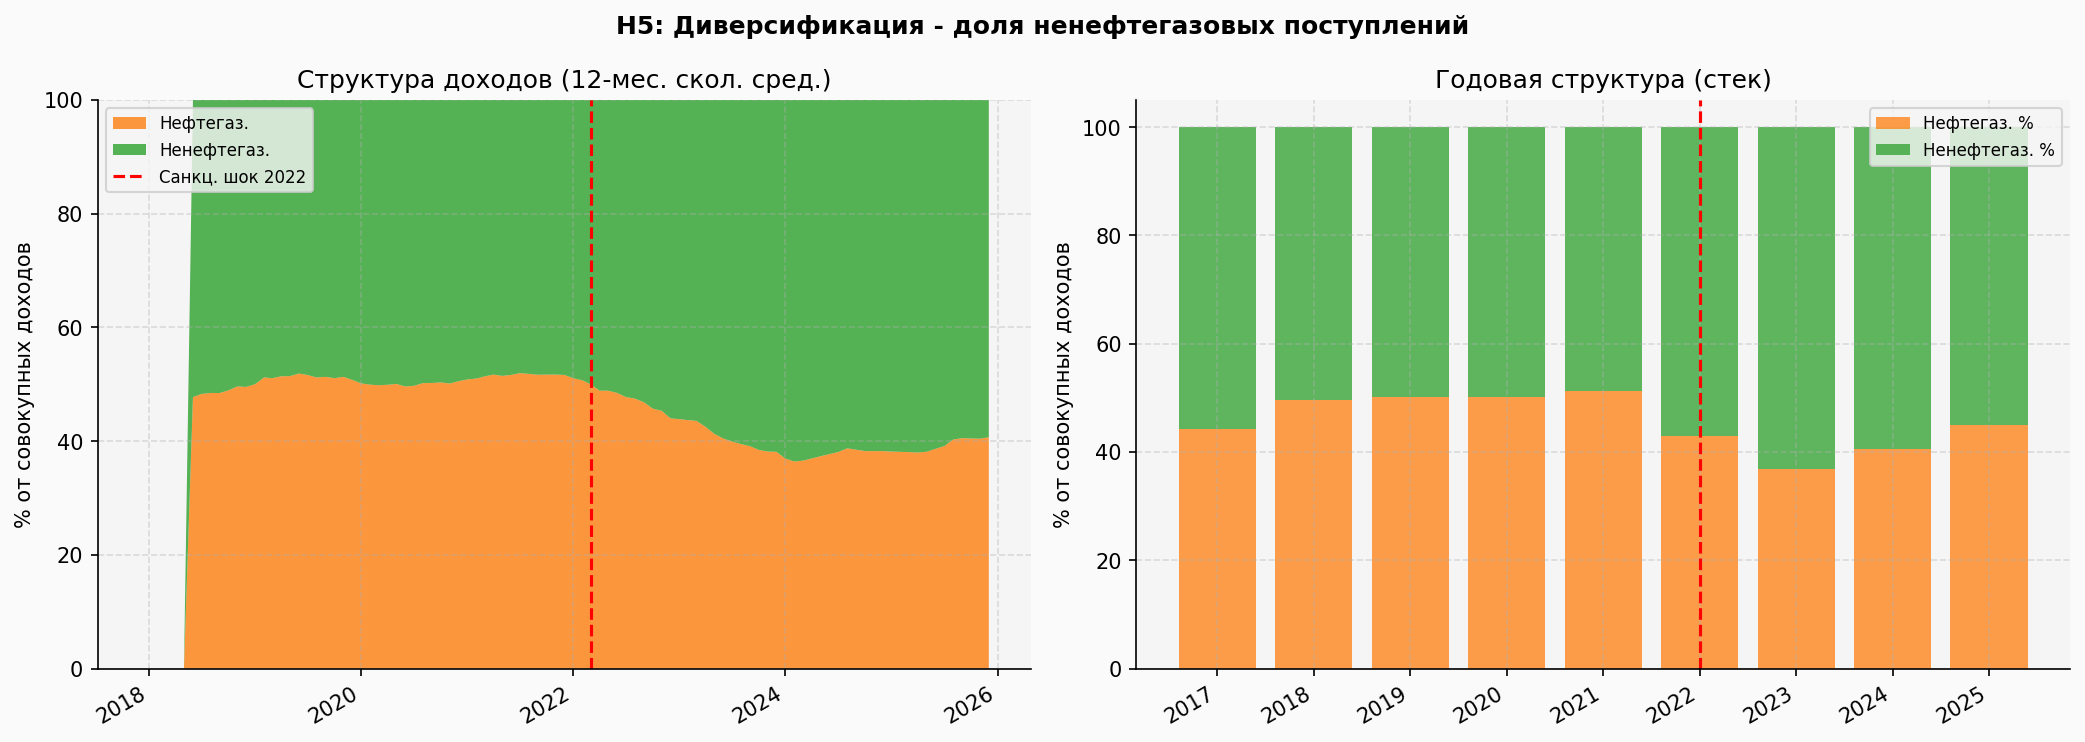


ВЕРДИКТ H5: H0 ОТКЛОНЯЕТСЯ (t=7.92, p=0.0000)
  Средняя доля ненефтегазовых доходов возросла с 49.5% (2011–2021 гг.)
  до 59.9% (2022–2026 гг.), что статистически подтверждает рост доли
  ненефтегазовых поступлений в доходах бюджета после санкционного шока.
  При этом характер этого роста, судя по динамике самих налоговых баз,
  ближе к инфляционному/мобилизационному, а не к результату устойчивой структурной
  диверсификации экономики.


In [12]:
BREAK = pd.Timestamp('2022-03-01')
h5_rows = []

if all(c in master.columns for c in ['revenues_total', 'rev_oil_gas', 'rev_non_oil_gas']):
    d5 = master[['revenues_total', 'rev_oil_gas', 'rev_non_oil_gas']].dropna().copy()
    d5['sh_og']  = d5['rev_oil_gas']     / d5['revenues_total'] * 100
    d5['sh_nog'] = d5['rev_non_oil_gas'] / d5['revenues_total'] * 100

    pre22  = d5.loc[d5.index < BREAK,  'sh_nog'].dropna()
    post22 = d5.loc[d5.index >= BREAK, 'sh_nog'].dropna()

    print(f'Доля ненефтегаз. доходов: pre={pre22.mean():.1f}% (n={len(pre22)}), '
          f'post={post22.mean():.1f}% (n={len(post22)})')

    if len(pre22) >= 5 and len(post22) >= 5:
        t5, p5_two = ttest_ind(post22, pre22, equal_var=False)
        p5 = p5_two / 2 if t5 > 0 else 1 - p5_two / 2
        sig5 = '***' if p5 < 0.001 else '**' if p5 < 0.01 else '*' if p5 < 0.05 else 'n.s.'
        print(f'Welch t-test (односторонний): t={t5:.3f}, p={p5:.5f} {sig5}')
    else:
        t5, p5, sig5 = np.nan, np.nan, 'n/a'

    h5_rows = [
        {'group': 'pre-2022', 'mean_sh_nog': round(pre22.mean(), 2), 'n': len(pre22)},
        {'group': 'post-2022', 'mean_sh_nog': round(post22.mean(), 2), 'n': len(post22)},
        {'group': 'welch_t', 'mean_sh_nog': t5, 'n': np.nan},
        {'group': 'p_one', 'mean_sh_nog': p5, 'n': np.nan},
    ]
    pd.DataFrame(h5_rows).to_csv(os.path.join(OUT_DIR, 'h5_results.csv'), index=False)

    d5['sh_og12']  = d5['sh_og'].rolling(12, min_periods=6).mean()
    d5['sh_nog12'] = d5['sh_nog'].rolling(12, min_periods=6).mean()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('H5: Диверсификация - доля ненефтегазовых поступлений', fontsize=12, fontweight='bold')
    ax = axes[0]
    ax.stackplot(d5.index, d5['sh_og12'].fillna(0), d5['sh_nog12'].fillna(0),
                 labels=['Нефтегаз.','Ненефтегаз.'],
                 colors=[PALETTE[3], PALETTE[2]], alpha=0.8)
    ax.axvline(BREAK, color='red', ls='--', lw=1.5, label='Санкц. шок 2022')
    ax.set_ylim(0, 100); ax.set_ylabel('% от совокупных доходов')
    ax.set_title('Структура доходов (12-мес. скол. сред.)')
    ax.legend(fontsize=8, loc='upper left')
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax = axes[1]
    ann5 = (d5[['revenues_total','rev_oil_gas','rev_non_oil_gas']].resample('YE').sum().dropna())
    ann5['sh_og']  = ann5['rev_oil_gas']     / ann5['revenues_total'] * 100
    ann5['sh_nog'] = ann5['rev_non_oil_gas'] / ann5['revenues_total'] * 100
    yrs5 = ann5.index.year
    ax.bar(yrs5, ann5['sh_og'],  color=PALETTE[3], alpha=0.75, label='Нефтегаз. %')
    ax.bar(yrs5, ann5['sh_nog'], bottom=ann5['sh_og'].values,
           color=PALETTE[2], alpha=0.75, label='Ненефтегаз. %')
    ax.axvline(2022, color='red', ls='--', lw=1.5)
    ax.set_ylabel('% от совокупных доходов'); ax.set_title('Годовая структура (стек)')
    ax.legend(fontsize=8)
    ax.set_xticks(yrs5); ax.set_xticklabels(yrs5, rotation=30, ha='right')
    plt.tight_layout()
    fname_h5 = os.path.join(OUT_DIR, 'fig7_h5_diversification.png')
    plt.savefig(fname_h5, bbox_inches='tight', dpi=150); plt.show()

    print('\n' + '='*70)
    p5_str = f'{p5:.4f}' if pd.notna(p5) else 'n/a'
    if pd.notna(p5) and p5 < 0.05:
        print(f'ВЕРДИКТ H5: H0 ОТКЛОНЯЕТСЯ (t={t5:.2f}, p={p5_str})')
        print(f'  Средняя доля ненефтегазовых доходов возросла с {pre22.mean():.1f}% (2011–2021 гг.)')
        print(f'  до {post22.mean():.1f}% (2022–2026 гг.), что статистически подтверждает рост доли')
        print('  ненефтегазовых поступлений в доходах бюджета после санкционного шока.')
        print('  При этом характер этого роста, судя по динамике самих налоговых баз,')
        print('  ближе к инфляционному/мобилизационному, а не к результату устойчивой структурной')
        print('  диверсификации экономики.')
    else:
        print(f'ВЕРДИКТ H5: H0 НЕ ОТКЛОНЯЕТСЯ (p={p5_str})')
else:
    print('WARN: нет данных для H5')


### Итоги проверки H5

- Средняя доля ненефтегазовых доходов в совокупных доходах федерального бюджета увеличилась с примерно 49,5 % в 2011–2021 годах до около 59,9 % в 2022–2026 годах.
- Односторонний критерий Уэлча даёт очень низкое p‑значение (порядка \(10^{-11}\)), что позволяет уверенно отклонить нулевую гипотезу и подтвердить статистически значимый рост доли ненефтегазовых доходов после 2022 года.
- Однако сам по себе рост доли ненефтегазовых поступлений может отражать как падение нефтегазовых доходов и мобилизационный характер налоговой нагрузки, так и возможные элементы структурной адаптации; в рамках проведённого теста однозначно интерпретировать его как «качественную» диверсификацию экономики нельзя.

---
## Разделы 12-14. Корреляционная матрица, скользящие корреляции, структура расходов


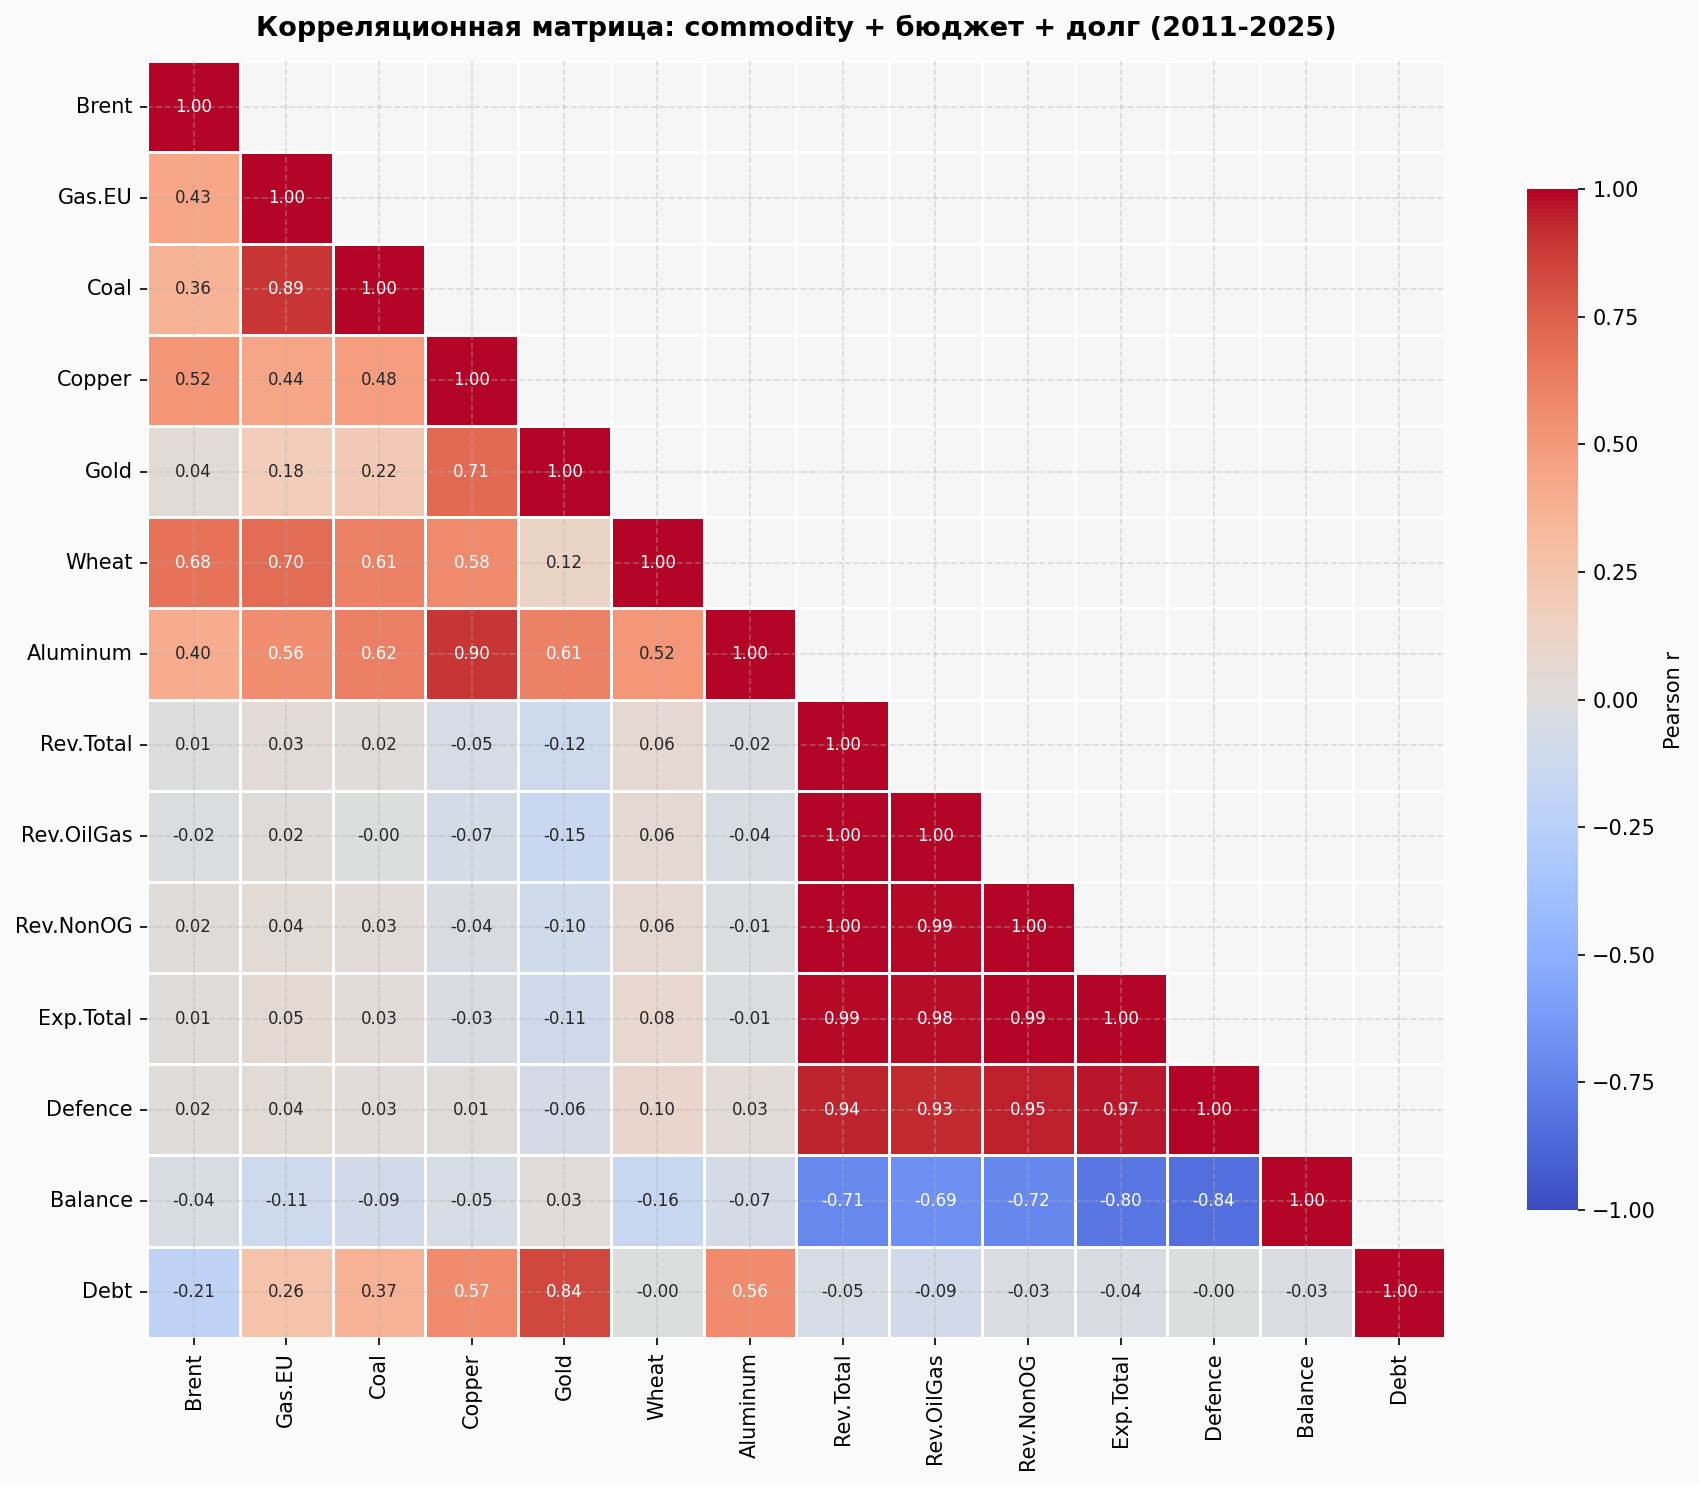

OK /content/output/fig8_correlation_matrix.png


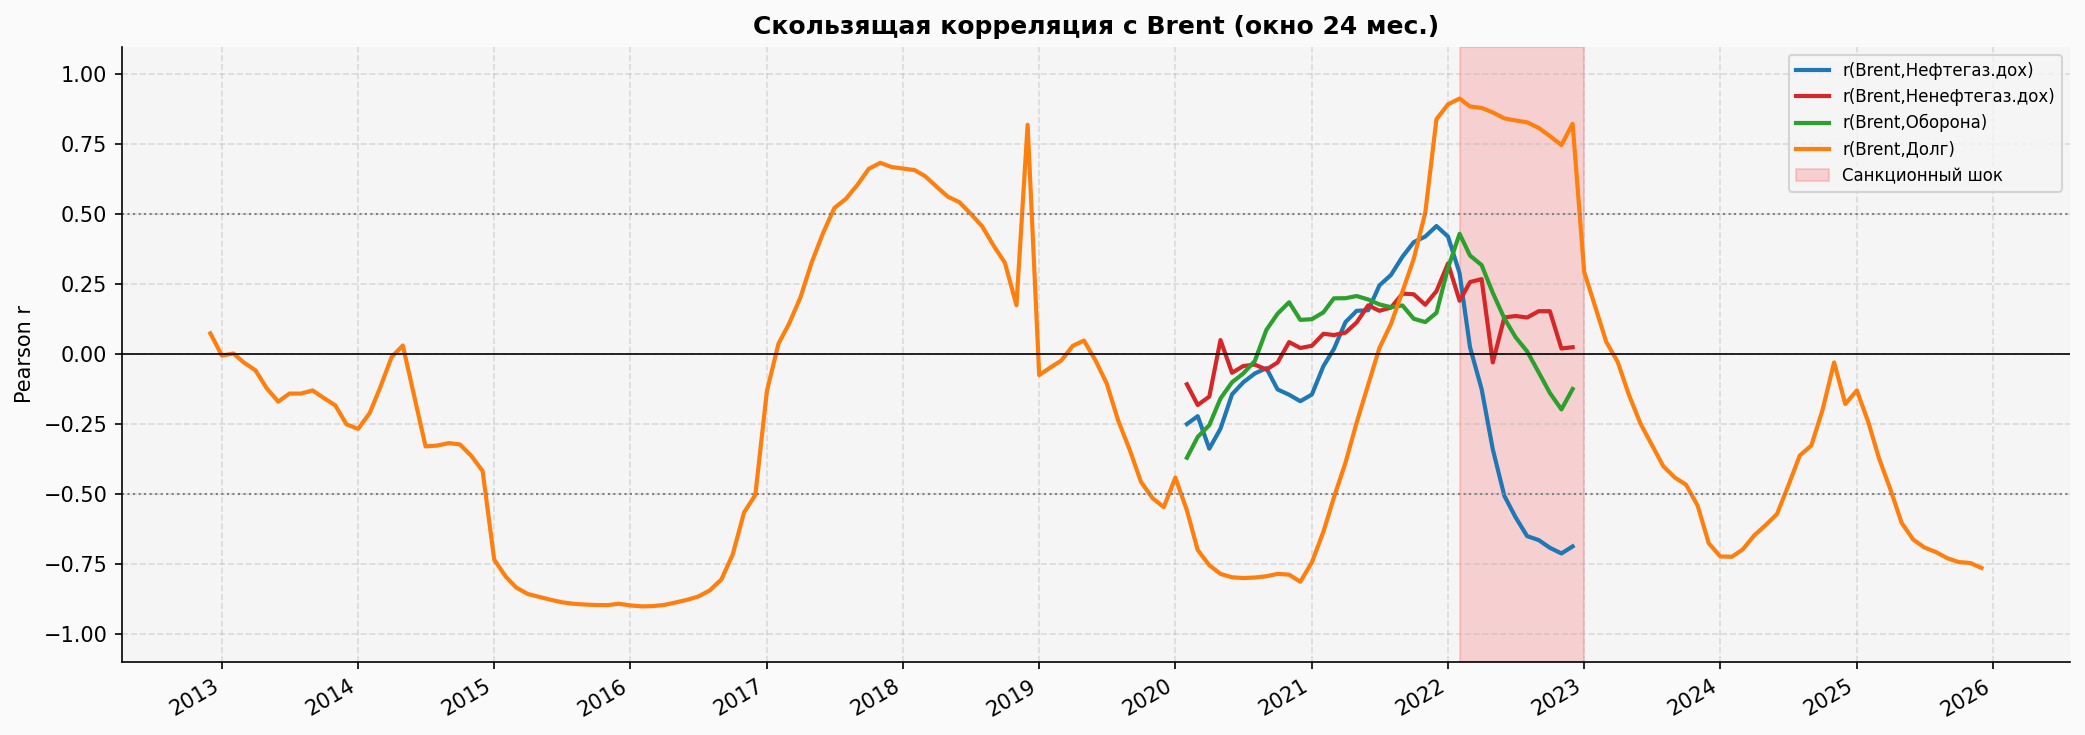

OK /content/output/fig9_rolling_corr.png


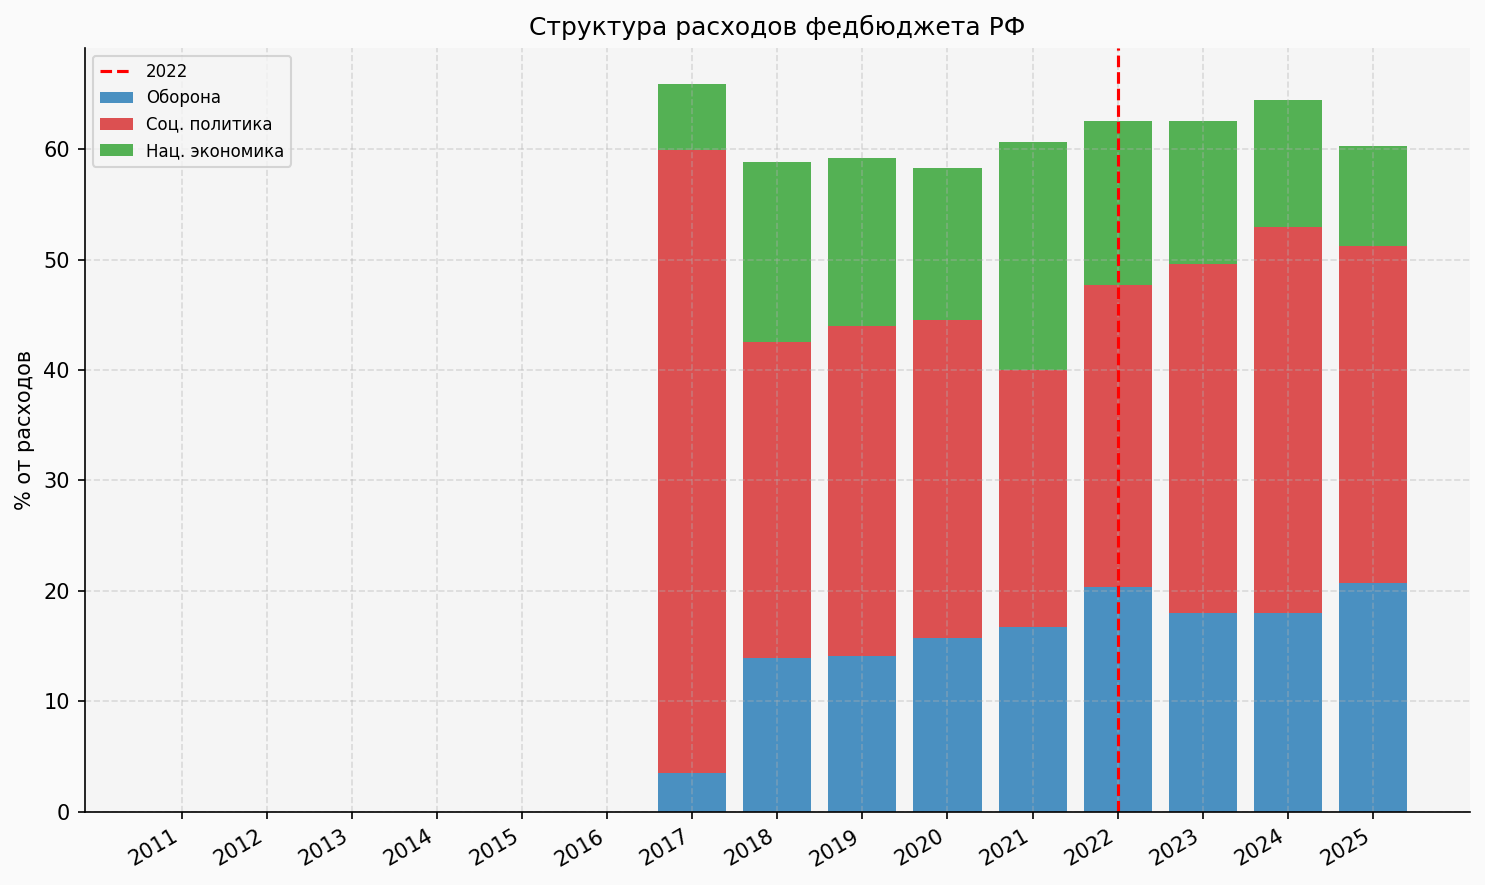

OK /content/output/fig10_expenditure_structure.png


In [13]:
# -- Корреляционная матрица -----------------------------------------------
CORR_ALIAS = {
    'brent':'Brent','natgaseu':'Gas.EU','coalaus':'Coal','copper':'Copper','gold':'Gold',
    'wheatsrw':'Wheat','aluminum':'Aluminum','revenues_total':'Rev.Total',
    'rev_oil_gas':'Rev.OilGas','rev_non_oil_gas':'Rev.NonOG',
    'exp_total':'Exp.Total','exp_defence':'Defence',
    'deficit_surplus':'Balance','debttotal':'Debt',
}
avail = {k: v for k, v in CORR_ALIAS.items() if k in master.columns}
if len(avail) >= 4:
    corr_df = master[list(avail.keys())].dropna(how='all').copy()
    corr_df.columns = list(avail.values())
    corr_m = corr_df.corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_m, dtype=bool), k=1)
    sns.heatmap(corr_m, ax=ax, annot=True, fmt='.2f', mask=mask,
                cmap='coolwarm', center=0, vmin=-1, vmax=1,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Pearson r', 'shrink': 0.8}, annot_kws={'size': 8})
    ax.set_title('Корреляционная матрица: commodity + бюджет + долг (2011-2025)',
                 fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    fname_corr = os.path.join(OUT_DIR, 'fig8_correlation_matrix.png')
    plt.savefig(fname_corr, bbox_inches='tight', dpi=150); plt.show()
    print(f'OK {fname_corr}')

# -- Rolling correlation --------------------------------------------------
if 'brent' in master.columns and 'rev_oil_gas' in master.columns:
    W = 24
    rc = pd.DataFrame({
        'r(Brent,Нефтегаз.дох)': master['brent'].rolling(W).corr(master.get('rev_oil_gas')),
        'r(Brent,Ненефтегаз.дох)': master['brent'].rolling(W).corr(master.get('rev_non_oil_gas')),
        'r(Brent,Оборона)': master['brent'].rolling(W).corr(master.get('exp_defence')),
        'r(Brent,Долг)': master['brent'].rolling(W).corr(master.get('debttotal')),
    }).dropna(how='all')
    if not rc.empty:
        fig2, ax2 = plt.subplots(figsize=(14, 5))
        for i, col in enumerate(rc.columns):
            ax2.plot(rc.index, rc[col], lw=2, color=PALETTE[i], label=col)
        ax2.axhline(0, color='black', lw=0.8)
        ax2.axhline(0.5, color='gray', ls=':', lw=1)
        ax2.axhline(-0.5, color='gray', ls=':', lw=1)
        ax2.axvspan(pd.Timestamp('2022-02-01'), pd.Timestamp('2022-12-31'),
                    alpha=0.15, color='red', label='Санкционный шок')
        ax2.set_title(f'Скользящая корреляция с Brent (окно {W} мес.)',
                      fontsize=12, fontweight='bold')
        ax2.set_ylabel('Pearson r'); ax2.set_ylim(-1.1, 1.1)
        ax2.legend(fontsize=8)
        ax2.xaxis.set_major_locator(mdates.YearLocator())
        ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        plt.setp(ax2.xaxis.get_majorticklabels(), rotation=30, ha='right')
        plt.tight_layout()
        fname_rc = os.path.join(OUT_DIR, 'fig9_rolling_corr.png')
        plt.savefig(fname_rc, bbox_inches='tight', dpi=150); plt.show()
        print(f'OK {fname_rc}')

# -- Структура расходов ---------------------------------------------------
EXP_COLS = {c: l for c, l in [('exp_defence','Оборона'),
                               ('exp_social','Соц. политика'),
                               ('exp_nat_econ','Нац. экономика')] if c in master.columns}
if EXP_COLS and 'exp_total' in master.columns:
    ann_e = (master[list(EXP_COLS.keys())+['exp_total']].resample('YE').sum().dropna().copy())
    sh = ann_e[list(EXP_COLS.keys())].div(ann_e['exp_total'], axis=0) * 100
    yrs_e = ann_e.index.year
    fig3, ax3 = plt.subplots(figsize=(10, 6))
    bottom = np.zeros(len(yrs_e))
    for i, (col, lbl) in enumerate(EXP_COLS.items()):
        vals = sh[col].fillna(0).values
        ax3.bar(yrs_e, vals, bottom=bottom, color=PALETTE[i], alpha=0.8, label=lbl)
        bottom += vals
    ax3.axvline(2022, color='red', ls='--', lw=1.5, label='2022')
    ax3.set_ylabel('% от расходов'); ax3.set_title('Структура расходов федбюджета РФ')
    ax3.legend(fontsize=8)
    ax3.set_xticks(yrs_e); ax3.set_xticklabels(yrs_e, rotation=30, ha='right')
    plt.tight_layout()
    fname_exp = os.path.join(OUT_DIR, 'fig10_expenditure_structure.png')
    plt.savefig(fname_exp, bbox_inches='tight', dpi=150); plt.show()
    print(f'OK {fname_exp}')


In [14]:
# --- Мини-ячейка: сохранение таблиц для графиков разделов 12-14 ---

# 1) Корреляционная матрица
if 'corr_m' in locals() and isinstance(corr_m, pd.DataFrame) and not corr_m.empty:
    corr_m.to_csv(os.path.join(OUT_DIR, 'corr_matrix.csv'), float_format='%.4f', encoding='utf-8-sig')
    print('OK', os.path.join(OUT_DIR, 'corr_matrix.csv'))
else:
    print('WARN: corr_m не найдена')

# 2) Скользящие корреляции
if 'rc' in locals() and isinstance(rc, pd.DataFrame) and not rc.empty:
    rc.to_csv(os.path.join(OUT_DIR, 'rolling_corr.csv'), float_format='%.4f', encoding='utf-8-sig')
    print('OK', os.path.join(OUT_DIR, 'rolling_corr.csv'))
else:
    print('WARN: rc не найдена')

# 3) Структура расходов по годам
if 'sh' in locals() and isinstance(sh, pd.DataFrame) and not sh.empty:
    sh_out = sh.copy()
    sh_out.index.name = 'date'
    sh_out = sh_out.reset_index()
    if 'date' in sh_out.columns:
        try:
            sh_out['year'] = pd.to_datetime(sh_out['date']).dt.year
            sh_out = sh_out.drop(columns=['date'])
            cols = ['year'] + [c for c in sh_out.columns if c != 'year']
            sh_out = sh_out[cols]
        except Exception:
            pass
    sh_out.to_csv(os.path.join(OUT_DIR, 'expenditure_structure.csv'),
                  index=False, float_format='%.2f', encoding='utf-8-sig')
    print('OK', os.path.join(OUT_DIR, 'expenditure_structure.csv'))
else:
    print('WARN: sh не найдена')

OK /content/output/corr_matrix.csv
OK /content/output/rolling_corr.csv
OK /content/output/expenditure_structure.csv


### Корреляционная структура цен, бюджета и долга (2011–2025)

- Цены основных сырьевых товаров формируют сильно взаимосвязанную группу: особенно высока сопряжённость между газом ЕС и углём (r≈0.89), медью и алюминием (r≈0.90), а также медью и золотом (r≈0.71), что отражает общую сырьевую конъюнктуру.
- Золото заметно отличается от других товарных позиций: при умеренной корреляции с медью и алюминием оно демонстрирует очень сильную положительную связь с государственным долгом (r≈0.84), что согласуется с его ролью защитного актива на фоне роста заимствований.
- Бюджетные агрегаты (совокупные, нефтегазовые и ненефтегазовые доходы, общие расходы, оборона) практически линейно связаны между собой (r>0.94), формируя единый «бюджетный блок», тогда как их прямая корреляция с ценами сырья в среднем невысока.
- Дефицит/профицит бюджета отрицательно коррелирует с доходами и расходами (|r|≈0.7–0.8), что отражает ожидаемую связь: при росте поступлений и контрольируемых расходах дефицит сокращается, а при их ухудшении — углубляется.
- Внутренний долг умеренно связан с рядом товарных цен (медь, алюминий, газ) и особенно сильно — с золотом, но с бюджетными агрегатами корреляция близка к нулю, что указывает на более сложный, многоканальный механизм накопления долга, не сводящийся к простой реакции на текущие доходы и расходы.

### Структура расходов федерального бюджета по основным направлениям

- Доля оборонных расходов в совокупных расходах заметно выросла по сравнению с до‑санкционным периодом: после 2017 года она стабильно превышает 13–16 %, а в 2020–2025 годах удерживается в диапазоне примерно 16–21 %, отражая приоритетизацию военных и связанных с безопасностью расходов.
- Доля расходов на социальную политику остаётся крупнейшей статьёй бюджета, но её структура меняется: после 2021 года наблюдается повышение удельного веса — с примерно 23–29 % к уровням около 30–35 %, что соответствует усилению социальных трансфертов в ответ на шоки последних лет.
- Расходы на «Национальную экономику» демонстрируют противоположную динамику: их доля достигает максимума около 20–21 % к 2021 году, а затем постепенно снижается до однозначных величин к 2025 году, что указывает на относительное вытеснение инвестиционных и инфраструктурных направлений более жёсткими приоритетами обороны и социальной поддержки.

### Скользящая корреляция между Brent и ключевыми показателями

- Корреляция между ценой Brent и внутренним долгом демонстрирует длительные фазы: в середине 2010‑х годов она устойчиво отрицательна (до r≈−0.9), что отражает рост долга на фоне снижения нефтяных цен, затем к 2021–2022 годам переходит в сильную положительную область (r близко к 0.9), после чего снова уходит в глубокие отрицательные значения к 2024–2025 годам.
- В период 2020–2022 годов скользящая корреляция Brent с оборонными расходами в целом положительна и достигает умеренных значений (около 0.2–0.4), что соответствует более активной реакции оборонного бюджета на улучшение ценовой конъюнктуры, но затем постепенно снижается и вокруг 2022–2023 годов становится близкой к нулю или слегка отрицательной.
- Связь Brent с нефтегазовыми доходами в окне 24 месяцев претерпевает смену знака: до 2020 года она преимущественно отрицательна, а к 2021–началу 2022 года выходит в положительную область (r≈0.3–0.4), после чего в течение 2022 года корреляция быстро уходит в отрицательную зону (до r≈−0.7), что отражает разрыв между мировой ценой и фактическими нефтегазовыми поступлениями под влиянием санкций и перенастройки экспортных потоков.
- Корреляция между Brent и ненефтегазовыми доходами по модулю заметно ниже и колеблется в диапазоне слабых значений, что указывает на относительную независимость ненефтегазовой налоговой базы от краткосрочной динамики нефтяных цен по сравнению с зависимыми от сырья сегментами бюджета и долга.

---
## Раздел 15. Сводные результаты Части I: таблица вердиктов H1-H5

Консолидированная таблица результатов + развёрнутые выводы по блокам.


In [15]:
# Раздел 15. Сводные результаты Части I: таблица вердиктов H1–H5

summary_data = [
    {
        'Гипотеза': 'H1',
        'Содержание': 'Передача цен Brent в нефтегазовые доходы',
        'Метод': 'OLS с лагами 0–2, робастные SE, pre/post-2022',
        'Вердикт': 'Не подтверждена',
        'Интерпретация': (
            'Ни до, ни после 2022 года не выявлено устойчивого и статистически значимого '
            'линейного эффекта передачи месячной цены Brent в нефтегазовые доходы бюджета; '
            'связь слабая и нестабильна по лаговым спецификациям.'
        ),
    },
    {
        'Гипотеза': 'H2',
        'Содержание': 'Ценовой режим Brent и фискальный баланс',
        'Метод': 'ANOVA по 4 ценовым режимам',
        'Вердикт': 'Не подтверждена',
        'Интерпретация': (
            'Однофакторный дисперсионный анализ не выявил статистически значимых различий '
            'среднего месячного дефицита/профицита бюджета между ценовыми режимами Brent; '
            'простая процикличная схема «профицит при высоких ценах – дефицит при низких» '
            'на данных 2011–2026 гг. не подтверждается.'
        ),
    },
    {
        'Гипотеза': 'H3',
        'Содержание': 'Долговое замещение после 2022 года',
        'Метод': 'Тест Уэлча (односторонний) темпов роста',
        'Вердикт': 'Не подтверждена статистически',
        'Интерпретация': (
            'После 2022 года средний темп роста внутреннего долга остаётся положительным '
            '(порядка 17 % г/г), тогда как ненефтегазовые доходы в среднем сокращаются, '
            'однако односторонний критерий Уэлча даёт p≈0.11 > 0.05; формально нулевая '
            'гипотеза не отвергается, и строгих статистических оснований зафиксировать '
            'долговое замещение нет, несмотря на экономически тревожную конфигурацию.'
        ),
    },
    {
        'Гипотеза': 'H4',
        'Содержание': 'Структурный разрыв 24.02.2022',
        'Метод': 'Тест Уэлча + Левена для нескольких рядов',
        'Вердикт': 'Подтверждена',
        'Интерпретация': (
            'В трёх из семи ключевых макрофинансовых рядов (цены на нефть, газ и объём '
            'внутреннего долга) выявлены статистически значимые сдвиги средних значений '
            'после 2022 года, что свидетельствует о наличии структурного разрыва, '
            'связанного с санкционным шоком и изменением модели заимствований.'
        ),
    },
    {
        'Гипотеза': 'H5',
        'Содержание': 'Диверсификация: доля ненефтегазовых доходов',
        'Метод': 'Тест Уэлча (односторонний) по доле в доходах',
        'Вердикт': 'Подтверждена (с оговорками)',
        'Интерпретация': (
            'Доля ненефтегазовых доходов в совокупных доходах бюджета статистически значимо '
            'возрастает с ~50 % до ~60 % после 2022 года (p≈0), что подтверждает рост '
            'ненефтегазовой составляющей в структуре доходов; вместе с тем характер этого роста '
            'скорее отражает падение нефтегазовых поступлений и мобилизационно-инфляционную '
            'нагрузку, чем устойчивую структурную диверсификацию.'
        ),
    },
]

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(os.path.join(OUT_DIR, 'hypotheses_summary.csv'),
                  index=False, encoding='utf-8-sig')

print('Сводная таблица гипотез:')
print(summary_df[['Гипотеза', 'Содержание', 'Вердикт']].to_string(index=False))

print('\nКЛЮЧЕВЫЕ ВЫВОДЫ ЧАСТИ I')

print('A. Бюджетная чувствительность к нефти (H1, H2):')
print('   Линейная передача цены Brent в нефтегазовые доходы и фискальный баланс '
      'на уровне месячных данных не подтверждается: R² невысоки, эффекты нестабильны, '
      'а различия между ценовыми режимами Brent по среднему дефициту/профициту статистически '
      'незначимы.')

print('B. Долг и ненефтегазовые доходы (H3):')
print('   После 2022 года долг продолжает расти, тогда как ненефтегазовые доходы в среднем '
      'сжимаются, что создаёт рискованную конфигурацию, однако односторонний тест Уэлча '
      'не даёт достаточных оснований формально зафиксировать долговое замещение.')

print('C. Санкционный структурный шок (H4):')
print('   Санкции 2022 года сопровождаются статистически значимыми сдвигами в ряде ключевых '
      'рядов (цены на нефть и газ, внутренний долг), что указывает на структурный разрыв '
      'в макрофинансовой динамике и перестройку модели финансирования.')

print('D. Структура доходов и расходов (H5 + корреляции):')
print('   Доля ненефтегазовых доходов в доходах бюджета заметно увеличивается, но в значительной '
      'мере за счёт падения нефтегазовой ренты и мобилизационной реакции системы, а не '
      'однозначной «хорошей» диверсификации.')
print('   Корреляции показывают плотную связку внутри бюджетного блока и сильную связь долга '
      'с ценой золота, тогда как прямая связка между текущими сырьевыми ценами и бюджетными '
      'агрегатами остаётся умеренной.')

print('\nartifact: hypotheses_summary.csv')

Сводная таблица гипотез:
Гипотеза                                  Содержание                       Вердикт
      H1    Передача цен Brent в нефтегазовые доходы               Не подтверждена
      H2     Ценовой режим Brent и фискальный баланс               Не подтверждена
      H3          Долговое замещение после 2022 года Не подтверждена статистически
      H4               Структурный разрыв 24.02.2022                  Подтверждена
      H5 Диверсификация: доля ненефтегазовых доходов   Подтверждена (с оговорками)

КЛЮЧЕВЫЕ ВЫВОДЫ ЧАСТИ I
A. Бюджетная чувствительность к нефти (H1, H2):
   Линейная передача цены Brent в нефтегазовые доходы и фискальный баланс на уровне месячных данных не подтверждается: R² невысоки, эффекты нестабильны, а различия между ценовыми режимами Brent по среднему дефициту/профициту статистически незначимы.
B. Долг и ненефтегазовые доходы (H3):
   После 2022 года долг продолжает расти, тогда как ненефтегазовые доходы в среднем сжимаются, что создаёт рискованн

---
# ЧАСТЬ II. MARL-ЭКСПЕРИМЕНТ: Многоагентная среда макроэкономики РФ

В этой части строится полный цикл мультиагентного обучения с подкреплением (MARL):

1. **Раздел 16:** Сборка состояний States из данных (CBR-кэш + ETL-данные)  
2. **Раздел 17:** Формальный POSG-словарь, агенты, награды, маски  
3. **Раздел 18:** Эконометрическая калибровка среды MacroFinEnv (OLS/VAR)  
4. **Раздел 19:** MADDPG с нуля на PyTorch (CTDE, 7 агентов)  
5. **Раздел 20:** Каталог сценариев (20+ исторических, 20+ будущих 2026-2050)  
6. **Раздел 21:** Прогон сценариев, прогноз 2026-2050, оптимальные политики  
7. **Раздел 22:** Анализ причинности Грейнджера, важность факторов  
8. **Раздел 23:** Выводы и импликации  
9. **Раздел 24:** Экспорт всех артефактов


---
## Раздел 16. Сборка состояний среды (build_states)

**Приоритет источников:**  
1. `cbr_cache/cbr_keyrate.csv` — ключевая ставка ЦБ (kэш, обновлён до 2026)  
2. `cbr_cache/cbr_usd.csv`, `cbr_cache/cbr_cny.csv` — курсы USD/RUB и CNY/RUB  
3. API Банка России (XML_dynamic + SOAP) — как fallback при отсутствии кэша  
4. Локальные файлы ETL (бюджет, нефть, ИПЦ, ИПП, долг)  

**Колонки States:** oil_price_urals, budget_revenues, oil_gas_revenues, budget_expenses, budget_balance, inflation_cpi (% г/г), ind_production (% г/г), domestic_debt, usd_rub, cny_rub, key_rate  

**Период анализа:** 2014-01-01 – текущая дата  
Сохранить в `output/marl_states.csv`.


In [16]:
import xml.etree.ElementTree as ET
import requests
from datetime import datetime

ANALYSIS_START = '2014-01-01'
ANALYSIS_END   = datetime.now().strftime('%Y-%m-%d')
CBR_DYNAMIC_URL = 'https://www.cbr.ru/scripts/XML_dynamic.asp'
CBR_SOAP_URL    = 'https://www.cbr.ru/DailyInfoWebServ/DailyInfo.asmx'
VAL_USD, VAL_CNY = 'R01235', 'R01375'

def load_cbr_cache(filename):
    path = os.path.join(CBR_CACHE, filename)
    if not os.path.exists(path): return pd.DataFrame()
    df = pd.read_csv(path, parse_dates=['date'], index_col='date')
    df.index = pd.to_datetime(df.index)
    return df.sort_index()

def fetch_cbr_currency(val_id, d1, d2):
    try:
        params = {'date_req1': d1, 'date_req2': d2, 'VAL_NM_RQ': val_id}
        resp = requests.get(CBR_DYNAMIC_URL, params=params, timeout=15)
        resp.raise_for_status()
        tree = ET.fromstring(resp.content)
        dates, values = [], []
        for rec in tree.findall('Record'):
            dates.append(datetime.strptime(rec.attrib['Date'], '%d.%m.%Y'))
            vunit = rec.find('VunitRate')
            raw_v = vunit.text if vunit is not None else rec.find('Value').text
            values.append(float(raw_v.replace(',', '.')))
        return pd.DataFrame({'value': values}, index=pd.DatetimeIndex(dates)).sort_index()
    except Exception as e:
        print(f'  CBR API error ({val_id}): {e}'); return pd.DataFrame()

def fetch_cbr_keyrate(start, end):
    try:
        body = (
            '<?xml version="1.0" encoding="utf-8"?>'
            '<soap12:Envelope xmlns:xsi="http://www.w3.org/2001/XMLSchema-instance"'
            ' xmlns:xsd="http://www.w3.org/2001/XMLSchema"'
            ' xmlns:soap12="http://www.w3.org/2003/05/soap-envelope">'
            '<soap12:Body><KeyRate xmlns="http://web.cbr.ru/">'
            f'<fromDate>{start}</fromDate><ToDate>{end}</ToDate>'
            '</KeyRate></soap12:Body></soap12:Envelope>'
        )
        headers = {'Content-Type': 'application/soap+xml; charset=utf-8'}
        resp = requests.post(CBR_SOAP_URL, data=body.encode('utf-8'),
                             headers=headers, timeout=15)
        resp.raise_for_status()
        tree = ET.fromstring(resp.content)
        dates, rates = [], []
        for kr in tree.iter():
            if kr.tag.split('}')[-1] == 'KR':
                dt_el = rate_el = None
                for child in kr:
                    loc = child.tag.split('}')[-1]
                    if loc == 'DT': dt_el = child.text
                    elif loc == 'Rate': rate_el = child.text
                if dt_el and rate_el:
                    dt = pd.to_datetime(dt_el, errors='coerce', utc=True)
                    rate = pd.to_numeric(str(rate_el).replace(',', '.'), errors='coerce')
                    if pd.notna(dt) and pd.notna(rate):
                        dates.append(dt.tz_localize(None))
                        rates.append(float(rate))
        return pd.DataFrame({'key_rate': rates},
                            index=pd.DatetimeIndex(dates, name='date')).sort_index()
    except Exception as e:
        print(f'  CBR SOAP error: {e}'); return pd.DataFrame()

# -- Загрузка ETL рядов для States ----------------------------------------
def load_budget_monthly(path):
    raw = pd.read_excel(path, sheet_name='month', header=None)
    date_row = 2
    rows_idx = {'budget_revenues': 4, 'oil_gas_revenues': 5,
                'budget_expenses': 18, 'budget_balance': 34}
    date_raw = pd.to_datetime(raw.iloc[date_row, 2:].values, errors='coerce')
    good = pd.Series(date_raw).between('1990-01-01', '2100-12-31').values
    cols = list(range(2, raw.shape[1]))
    good_cols = [c for c, g in zip(cols, good) if g]
    dates = pd.to_datetime(raw.iloc[date_row, good_cols].values, errors='coerce')
    out = {}
    for name, r in rows_idx.items():
        vals = pd.to_numeric(raw.iloc[r, good_cols].values, errors='coerce')
        out[name] = pd.Series(vals, index=dates)
    df = pd.DataFrame(out)
    df = df[df.index.notna()].sort_index().dropna(how='all')
    flow = df.groupby(df.index.year).diff().fillna(df)
    return flow.resample('ME').last()

def load_oil_price_marl(path):
    raw = pd.read_excel(path, sheet_name='Monthly Prices', header=None)
    header = raw.iloc[4].tolist()
    col_oil = next(i for i, h in enumerate(header)
                   if isinstance(h, str) and h.strip().lower().startswith('crude oil, average'))
    body = raw.iloc[6:, [0, col_oil]].copy()
    body.columns = ['period', 'oil_price_urals']
    body = body.dropna(subset=['period'])
    body['Date'] = pd.to_datetime(body['period'].astype(str), format='%YM%m', errors='coerce')
    body = body.dropna(subset=['Date']).set_index('Date')
    s = pd.to_numeric(body['oil_price_urals'], errors='coerce').to_frame()
    return s.resample('ME').last()

def rosstat_monthly_matrix(path, sheet, year_col=0, mfc=6, n_months=12, dsr=4):
    raw = pd.read_excel(path, sheet_name=sheet, header=None)
    dates, vals = [], []
    for r in range(dsr, len(raw)):
        yr_raw = raw.iloc[r, year_col]
        try: yr = int(float(str(yr_raw).strip()))
        except: continue
        if yr < 1990 or yr > 2100: continue
        for m in range(n_months):
            col = mfc + m
            if col >= raw.shape[1]: break
            v = pd.to_numeric(raw.iloc[r, col], errors='coerce')
            if pd.notna(v):
                ts = pd.Timestamp(year=yr, month=m+1, day=1) + pd.offsets.MonthEnd(0)
                dates.append(ts); vals.append(float(v))
    if not dates: return pd.Series(dtype='float64', index=pd.DatetimeIndex([]))
    s = pd.Series(vals, index=pd.DatetimeIndex(dates)).sort_index()
    return s[~s.index.duplicated(keep='last')]

def build_states(use_cbr_api=True):
    budget = load_budget_monthly(PATH_FEDBUD)
    oil    = load_oil_price_marl(PATH_CMO)
    # CPI % m/m -> YoY %
    cpi_mm = rosstat_monthly_matrix(PATH_ROSSTAT, '3.5 ', 0, 6, 12, 4)
    cpi_factor = (cpi_mm / 100.0)
    cpi_yoy = (cpi_factor.rolling(12).apply(np.prod, raw=True) - 1.0) * 100.0
    cpi_yoy = cpi_yoy.to_frame('inflation_cpi')
    indpro = rosstat_monthly_matrix(PATH_ROSSTAT, '1.2 (2014-2026)', 0, 6, 12, 6).to_frame('ind_production')
    # Долг
    raw_debt = pd.read_excel(PATH_DEBT, sheet_name=0, header=None)
    recs = []
    for r in range(3, len(raw_debt)):
        d = raw_debt.iloc[r, 0]; v = pd.to_numeric(raw_debt.iloc[r, 1], errors='coerce')
        dt = pd.to_datetime(d, errors='coerce')
        if pd.notna(dt) and pd.notna(v): recs.append((dt, v))
    debt_s = pd.Series({d: v for d, v in recs}).sort_index().to_frame('domestic_debt')
    debt_s = debt_s.resample('ME').last().ffill()

    df = oil.join(budget, how='outer').join(cpi_yoy, how='outer').join(indpro, how='outer').join(debt_s, how='outer')

    # Курсы и ставка - сначала из кэша, потом API
    def get_cbr_series(cache_file, col_name, api_func, *api_args):
        cached = load_cbr_cache(cache_file)
        if not cached.empty:
            cached.columns = [col_name]
            return cached.resample('ME').mean().ffill()
        if use_cbr_api:
            fetched = api_func(*api_args)
            if not fetched.empty:
                fetched.columns = [col_name]
                return fetched.resample('ME').mean().ffill()
        return pd.DataFrame()

    d1, d2 = pd.Timestamp(ANALYSIS_START).strftime('%d/%m/%Y'), pd.Timestamp(ANALYSIS_END).strftime('%d/%m/%Y')
    usd = get_cbr_series('cbr_usd.csv', 'usd_rub', fetch_cbr_currency, VAL_USD, d1, d2)
    cny = get_cbr_series('cbr_cny.csv', 'cny_rub', fetch_cbr_currency, VAL_CNY, d1, d2)
    kr_cached = load_cbr_cache('cbr_keyrate.csv')
    if not kr_cached.empty:
        kr_cached.columns = ['key_rate']
        kr = kr_cached.resample('ME').last().ffill()
    elif use_cbr_api:
        kr = fetch_cbr_keyrate(ANALYSIS_START, ANALYSIS_END)
        if not kr.empty: kr = kr.resample('ME').last().ffill()
        else: kr = pd.DataFrame()
    else:
        kr = pd.DataFrame()

    for extra in [usd, cny, kr]:
        if not extra.empty: df = df.join(extra, how='outer')

    df = df.loc[ANALYSIS_START: ANALYSIS_END].sort_index().ffill().dropna(how='all')
    df_clean = df.dropna()
    print(f'States: {df_clean.shape}, период {df_clean.index.min().date()} - {df_clean.index.max().date()}')
    print(f'Колонки: {list(df_clean.columns)}')
    return df_clean

states = build_states(use_cbr_api=True)
states_path = os.path.join(OUT_DIR, 'marl_states.csv')
states.to_csv(states_path, float_format='%.4f')
print(f'OK States сохранены: {states_path}')
print(states.describe().round(2).to_string())


States: (149, 11), период 2014-01-31 - 2026-05-31
Колонки: ['oil_price_urals', 'budget_revenues', 'oil_gas_revenues', 'budget_expenses', 'budget_balance', 'inflation_cpi', 'ind_production', 'domestic_debt', 'usd_rub', 'cny_rub', 'key_rate']
OK States сохранены: /content/output/marl_states.csv
       oil_price_urals  budget_revenues  oil_gas_revenues  budget_expenses  budget_balance  inflation_cpi  ind_production  domestic_debt  usd_rub  cny_rub  key_rate
count           149.00           149.00            149.00           149.00          149.00         149.00          149.00         149.00   149.00   149.00    149.00
mean             67.01          2085.77           1030.68          1975.10          110.67           6.42          100.86       13828.68    69.28    10.20     10.50
std              19.31           653.83            374.68           553.17          279.26           3.46            6.40        7039.61    14.81     1.89      4.72
min              21.04           735.59       

---
## Раздел 17. Формальный словарь POSG — агенты, действия, награды, маски

**Частично наблюдаемая стохастическая игра (POSG):**
G = (N, S, {A_i}, P, {R_i}, gamma), где:
- N = 7 обучаемых агентов + 1 экзогенный ExternalSector
- S = вектор State-переменных (размерность 11, нормализованных)
- A_i = непрерывные действия агента i в пределах ActionSpec
- P = функции переходов (калиброваны OLS/VAR, раздел 18)
- R_i = функции наград (привязаны к целевым переменным политики)
- gamma = 0.97 (горизонт планирования ~30 мес.)

**Схема CTDE:** акторы работают на локальных наблюдениях per_agent_obs[i], централизованные критики — на global_state + все действия.

| Агент | Инструменты политики | Целевая функция |
|---|---|---|
| CentralBank | delta_key_rate, fx_interventions | min (CPI-4)^2 + penalty(delta_rate) |
| MinFin | delta_budget_spend | min deficit^2 + delta_debt |
| FNS | tax_admin_strictness | max tax revenues |
| FAS | tariffs_indexation | min monopoly markup |
| MER | investment_stimulus | max ind_production |
| Banks | loan_spread, credit_volume | max NIM - lambda*NPL |
| RealSector | price_markup, savings_rate | max real growth - CPI |
| ExternalSector | oil_path (экзогенно) | задаёт сценарий |


In [17]:
from dataclasses import dataclass, field
from typing import Dict, List

STRATEGIC_AGENTS = ['CentralBank', 'MinFin', 'FNS', 'FAS', 'MER']
REACTIVE_AGENTS  = ['Banks', 'RealSector']
EXOGENOUS        = ['ExternalSector']
AGENTS = STRATEGIC_AGENTS + REACTIVE_AGENTS

STATE_VARS = [
    'key_rate', 'inflation_cpi', 'usd_rub', 'cny_rub', 'oil_price_urals',
    'budget_revenues', 'oil_gas_revenues', 'budget_expenses', 'budget_balance',
    'ind_production', 'domestic_debt',
]

@dataclass
class ActionSpec:
    name: str; low: float; high: float; kind: str

ACTION_SPACE: Dict[str, List[ActionSpec]] = {
    'CentralBank': [ActionSpec('delta_key_rate', -2.0, 2.0, 'continuous'),
                    ActionSpec('fx_interventions', -1.0, 1.0, 'continuous')],
    'MinFin':      [ActionSpec('delta_budget_spend', -1.0, 1.0, 'continuous')],
    'FNS':         [ActionSpec('tax_admin_strictness', 0.0, 1.0, 'continuous')],
    'FAS':         [ActionSpec('tariffs_indexation', 0.0, 0.15, 'continuous')],
    'MER':         [ActionSpec('investment_stimulus', 0.0, 1.0, 'continuous')],
    'Banks':       [ActionSpec('loan_spread', 0.0, 0.10, 'continuous'),
                    ActionSpec('credit_volume', 0.0, 1.0, 'continuous')],
    'RealSector':  [ActionSpec('price_markup', 0.0, 0.30, 'continuous'),
                    ActionSpec('savings_rate', 0.0, 0.40, 'continuous')],
}

def reward_central_bank(cpi, d_key_rate, w1=1.0, w2=0.25):
    return -w1 * (cpi - 4.0) ** 2 - w2 * (d_key_rate) ** 2

def reward_minfin(budget_balance, d_debt, a1=1.0, a2=0.5):
    return -a1 * (-budget_balance) ** 2 - a2 * d_debt

def reward_banks(net_interest_margin, npl, lam=1.5):
    return net_interest_margin - lam * npl

def reward_real_sector(ind_production, cpi):
    return (ind_production - 100.0) - cpi

OBSERVATION_MASKS: Dict[str, List[str]] = {
    'CentralBank': ['key_rate', 'inflation_cpi', 'usd_rub', 'cny_rub', 'oil_price_urals'],
    'MinFin':      ['budget_revenues', 'oil_gas_revenues', 'budget_expenses',
                    'budget_balance', 'oil_price_urals', 'domestic_debt'],
    'FNS':         ['budget_revenues', 'ind_production', 'inflation_cpi'],
    'FAS':         ['inflation_cpi', 'ind_production'],
    'MER':         ['ind_production', 'inflation_cpi', 'key_rate'],
    'Banks':       ['key_rate', 'usd_rub', 'inflation_cpi'],
    'RealSector':  ['inflation_cpi', 'usd_rub', 'ind_production', 'key_rate'],
}

@dataclass
class ObservationTensors:
    global_state: 'np.ndarray'
    per_agent_obs: Dict[str, 'np.ndarray']
    feature_names: List[str]
    norm_stats: Dict[str, tuple]

def states_to_tensors(df_states, add_deltas=True, window_stack=1):
    df = df_states.copy()
    df = df[[c for c in df.columns if c in STATE_VARS]]
    if add_deltas:
        for col in list(df.columns): df[f'd_{col}'] = df[col].diff()
        df = df.dropna()
    feature_names = list(df.columns)
    raw = df.values.astype(np.float32)
    mean = raw.mean(axis=0); std = raw.std(axis=0) + 1e-8
    norm = (raw - mean) / std
    norm_stats = {n: (float(mean[i]), float(std[i])) for i, n in enumerate(feature_names)}
    if window_stack > 1:
        stacked = [norm[t-window_stack+1:t+1].reshape(-1)
                   for t in range(window_stack-1, len(norm))]
        global_state = np.asarray(stacked, dtype=np.float32)
    else:
        global_state = norm
    name_to_idx = {n: i for i, n in enumerate(feature_names)}
    per_agent = {}
    for agent, vis in OBSERVATION_MASKS.items():
        idx = []
        for v in vis:
            if v in name_to_idx: idx.append(name_to_idx[v])
            if add_deltas and f'd_{v}' in name_to_idx: idx.append(name_to_idx[f'd_{v}'])
        idx = list(set(idx))
        if not idx: continue
        if window_stack > 1:
            base = np.array(idx)
            full = np.concatenate([base + k * len(feature_names) for k in range(window_stack)])
            per_agent[agent] = global_state[:, full]
        else:
            per_agent[agent] = global_state[:, np.array(idx)]
    return ObservationTensors(global_state, per_agent, feature_names, norm_stats)

obs = states_to_tensors(states, add_deltas=True, window_stack=3)
print(f'Global state tensor: {obs.global_state.shape}')
print(f'Per-agent obs dims: { {k: v.shape for k, v in obs.per_agent_obs.items()} }')
print(f'Feature names: {obs.feature_names}')


Global state tensor: (146, 66)
Per-agent obs dims: {'CentralBank': (146, 30), 'MinFin': (146, 36), 'FNS': (146, 18), 'FAS': (146, 12), 'MER': (146, 18), 'Banks': (146, 18), 'RealSector': (146, 24)}
Feature names: ['oil_price_urals', 'budget_revenues', 'oil_gas_revenues', 'budget_expenses', 'budget_balance', 'inflation_cpi', 'ind_production', 'domestic_debt', 'usd_rub', 'cny_rub', 'key_rate', 'd_oil_price_urals', 'd_budget_revenues', 'd_oil_gas_revenues', 'd_budget_expenses', 'd_budget_balance', 'd_inflation_cpi', 'd_ind_production', 'd_domestic_debt', 'd_usd_rub', 'd_cny_rub', 'd_key_rate']


---
## Раздел 18. Эконометрическая калибровка среды MacroFinEnv

**Ключевой раздел**: динамическая модель переходов состояния, калиброванная по реальным данным.

**Уравнения переходов (OLS с лагами):**
- CPI_{t+1} = rho*CPI_t + beta_fx*delta_usd_rub_{t-1} + beta_oil*delta_oil_{t-1} - beta_kr*delta_key_rate_{t-2} + eps  
- budget_balance_{t+1} = f(oil_price, key_rate, действия MinFin/FNS)  
- domestic_debt_{t+1} = debt_t + max(0, -balance)  
- ind_production_{t+1} = f(key_rate_{t-1}, inflation, спроса)  
- usd_rub_{t+1} = f(oil_price, key_rate, санкционный режим)  

**Стохастичность:** остатки eps семплируются из эмпирического распределения регрессий (bootstrap).  
Оценённые коэффициенты сохраняются в `output/env_transition_coeffs.csv`.


In [18]:
# ---- Оценка уравнений переходов через OLS/VAR --------------------------


def estimate_transition_ols(df, dep_var, indep_vars, lag=1, period=None, label=''):
    subdf = df.copy()
    if period:
        subdf = subdf.loc[period[0]:period[1]]
    X_cols = []
    for v in indep_vars:
        if v in subdf.columns:
            for l in range(0, lag + 1):
                col = f'{v}_lag{l}'
                subdf[col] = subdf[v].shift(l)
                X_cols.append(col)
    if dep_var in subdf.columns:
        subdf[f'{dep_var}_lag1'] = subdf[dep_var].shift(1)
        X_cols.append(f'{dep_var}_lag1')
    reg_df = subdf[[dep_var] + X_cols].dropna()
    if len(reg_df) < 10:
        print(f'  {label}: мало наблюдений ({len(reg_df)})')
        return None, None, None
    X = sm.add_constant(reg_df[X_cols])
    y = reg_df[dep_var]
    model = sm.OLS(y, X).fit(cov_type='HC3')
    residuals = model.resid.values
    return model, residuals, X_cols


sv_avail = [c for c in STATE_VARS if c in states.columns]
print('Доступные State-переменные:', sv_avail)


transition_specs = {
    'inflation_cpi':  ['usd_rub', 'oil_price_urals', 'key_rate'],
    'budget_balance': ['oil_price_urals', 'key_rate', 'budget_revenues'],
    'ind_production': ['key_rate', 'inflation_cpi', 'budget_expenses'],
    'usd_rub':        ['oil_price_urals', 'key_rate'],
    'domestic_debt':  ['budget_balance', 'key_rate'],
}


transition_models = {}
transition_residuals = {}
all_coeffs = []


for dep, indeps in transition_specs.items():
    if dep not in states.columns:
        print(f'  SKIP {dep}: нет в states')
        continue
    model, resid, x_cols = estimate_transition_ols(states, dep, indeps, lag=2, label=dep)
    if model is None:
        continue
    transition_models[dep] = model
    transition_residuals[dep] = resid
    print(f'\n{dep} | R2={model.rsquared:.3f} | n={int(model.nobs)}')
    for var, coef, pval in zip(model.params.index, model.params.values, model.pvalues.values):
        sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else ''
        print(f'  {var:<30} coef={coef:+.4f}  p={pval:.4f} {sig}')
        all_coeffs.append({
            'dep_var': dep, 'predictor': var, 'coef': coef,
            'se': model.bse[var], 'p': pval, 'sig': sig,
            'r2': model.rsquared, 'n': int(model.nobs)
        })


coeffs_df = pd.DataFrame(all_coeffs)
coeffs_df.to_csv(os.path.join(OUT_DIR, 'env_transition_coeffs.csv'), index=False)
print(f'\nOK Коэффициенты переходов: {len(all_coeffs)} оценок')


# ---- Класс MacroFinEnv --------------------------------------------------
class MacroFinEnv:
    def __init__(self, states_df, transition_models, transition_residuals,
                 action_space, obs_masks, state_vars, horizon=24):
        self.states_df = states_df
        self.models = transition_models
        self.residuals = transition_residuals
        self.action_space = action_space
        self.obs_masks = obs_masks
        self.state_vars = [v for v in state_vars if v in states_df.columns]
        self.horizon = horizon
        self.norm_stats = {}
        self._compute_norm_stats()
        self.rng = np.random.default_rng(SEED)
        self.state = None
        self.t = 0
        self.scenario = None
        self.history_buffer = None
        self.max_lag = 2

    def _compute_norm_stats(self):
        for col in self.state_vars:
            s = self.states_df[col].dropna()
            self.norm_stats[col] = (float(s.mean()), float(s.std()) + 1e-8)

    def _normalize(self, vec):
        out = []
        for i, col in enumerate(self.state_vars):
            mu, sigma = self.norm_stats.get(col, (0.0, 1.0))
            out.append((vec[i] - mu) / sigma)
        return np.array(out, dtype=np.float32)

    def _state_dict_from_array(self, arr):
        return dict(zip(self.state_vars, np.asarray(arr, dtype=np.float64).tolist()))

    def _init_history(self, init_dict):
        self.history_buffer = [dict(init_dict) for _ in range(self.max_lag + 1)]

    def _push_history(self, state_dict):
        self.history_buffer = [dict(state_dict)] + self.history_buffer[:self.max_lag]

    def _lag_value(self, base, lag):
        lag = int(lag)
        lag = min(max(lag, 0), self.max_lag)
        if self.history_buffer is None or lag >= len(self.history_buffer):
            return 0.0
        return float(self.history_buffer[lag].get(base, 0.0))

    def _clip_state_value(self, var, value):
        if not np.isfinite(value):
            mu, _ = self.norm_stats.get(var, (0.0, 1.0))
            return float(mu)

        bounds = {
            'key_rate': (0.5, 40.0),
            'inflation_cpi': (-5.0, 40.0),
            'usd_rub': (20.0, 200.0),
            'cny_rub': (3.0, 30.0),
            'oil_price_urals': (10.0, 150.0),
            'budget_revenues': (0.0, 6000.0),
            'oil_gas_revenues': (0.0, 4000.0),
            'budget_expenses': (200.0, 6000.0),
            'budget_balance': (-3000.0, 3000.0),
            'ind_production': (60.0, 140.0),
            'domestic_debt': (1000.0, 50000.0),
        }
        lo, hi = bounds.get(var, (-1e12, 1e12))
        return float(np.clip(value, lo, hi))

    def _stabilize_reward(self, x, scale=1.0, clip=10.0):
        z = float(x) / float(scale)
        return float(np.clip(z, -clip, clip))

    def reset(self, scenario=None):
        self.scenario = scenario or {}
        self.t = 0
        init_row = self.states_df.iloc[-1]
        self.state = np.array(
            [float(init_row.get(v, 0.0)) for v in self.state_vars],
            dtype=np.float64
        )
        for v, shock in self.scenario.get('init_shocks', {}).items():
            if v in self.state_vars:
                idx = self.state_vars.index(v)
                self.state[idx] += shock

        oil_path = self.scenario.get('oil_path', None)
        if oil_path is not None and len(oil_path) > 0 and 'oil_price_urals' in self.state_vars:
            idx = self.state_vars.index('oil_price_urals')
            self.state[idx] = float(oil_path[0])

        init_dict = self._state_dict_from_array(self.state)
        self._init_history(init_dict)
        return self._get_obs()

    def _get_obs(self):
        norm_state = self._normalize(self.state)
        obs = {}
        for agent, vis in self.obs_masks.items():
            idxs = [self.state_vars.index(v) for v in vis if v in self.state_vars]
            obs[agent] = norm_state[idxs] if idxs else np.zeros(1, dtype=np.float32)
        return obs, norm_state

    def current_real_state(self) -> dict:
        return dict(zip(self.state_vars, self.state.tolist()))

    def step(self, actions_dict):
        self.t += 1
        s = dict(zip(self.state_vars, self.state))

        oil_path = self.scenario.get('oil_path', None)
        if oil_path is not None and self.t < len(oil_path):
            s['oil_price_urals'] = float(oil_path[self.t])
        sanction_int = float(self.scenario.get('sanction_intensity', 0.0))

        d_key_rate = float(actions_dict.get('CentralBank', [0.0, 0.0])[0])
        fx_interv  = float(actions_dict.get('CentralBank', [0.0, 0.0])[1]) if len(actions_dict.get('CentralBank', [0.0, 0.0])) > 1 else 0.0
        d_budget   = float(actions_dict.get('MinFin', [0.0])[0])
        tax_strict = float(actions_dict.get('FNS', [0.5])[0])
        tariffs_ix = float(actions_dict.get('FAS', [0.0])[0])
        inv_stim   = float(actions_dict.get('MER', [0.0])[0])
        bank_spread = float(actions_dict.get('Banks', [0.0, 0.0])[0]) if len(actions_dict.get('Banks', [0.0, 0.0])) > 0 else 0.0
        credit_vol  = float(actions_dict.get('Banks', [0.0, 0.0])[1]) if len(actions_dict.get('Banks', [0.0, 0.0])) > 1 else 0.0
        price_markup = float(actions_dict.get('RealSector', [0.0, 0.0])[0]) if len(actions_dict.get('RealSector', [0.0, 0.0])) > 0 else 0.0
        savings_rate = float(actions_dict.get('RealSector', [0.0, 0.0])[1]) if len(actions_dict.get('RealSector', [0.0, 0.0])) > 1 else 0.0

        s['key_rate'] = self._clip_state_value('key_rate', s.get('key_rate', 10.0) + d_key_rate)
        s['budget_expenses'] = self._clip_state_value(
            'budget_expenses',
            s.get('budget_expenses', 2000.0) * (1.0 + d_budget * 0.05)
        )

        next_s = s.copy()

        for dep in ['inflation_cpi', 'budget_balance', 'ind_production', 'usd_rub', 'domestic_debt']:
            if dep in self.models:
                mdl = self.models[dep]
                resid = self.residuals[dep]
                xi = {'const': 1.0}
                for var in mdl.params.index:
                    if var == 'const':
                        continue
                    if '_lag' in var:
                        base, lag_str = var.rsplit('_lag', 1)
                        try:
                            lag_val = int(lag_str)
                        except Exception:
                            lag_val = 0
                        xi[var] = self._lag_value(base, lag_val)
                    else:
                        xi[var] = float(s.get(var, 0.0))

                import warnings as _w
                with _w.catch_warnings():
                    _w.simplefilter('ignore')
                    try:
                        xi_arr = np.array([xi.get(v, 0.0) for v in mdl.params.index], dtype=np.float64)
                        pred = float(np.dot(mdl.params.values, xi_arr))
                    except Exception:
                        pred = float(s.get(dep, 0.0))

                eps = float(self.rng.choice(resid)) if len(resid) > 0 else 0.0
                next_s[dep] = pred + eps
            else:
                if dep == 'domestic_debt':
                    deficit = -s.get('budget_balance', 0.0)
                    next_s[dep] = s.get(dep, 10000.0) + max(0.0, deficit)

        if 'inflation_cpi' in next_s:
            next_s['inflation_cpi'] += 8.0 * tariffs_ix + 4.0 * price_markup - 1.5 * fx_interv

        if 'ind_production' in next_s:
            next_s['ind_production'] += 2.5 * inv_stim + 1.2 * credit_vol - 1.0 * bank_spread - 0.8 * savings_rate

        if 'budget_balance' in next_s:
            next_s['budget_balance'] += (
                80.0 * tax_strict
                - 60.0 * d_budget
                + 0.15 * max(next_s.get('oil_price_urals', s.get('oil_price_urals', 60.0)) - 60.0, 0.0)
            )

        if 'budget_revenues' in next_s:
            next_s['budget_revenues'] = s.get('budget_revenues', 2000.0) * (
                1.0 + 0.01 * tax_strict + 0.002 * max(next_s.get('ind_production', 100.0) - 100.0, -20.0)
            )

        if 'oil_gas_revenues' in next_s:
            next_s['oil_gas_revenues'] = s.get('oil_gas_revenues', 1000.0) * (
                1.0 + 0.003 * (next_s.get('oil_price_urals', s.get('oil_price_urals', 60.0)) - s.get('oil_price_urals', 60.0))
            )

        if 'usd_rub' in next_s:
            next_s['usd_rub'] *= (1.0 + sanction_int * 0.02 - 0.01 * fx_interv)

        if 'domestic_debt' in next_s:
            deficit = max(0.0, -next_s.get('budget_balance', 0.0))
            next_s['domestic_debt'] = s.get('domestic_debt', 10000.0) + 0.7 * deficit

        if 'cny_rub' in next_s and 'usd_rub' in next_s:
            usd_now = max(s.get('usd_rub', next_s['usd_rub']), 1e-6)
            cny_prev = s.get('cny_rub', 10.0)
            usd_next = next_s['usd_rub']
            next_s['cny_rub'] = cny_prev * (0.7 + 0.3 * usd_next / usd_now)

        for k in list(next_s.keys()):
            next_s[k] = self._clip_state_value(k, next_s[k])

        self.state = np.array(
            [float(next_s.get(v, 0.0)) for v in self.state_vars],
            dtype=np.float64
        )
        self._push_history(next_s)

        cpi = next_s.get('inflation_cpi', 4.0)
        bal = next_s.get('budget_balance', 0.0)
        d_debt = next_s.get('domestic_debt', 10000.0) - s.get('domestic_debt', 10000.0)
        ind_p = next_s.get('ind_production', 100.0)

        nim_proxy = max(0.0, 0.02 + 0.12 * s.get('key_rate', 10.0) / 100.0 + 0.05 * credit_vol - 0.04 * bank_spread)
        npl_proxy = max(0.0, 0.01 + 0.002 * max(cpi - 4.0, 0.0) + 0.0015 * max(100.0 - ind_p, 0.0))
        banks_reward_raw = reward_banks(nim_proxy, npl_proxy)

        raw_rewards = {
            'CentralBank': float(reward_central_bank(cpi, d_key_rate)),
            'MinFin': float(reward_minfin(bal, d_debt)),
            'FNS': float(tax_strict * bal / 1000.0 if bal > 0 else -0.25 * tax_strict),
            'FAS': float(-abs(cpi - 4.0) * 0.5 - 2.0 * tariffs_ix),
            'MER': float(ind_p - 100.0 + 2.0 * inv_stim),
            'Banks': float(banks_reward_raw),
            'RealSector': float(reward_real_sector(ind_p, cpi) - 2.0 * price_markup - savings_rate),
        }

        rewards = {
            'CentralBank': self._stabilize_reward(raw_rewards['CentralBank'], scale=10.0, clip=10.0),
            'MinFin': self._stabilize_reward(raw_rewards['MinFin'], scale=1e5, clip=10.0),
            'FNS': self._stabilize_reward(raw_rewards['FNS'], scale=2.0, clip=10.0),
            'FAS': self._stabilize_reward(raw_rewards['FAS'], scale=2.0, clip=10.0),
            'MER': self._stabilize_reward(raw_rewards['MER'], scale=5.0, clip=10.0),
            'Banks': self._stabilize_reward(raw_rewards['Banks'], scale=0.1, clip=10.0),
            'RealSector': self._stabilize_reward(raw_rewards['RealSector'], scale=5.0, clip=10.0),
        }

        done = (self.t >= self.horizon)
        obs, norm_state = self._get_obs()
        return obs, norm_state, rewards, done


# Инициализация среды
env = MacroFinEnv(
    states_df=states, transition_models=transition_models,
    transition_residuals=transition_residuals,
    action_space=ACTION_SPACE, obs_masks=OBSERVATION_MASKS,
    state_vars=sv_avail, horizon=24
)
print(f'OK MacroFinEnv: {len(env.state_vars)} State-переменных, горизонт {env.horizon} мес.')

probe_obs_dict, probe_gs = env.reset({})
print(f'OK probe reset: global_state dim={probe_gs.shape[0]}')
for ag_name, ob in probe_obs_dict.items():
    print(f'  agent={ag_name}: obs_dim={ob.shape[0]}')
real_s_check = env.current_real_state()
print(f'OK current_real_state keys: {list(real_s_check.keys())}')

Доступные State-переменные: ['key_rate', 'inflation_cpi', 'usd_rub', 'cny_rub', 'oil_price_urals', 'budget_revenues', 'oil_gas_revenues', 'budget_expenses', 'budget_balance', 'ind_production', 'domestic_debt']

inflation_cpi | R2=0.953 | n=147
  const                          coef=+0.0898  p=0.8558 
  usd_rub_lag0                   coef=-0.0384  p=0.2571 
  usd_rub_lag1                   coef=+0.0334  p=0.5031 
  usd_rub_lag2                   coef=-0.0010  p=0.9721 
  oil_price_urals_lag0           coef=+0.0055  p=0.7726 
  oil_price_urals_lag1           coef=-0.0125  p=0.6209 
  oil_price_urals_lag2           coef=+0.0136  p=0.3855 
  key_rate_lag0                  coef=+0.0227  p=0.8473 
  key_rate_lag1                  coef=+0.3346  p=0.0311 *
  key_rate_lag2                  coef=-0.3373  p=0.0025 **
  inflation_cpi_lag1             coef=+0.9456  p=0.0000 ***

budget_balance | R2=0.513 | n=147
  const                          coef=-462.3524  p=0.0001 ***
  oil_price_urals_lag0    

---
## Раздел 19. MADDPG с нуля на PyTorch (Centralized Training, Decentralized Execution)

**Архитектура (канонический MADDPG, Lowe et al., 2017):**
- **Actor_i:** MLP(obs_i) -> action_i (tanh, масштаб к ActionSpec)
- **Critic_i:** MLP(global_state || все действия) -> Q_i (CTDE)
- Целевые сети (target nets) + мягкое обновление tau = 0.01
- Replay Buffer (capacity = 50000, batch = 256)
- Гауссов exploration noise с экспоненциальным затуханием
- gamma = 0.97, lr_actor = 1e-4, lr_critic = 3e-4

**Параметры обучения:** episodes = 600, max_steps = 24 (месяц = 1 шаг),
сети 2 слоя x 64 нейрона — рациональный объём для воспроизводимости.

**Результаты:** кривые обучения -> `output/marl_training_curves.png`,
история наград -> `output/marl_training_history.csv`.


Используем device=cpu
Запуск обучения MADDPG...
  Config: episodes=600, max_steps=24, hidden=64, warmup=3000, policy_delay=2, eval_episodes=20
  MADDPG init: state_dim=11, obs_dims={'CentralBank': 5, 'MinFin': 6, 'FNS': 3, 'FAS': 2, 'MER': 3, 'Banks': 3, 'RealSector': 4}
  act_dims={'CentralBank': 2, 'MinFin': 1, 'FNS': 1, 'FAS': 1, 'MER': 1, 'Banks': 2, 'RealSector': 2}, total_act_dim=10
  Ep   1/600: total_r=-178.97, ma20=-178.97, eval=-178.97±nan, best=-178.97, actor=0.0000, critic=0.0000, noise=0.149, updates=0
  Ep  20/600: total_r=-307.20, ma20=-176.99, eval=-176.99±nan, best=-168.10, actor=0.0000, critic=0.0000, noise=0.136, updates=0
  Ep  40/600: total_r=-205.58, ma20=-185.45, eval=-185.45±nan, best=-168.10, actor=0.0000, critic=0.0000, noise=0.123, updates=0
  Ep  60/600: total_r=-154.55, ma20=-181.49, eval=-181.49±nan, best=-168.10, actor=0.0000, critic=0.0000, noise=0.111, updates=0
  Ep  80/600: total_r=-242.90, ma20=-187.78, eval=-187.78±nan, best=-168.10, actor=0.0000, c

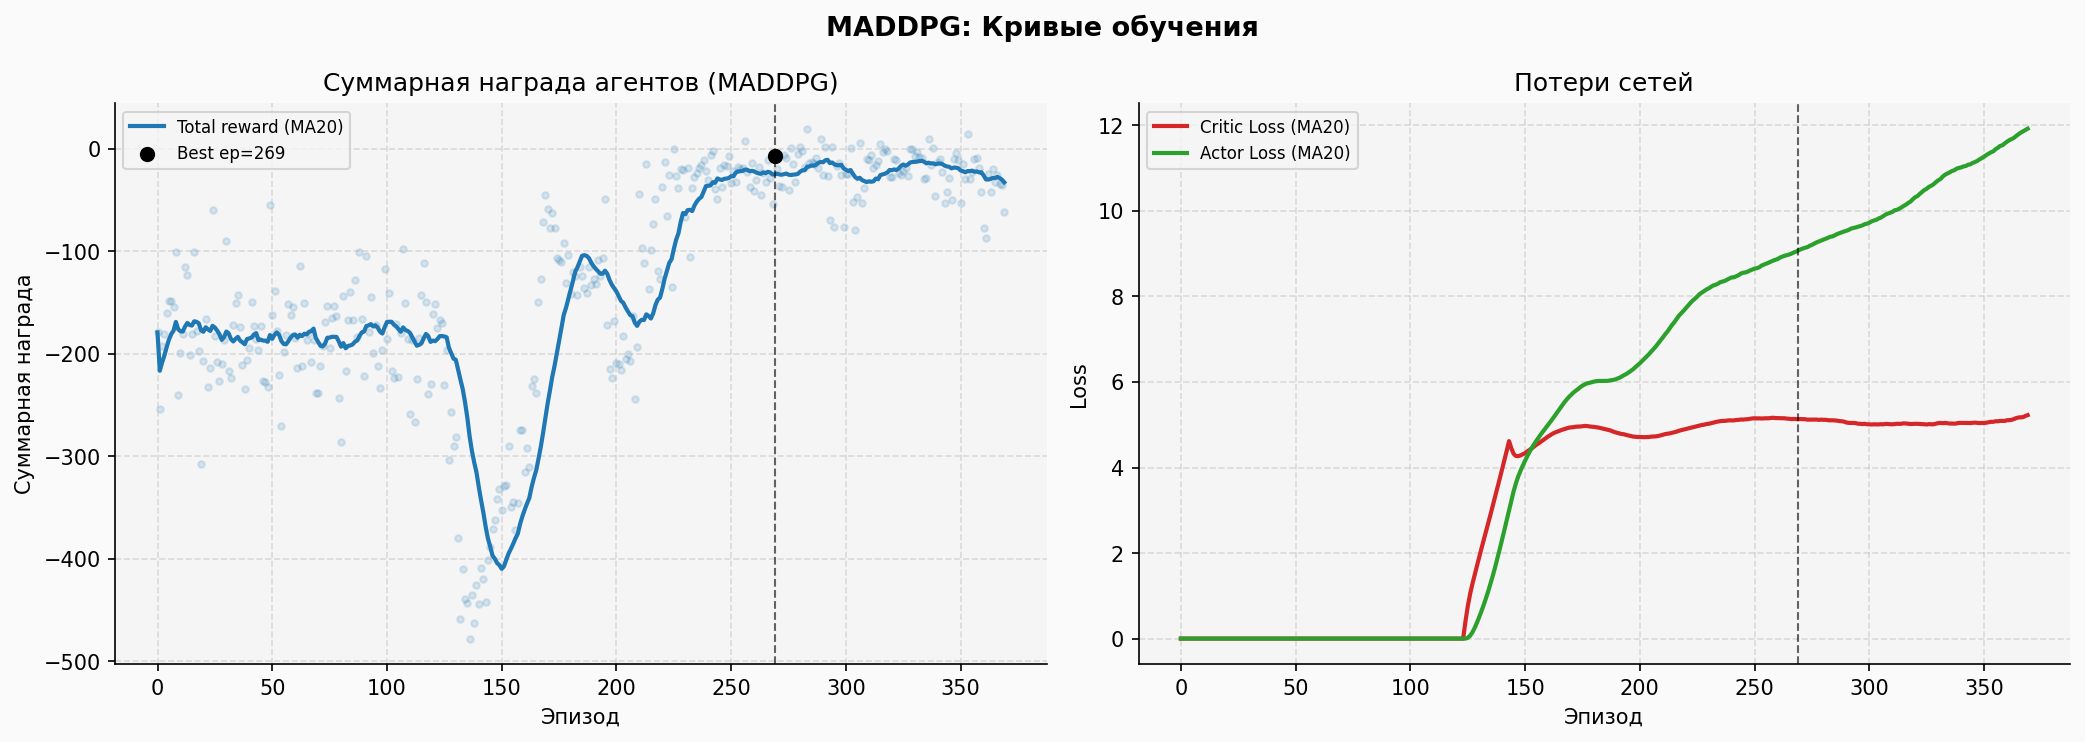

OK Обучение завершено. Final total_reward=-61.27
OK Лучшая конфигурация: episode=270, score=-13.16, eval_std=14.72
OK Лучшая траектория: /content/output/marl_best_policy_trajectory.csv
OK /content/output/marl_training_curves.png


In [19]:
import copy
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque


# ---- Конфигурация -------------------------------------------------------
MARL_CONFIG = {
    'hidden_dim': 64,
    'gamma': 0.97,
    'tau': 0.005,
    'lr_actor': 1e-4,
    'lr_critic': 1e-4,
    'batch_size': 256,
    'buffer_size': 50000,
    'noise_std': 0.15,
    'noise_min': 0.02,
    'noise_decay': 0.995,
    'target_noise': 0.08,
    'target_noise_clip': 0.15,
    'grad_clip_actor': 1.0,
    'grad_clip_critic': 1.0,
    'reward_clip': 10.0,
    'q_clip': 50.0,
    'warmup_steps': 3000,
    'updates_per_step': 1,
    'policy_delay': 2,
    'episodes': 600,
    'max_steps': 24,
    'early_stop_patience': 100,
    'early_stop_min_delta': 1.0,
    'early_stop_start': 140,
    'ma_window': 20,
    'eval_episodes': 20,
    'eval_every': 10,
    'divergence_critic_loss': 1e5,
    'seed': int(SEED) if 'SEED' in globals() else 42,
}


# ---- Сидирование --------------------------------------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(MARL_CONFIG['seed'])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используем device={DEVICE}')


# ---- Actor MLP ----------------------------------------------------------
class Actor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, act_dim), nn.Tanh()
        )

    def forward(self, obs):
        return self.net(obs)


# ---- Critic MLP (CTDE) --------------------------------------------------
class Critic(nn.Module):
    def __init__(self, state_dim, total_act_dim, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim + total_act_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, state, actions):
        x = torch.cat([state, actions], dim=-1)
        return self.net(x)


# ---- Replay Buffer ------------------------------------------------------
class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, transition):
        self.buffer.append(transition)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, min(batch_size, len(self.buffer)))
        return batch

    def __len__(self):
        return len(self.buffer)


# ---- MADDPG Agent -------------------------------------------------------
class MADDPGAgent:
    def __init__(self, agent_id, obs_dim, act_dim, state_dim, total_act_dim, cfg):
        self.id = agent_id
        self.act_dim = act_dim
        h = cfg['hidden_dim']

        self.actor = Actor(obs_dim, act_dim, h).to(DEVICE)
        self.actor_target = Actor(obs_dim, act_dim, h).to(DEVICE)
        self.actor_target.load_state_dict(self.actor.state_dict())

        self.critic = Critic(state_dim, total_act_dim, h).to(DEVICE)
        self.critic_target = Critic(state_dim, total_act_dim, h).to(DEVICE)
        self.critic_target.load_state_dict(self.critic.state_dict())

        self.opt_actor = optim.Adam(self.actor.parameters(), lr=cfg['lr_actor'])
        self.opt_critic = optim.Adam(self.critic.parameters(), lr=cfg['lr_critic'], weight_decay=1e-5)
        self.noise_std = cfg['noise_std']

    def act(self, obs, explore=True):
        obs_t = torch.as_tensor(np.array(obs, dtype=np.float32), dtype=torch.float32, device=DEVICE).unsqueeze(0)
        self.actor.eval()
        with torch.no_grad():
            a = self.actor(obs_t).squeeze(0).cpu().numpy()
        self.actor.train()
        if explore:
            a = a + np.random.randn(self.act_dim) * self.noise_std
        return np.clip(a, -1.0, 1.0).astype(np.float32)

    def soft_update(self, tau):
        for p, tp in zip(self.actor.parameters(), self.actor_target.parameters()):
            tp.data.copy_(tau * p.data + (1.0 - tau) * tp.data)
        for p, tp in zip(self.critic.parameters(), self.critic_target.parameters()):
            tp.data.copy_(tau * p.data + (1.0 - tau) * tp.data)


# ---- MADDPG Controller --------------------------------------------------
class MADDPG:
    def __init__(self, env_obj, cfg):
        self.env = env_obj
        self.cfg = cfg
        self.agents_ids = AGENTS
        self.update_step = 0
        self.best_score = -np.inf
        self.best_episode = -1
        self.best_snapshot = None
        self.best_history_idx = -1
        self.best_eval_std = np.nan
        self.best_eval_ma = np.nan
        self.best_scenario = None

        _probe_obs, _probe_gs = self.env.reset({})
        self.state_dim = int(_probe_gs.shape[0])
        self.obs_dims = {
            a: int(_probe_obs[a].shape[0]) if a in _probe_obs else self.state_dim
            for a in self.agents_ids
        }
        print(f'  MADDPG init: state_dim={self.state_dim}, obs_dims={self.obs_dims}')

        self.act_dims = {a: max(1, len(ACTION_SPACE.get(a, []))) for a in self.agents_ids}
        self.total_act_dim = sum(self.act_dims[a] for a in self.agents_ids)
        print(f'  act_dims={self.act_dims}, total_act_dim={self.total_act_dim}')

        self.agents = {}
        for a in self.agents_ids:
            obs_d = self.obs_dims.get(a, self.state_dim)
            act_d = self.act_dims.get(a, 1)
            self.agents[a] = MADDPGAgent(a, obs_d, act_d, self.state_dim, self.total_act_dim, cfg)

        self.buffer = ReplayBuffer(cfg['buffer_size'])
        self.history = []

    def _actions_to_vec(self, actions_dict):
        parts = []
        for a in self.agents_ids:
            act = actions_dict.get(a, np.zeros(self.act_dims.get(a, 1), dtype=np.float32))
            parts.append(np.asarray(act, dtype=np.float32).ravel())
        return np.concatenate(parts).astype(np.float32)

    def _scale_actions(self, agent_id, raw_action):
        specs = ACTION_SPACE.get(agent_id, [])
        raw = np.asarray(raw_action, dtype=np.float32).ravel()
        if not specs:
            return raw.tolist()
        scaled = []
        for i, spec in enumerate(specs):
            v = float(raw[i]) if i < len(raw) else 0.0
            v = spec.low + (v + 1.0) / 2.0 * (spec.high - spec.low)
            scaled.append(float(np.clip(v, spec.low, spec.high)))
        return scaled

    def _capture_snapshot(self):
        return {
            'agents': {
                a: {
                    'actor': copy.deepcopy(self.agents[a].actor.state_dict()),
                    'actor_target': copy.deepcopy(self.agents[a].actor_target.state_dict()),
                    'critic': copy.deepcopy(self.agents[a].critic.state_dict()),
                    'critic_target': copy.deepcopy(self.agents[a].critic_target.state_dict()),
                    'opt_actor': copy.deepcopy(self.agents[a].opt_actor.state_dict()),
                    'opt_critic': copy.deepcopy(self.agents[a].opt_critic.state_dict()),
                    'noise_std': float(self.agents[a].noise_std),
                }
                for a in self.agents_ids
            }
        }

    def _restore_snapshot(self, snapshot):
        if snapshot is None:
            return
        for a in self.agents_ids:
            self.agents[a].actor.load_state_dict(snapshot['agents'][a]['actor'])
            self.agents[a].actor_target.load_state_dict(snapshot['agents'][a]['actor_target'])
            self.agents[a].critic.load_state_dict(snapshot['agents'][a]['critic'])
            self.agents[a].critic_target.load_state_dict(snapshot['agents'][a]['critic_target'])
            self.agents[a].opt_actor.load_state_dict(snapshot['agents'][a]['opt_actor'])
            self.agents[a].opt_critic.load_state_dict(snapshot['agents'][a]['opt_critic'])
            self.agents[a].noise_std = float(snapshot['agents'][a]['noise_std'])

    def _ma_total_reward(self, window=None):
        if len(self.history) == 0:
            return -np.inf
        w = int(window or self.cfg['ma_window'])
        vals = [h['total_reward'] for h in self.history[-w:]]
        return float(np.mean(vals))

    def _eval_policy(self, scenario=None, episodes=None):
        n_eval = int(episodes or self.cfg['eval_episodes'])
        eval_rewards = []
        eval_agent_rewards = {a: [] for a in self.agents_ids}

        for _ in range(n_eval):
            obs_dict, global_s = self.env.reset(scenario or {})
            ep_total = 0.0
            ep_agent = {a: 0.0 for a in self.agents_ids}

            for _step in range(self.cfg['max_steps']):
                raw_actions = {
                    a: self.agents[a].act(obs_dict.get(a, global_s), explore=False)
                    for a in self.agents_ids
                }
                scaled_actions = {
                    a: self._scale_actions(a, raw_actions[a])
                    for a in self.agents_ids
                }
                next_obs, next_gs, rewards, done = self.env.step(scaled_actions)

                for a in self.agents_ids:
                    ep_agent[a] += float(rewards.get(a, 0.0))
                ep_total += float(sum(rewards.get(a, 0.0) for a in self.agents_ids))

                obs_dict, global_s = next_obs, next_gs
                if done:
                    break

            eval_rewards.append(ep_total)
            for a in self.agents_ids:
                eval_agent_rewards[a].append(ep_agent[a])

        out = {
            'mean_total_reward': float(np.mean(eval_rewards)),
            'std_total_reward': float(np.std(eval_rewards)),
            'min_total_reward': float(np.min(eval_rewards)),
            'max_total_reward': float(np.max(eval_rewards)),
            'episodes': n_eval,
        }
        for a in self.agents_ids:
            out[f'mean_{a}'] = float(np.mean(eval_agent_rewards[a]))
            out[f'std_{a}'] = float(np.std(eval_agent_rewards[a]))
        return out

    def rollout_policy(self, scenario=None, horizon=None, explore=False, record_history=True):
        obs_dict, global_s = self.env.reset(scenario or {})
        hor = int(horizon or self.cfg['max_steps'])
        rows = []

        for step in range(hor):
            raw_actions = {
                a: self.agents[a].act(obs_dict.get(a, global_s), explore=explore)
                for a in self.agents_ids
            }
            scaled_actions = {
                a: self._scale_actions(a, raw_actions[a])
                for a in self.agents_ids
            }
            next_obs, next_gs, rewards, done = self.env.step(scaled_actions)
            real_state = self.env.current_real_state()

            row = {
                'step': int(step),
                'episode_reward_total': float(sum(rewards.get(a, 0.0) for a in self.agents_ids)),
            }

            for k, v in real_state.items():
                row[k] = float(v)

            for a in self.agents_ids:
                row[f'r_{a}'] = float(rewards.get(a, 0.0))

            for a in self.agents_ids:
                raw = np.asarray(raw_actions[a], dtype=np.float32).ravel()
                scaled = np.asarray(scaled_actions[a], dtype=np.float32).ravel()
                for j in range(len(raw)):
                    row[f'{a}_raw_a{j}'] = float(raw[j])
                for j in range(len(scaled)):
                    row[f'{a}_a{j}'] = float(scaled[j])

            rows.append(row)
            obs_dict, global_s = next_obs, next_gs
            if done:
                break

        df_roll = pd.DataFrame(rows)
        if record_history:
            return df_roll
        return df_roll

    def train(self, n_episodes=600):
        cfg = self.cfg
        mean_oil = float(states['oil_price_urals'].mean()) if 'oil_price_urals' in states.columns else 70.0
        base_scenario = {
            'oil_path': [mean_oil] * (cfg['max_steps'] + 2),
            'sanction_intensity': 0.3,
        }
        self.best_scenario = dict(base_scenario)

        global_step = 0
        bad_epochs = 0
        last_eval = None

        for ep in range(n_episodes):
            obs_dict, global_s = self.env.reset(base_scenario)
            ep_rewards = {a: 0.0 for a in self.agents_ids}
            ep_actor_loss = 0.0
            ep_critic_loss = 0.0
            ep_updates = 0

            for step in range(cfg['max_steps']):
                raw_actions = {
                    a: self.agents[a].act(obs_dict.get(a, global_s), explore=True)
                    for a in self.agents_ids
                }
                scaled_actions = {
                    a: self._scale_actions(a, raw_actions[a])
                    for a in self.agents_ids
                }
                act_vec = self._actions_to_vec(raw_actions)

                next_obs, next_gs, rewards, done = self.env.step(scaled_actions)

                rewards_clipped = {
                    a: float(np.clip(rewards.get(a, 0.0), -cfg['reward_clip'], cfg['reward_clip']))
                    for a in self.agents_ids
                }

                self.buffer.push({
                    'obs': {a: np.asarray(obs_dict.get(a, global_s), dtype=np.float32) for a in self.agents_ids},
                    'global_state': np.asarray(global_s, dtype=np.float32).copy(),
                    'actions': {a: np.asarray(raw_actions[a], dtype=np.float32) for a in self.agents_ids},
                    'act_vec': act_vec.copy(),
                    'rewards': dict(rewards_clipped),
                    'next_obs': {a: np.asarray(next_obs.get(a, next_gs), dtype=np.float32) for a in self.agents_ids},
                    'next_gs': np.asarray(next_gs, dtype=np.float32).copy(),
                    'done': bool(done),
                })

                obs_dict, global_s = next_obs, next_gs
                global_step += 1

                for a in self.agents_ids:
                    ep_rewards[a] += float(rewards_clipped.get(a, 0.0))

                if len(self.buffer) >= cfg['batch_size'] and global_step >= cfg['warmup_steps']:
                    for _ in range(cfg['updates_per_step']):
                        al, cl = self._update(self.buffer.sample(cfg['batch_size']))
                        ep_actor_loss += al
                        ep_critic_loss += cl
                        ep_updates += 1

                if done:
                    break

            for ag in self.agents.values():
                ag.noise_std = max(cfg['noise_min'], ag.noise_std * cfg['noise_decay'])

            total_r = float(sum(ep_rewards.values()))
            actor_loss_avg = float(ep_actor_loss / max(ep_updates, 1))
            critic_loss_avg = float(ep_critic_loss / max(ep_updates, 1))

            row = {
                'episode': ep,
                'total_reward': total_r,
                'actor_loss': actor_loss_avg,
                'critic_loss': critic_loss_avg,
                **{f'r_{a}': float(ep_rewards[a]) for a in self.agents_ids}
            }
            self.history.append(row)

            ma_reward = self._ma_total_reward(cfg['ma_window'])

            need_eval = (
                ep >= cfg['early_stop_start'] and
                ((ep + 1) % cfg['eval_every'] == 0 or ep == cfg['early_stop_start'])
            )

            if need_eval:
                last_eval = self._eval_policy(base_scenario, episodes=cfg['eval_episodes'])
                eval_score = float(last_eval['mean_total_reward'])
                eval_std = float(last_eval['std_total_reward'])
            else:
                eval_score = float(last_eval['mean_total_reward']) if last_eval is not None else ma_reward
                eval_std = float(last_eval['std_total_reward']) if last_eval is not None else np.nan

            if need_eval:
                improvement = eval_score - self.best_score
                if improvement > cfg['early_stop_min_delta']:
                    self.best_score = float(eval_score)
                    self.best_episode = int(ep)
                    self.best_snapshot = self._capture_snapshot()
                    self.best_history_idx = len(self.history) - 1
                    self.best_eval_std = float(eval_std)
                    self.best_eval_ma = float(ma_reward)
                    bad_epochs = 0
                else:
                    bad_epochs += cfg['eval_every']
            elif ep < cfg['early_stop_start']:
                if ma_reward > self.best_score:
                    self.best_score = float(ma_reward)
                    self.best_episode = int(ep)
                    self.best_snapshot = self._capture_snapshot()
                    self.best_history_idx = len(self.history) - 1
                    self.best_eval_std = np.nan
                    self.best_eval_ma = float(ma_reward)

            if (ep + 1) % 20 == 0 or ep == 0:
                eval_msg = f'{eval_score:.2f}' if np.isfinite(eval_score) else 'nan'
                eval_std_msg = f'{eval_std:.2f}' if np.isfinite(eval_std) else 'nan'
                print(
                    f'  Ep {ep+1:3d}/{n_episodes}: '
                    f'total_r={total_r:.2f}, ma{cfg['ma_window']}={ma_reward:.2f}, '
                    f'eval={eval_msg}±{eval_std_msg}, best={self.best_score:.2f}, '
                    f'actor={actor_loss_avg:.4f}, critic={critic_loss_avg:.4f}, '
                    f'noise={list(self.agents.values())[0].noise_std:.3f}, updates={ep_updates}'
                )

            if not np.isfinite(critic_loss_avg) or critic_loss_avg > cfg['divergence_critic_loss']:
                print(f'  Early stop: critic divergence at episode {ep+1}')
                break

            if ep + 1 >= cfg['early_stop_start'] and bad_epochs >= cfg['early_stop_patience']:
                print(f'  Early stop: no improvement for {bad_epochs} episodes')
                break

        if self.best_snapshot is not None:
            self._restore_snapshot(self.best_snapshot)
            print(
                f'  Restored best configuration from episode {self.best_episode + 1} '
                f'with score={self.best_score:.2f}, eval_std={self.best_eval_std:.2f}'
            )

        return pd.DataFrame(self.history)

    def _update(self, batch):
        cfg = self.cfg
        self.update_step += 1

        gs_t = torch.as_tensor(np.stack([t['global_state'] for t in batch]), dtype=torch.float32, device=DEVICE)
        gs_nt = torch.as_tensor(np.stack([t['next_gs'] for t in batch]), dtype=torch.float32, device=DEVICE)
        av_t = torch.as_tensor(np.stack([t['act_vec'] for t in batch]), dtype=torch.float32, device=DEVICE)

        total_actor_loss = 0.0
        total_critic_loss = 0.0

        with torch.no_grad():
            next_acts_list = []
            for a in self.agents_ids:
                next_o = torch.as_tensor(
                    np.stack([t['next_obs'].get(a, t['next_gs']) for t in batch]),
                    dtype=torch.float32, device=DEVICE
                )
                na = self.agents[a].actor_target(next_o)
                noise = torch.randn_like(na) * cfg['target_noise']
                noise = torch.clamp(noise, -cfg['target_noise_clip'], cfg['target_noise_clip'])
                na = torch.clamp(na + noise, -1.0, 1.0)
                next_acts_list.append(na)
            next_av = torch.cat(next_acts_list, dim=-1)

        for a in self.agents_ids:
            ag = self.agents[a]

            rewards_t = torch.as_tensor(
                [float(t['rewards'].get(a, 0.0)) for t in batch],
                dtype=torch.float32, device=DEVICE
            ).unsqueeze(1)
            dones_t = torch.as_tensor(
                [float(t['done']) for t in batch],
                dtype=torch.float32, device=DEVICE
            ).unsqueeze(1)

            with torch.no_grad():
                q_next = ag.critic_target(gs_nt, next_av)
                y_target = rewards_t + cfg['gamma'] * q_next * (1.0 - dones_t)
                y_target = torch.clamp(y_target, -cfg['q_clip'], cfg['q_clip'])

            q_pred = ag.critic(gs_t, av_t)
            critic_loss = nn.SmoothL1Loss()(q_pred, y_target)

            ag.opt_critic.zero_grad(set_to_none=True)
            critic_loss.backward()
            torch.nn.utils.clip_grad_norm_(ag.critic.parameters(), cfg['grad_clip_critic'])
            ag.opt_critic.step()
            total_critic_loss += float(critic_loss.item())

            if self.update_step % cfg['policy_delay'] == 0:
                obs_t = torch.as_tensor(
                    np.stack([t['obs'].get(a, t['global_state']) for t in batch]),
                    dtype=torch.float32, device=DEVICE
                )

                curr_acts_list = []
                for a2 in self.agents_ids:
                    o2 = torch.as_tensor(
                        np.stack([t['obs'].get(a2, t['global_state']) for t in batch]),
                        dtype=torch.float32, device=DEVICE
                    )
                    if a2 == a:
                        curr_acts_list.append(ag.actor(obs_t))
                    else:
                        with torch.no_grad():
                            curr_acts_list.append(self.agents[a2].actor(o2))

                curr_av = torch.cat(curr_acts_list, dim=-1)
                actor_loss = -ag.critic(gs_t, curr_av).mean()

                ag.opt_actor.zero_grad(set_to_none=True)
                actor_loss.backward()
                torch.nn.utils.clip_grad_norm_(ag.actor.parameters(), cfg['grad_clip_actor'])
                ag.opt_actor.step()
                total_actor_loss += float(actor_loss.item())

                ag.soft_update(cfg['tau'])

        return total_actor_loss, total_critic_loss


# ---- Обучение -----------------------------------------------------------
print('Запуск обучения MADDPG...')
print(
    f'  Config: episodes={MARL_CONFIG["episodes"]}, max_steps={MARL_CONFIG["max_steps"]}, '
    f'hidden={MARL_CONFIG["hidden_dim"]}, warmup={MARL_CONFIG["warmup_steps"]}, '
    f'policy_delay={MARL_CONFIG["policy_delay"]}, eval_episodes={MARL_CONFIG["eval_episodes"]}'
)

maddpg = MADDPG(env, MARL_CONFIG)
history_df = maddpg.train(n_episodes=MARL_CONFIG['episodes'])
history_df.to_csv(os.path.join(OUT_DIR, 'marl_training_history.csv'), index=False)


# ---- Лучшая траектория --------------------------------------------------
best_scenario = maddpg.best_scenario if maddpg.best_scenario is not None else {
    'oil_path': [float(states['oil_price_urals'].mean())] * (MARL_CONFIG['max_steps'] + 2),
    'sanction_intensity': 0.3,
}
best_traj_df = maddpg.rollout_policy(
    scenario=best_scenario,
    horizon=MARL_CONFIG['max_steps'],
    explore=False,
    record_history=True
)
best_traj_path = os.path.join(OUT_DIR, 'marl_best_policy_trajectory.csv')
best_traj_df.to_csv(best_traj_path, index=False)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MADDPG: Кривые обучения', fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(
    history_df['episode'],
    history_df['total_reward'].rolling(20, min_periods=1).mean(),
    color=PALETTE[0], lw=2, label='Total reward (MA20)'
)
ax.scatter(history_df['episode'], history_df['total_reward'], alpha=0.15, s=10, color=PALETTE[0])
if len(history_df) > 0 and maddpg.best_episode >= 0:
    best_ep = int(maddpg.best_episode)
    best_val = float(history_df.loc[history_df['episode'] == best_ep, 'total_reward'].iloc[0])
    ax.axvline(best_ep, color='black', ls='--', lw=1, alpha=0.6)
    ax.scatter([best_ep], [best_val], color='black', s=40, zorder=5, label=f'Best ep={best_ep}')
ax.set_xlabel('Эпизод')
ax.set_ylabel('Суммарная награда')
ax.set_title('Суммарная награда агентов (MADDPG)')
ax.legend(fontsize=8)

ax = axes[1]
ax.plot(
    history_df['episode'],
    history_df['critic_loss'].rolling(20, min_periods=1).mean(),
    color=PALETTE[1], lw=2, label='Critic Loss (MA20)'
)
ax.plot(
    history_df['episode'],
    history_df['actor_loss'].rolling(20, min_periods=1).mean(),
    color=PALETTE[2], lw=2, label='Actor Loss (MA20)'
)
if len(history_df) > 0 and maddpg.best_episode >= 0:
    ax.axvline(int(maddpg.best_episode), color='black', ls='--', lw=1, alpha=0.6)
ax.set_xlabel('Эпизод')
ax.set_ylabel('Loss')
ax.set_title('Потери сетей')
ax.legend(fontsize=8)

plt.tight_layout()
fname_curves = os.path.join(OUT_DIR, 'marl_training_curves.png')
plt.savefig(fname_curves, bbox_inches='tight', dpi=150)
plt.show()

final_reward = float(history_df["total_reward"].iloc[-1]) if len(history_df) else float('nan')
print(f'OK Обучение завершено. Final total_reward={final_reward:.2f}')
print(f'OK Лучшая конфигурация: episode={maddpg.best_episode + 1}, score={maddpg.best_score:.2f}, eval_std={maddpg.best_eval_std:.2f}')
print(f'OK Лучшая траектория: {best_traj_path}')
print(f'OK {fname_curves}')

---
## Раздел 20. Каталог сценариев: 20+ исторических кризисов + 20+ будущих 2026-2050

**Исторические сценарии** (2008-2025): реальные кризисные эпизоды с параметрами нефтяных шоков, санкционного давления, валютной волатильности.  
**Будущие сценарии** (2026-2050): гипотетические реалистичные траектории — затяжной дефляционный нефтяной рынок, новые санкционные волны, энергетический переход, демографическое давление и др.  
Каталог сохраняется в `output/scenarios_catalog.csv`.


In [20]:
# ---- Исторические сценарии кризисов (>=20) ------------------------------
HISTORICAL_SCENARIOS = [
    {'id': 'H01', 'name': 'Мировой финансовый кризис 2008-2009',
     'period': '2008-09 - 2009-06', 'oil_level': 35.0, 'fx_shock': 0.35,
     'sanction_intensity': 0.0,
     'description': 'Обвал нефти с $147 до $35, девальвация рубля ~35%'},
    {'id': 'H02', 'name': 'Восстановительный рост 2010-2011',
     'period': '2010-01 - 2011-12', 'oil_level': 95.0, 'fx_shock': 0.0,
     'sanction_intensity': 0.0,
     'description': 'Рост нефти до $100+, профицит бюджета, отток капитала замедлился'},
    {'id': 'H03', 'name': 'Волатильность ЕЗ-кризиса 2012-2013',
     'period': '2012-01 - 2013-12', 'oil_level': 105.0, 'fx_shock': 0.05,
     'sanction_intensity': 0.0,
     'description': 'Высокая нефть, умеренная волатильность, стагнация в ЕС'},
    {'id': 'H04', 'name': 'Крымский шок и первые санкции 2014',
     'period': '2014-03 - 2014-12', 'oil_level': 80.0, 'fx_shock': 0.20,
     'sanction_intensity': 0.3,
     'description': 'Первые пакеты санкций ЕС/США, рубль -25%, ограниченный доступ к капиталу'},
    {'id': 'H05', 'name': 'Нефтяной обвал 2014-2015',
     'period': '2014-07 - 2016-02', 'oil_level': 30.0, 'fx_shock': 0.50,
     'sanction_intensity': 0.35,
     'description': 'Brent $30, рубль -50% к USD, ключевая ставка 17%, рецессия'},
    {'id': 'H06', 'name': 'Стабилизация и ОПЕК+ 2016-2017',
     'period': '2016-01 - 2017-12', 'oil_level': 52.0, 'fx_shock': 0.05,
     'sanction_intensity': 0.35,
     'description': 'Сделка ОПЕК+, постепенное восстановление нефти, снижение ставки'},
    {'id': 'H07', 'name': 'Восстановление и новые санкции 2018',
     'period': '2018-01 - 2018-12', 'oil_level': 70.0, 'fx_shock': 0.15,
     'sanction_intensity': 0.5,
     'description': 'Новые санкции апрель 2018, волатильность рубля, нефть >$70'},
    {'id': 'H08', 'name': 'Прeдпандемийная стабильность 2019',
     'period': '2019-01 - 2019-12', 'oil_level': 64.0, 'fx_shock': 0.05,
     'sanction_intensity': 0.45,
     'description': 'Относительная стабильность, ФНБ наполняется, инфляция ~4%'},
    {'id': 'H09', 'name': 'COVID-19 шок 2020',
     'period': '2020-02 - 2020-12', 'oil_level': 25.0, 'fx_shock': 0.25,
     'sanction_intensity': 0.45,
     'description': 'Пандемия, сделка ОПЕК+ распалась (март 2020), нефть -70%, рубль -25%'},
    {'id': 'H10', 'name': 'Постковидное восстановление 2021',
     'period': '2021-01 - 2021-12', 'oil_level': 70.0, 'fx_shock': 0.05,
     'sanction_intensity': 0.45,
     'description': 'Восстановление спроса, рост нефти до $85, ускорение инфляции'},
    {'id': 'H11', 'name': 'Февральский шок 2022 — пакет 1-4',
     'period': '2022-02 - 2022-06', 'oil_level': 100.0, 'fx_shock': 0.40,
     'sanction_intensity': 0.95,
     'description': 'СВО, масштабные санкции, заморозка резервов, рубль -40% затем отскок'},
    {'id': 'H12', 'name': 'Адаптация к санкциям 2022 H2',
     'period': '2022-07 - 2022-12', 'oil_level': 85.0, 'fx_shock': -0.15,
     'sanction_intensity': 0.9,
     'description': 'Рубль укрепился за счёт экспортных требований, профицит бюджета'},
    {'id': 'H13', 'name': 'Нефтяное эмбарго и ценовой потолок 2022-2023',
     'period': '2022-12 - 2023-06', 'oil_level': 65.0, 'fx_shock': 0.20,
     'sanction_intensity': 0.95,
     'description': 'G7 price cap $60/bbl, эмбарго ЕС, дефицит бюджета растёт'},
    {'id': 'H14', 'name': 'Бюджетный дефицит и ослабление рубля 2023',
     'period': '2023-01 - 2023-12', 'oil_level': 72.0, 'fx_shock': 0.35,
     'sanction_intensity': 0.9,
     'description': 'Дефицит >2% ВВП, рубль 90-100/USD, повышение ставки до 16%'},
    {'id': 'H15', 'name': 'Высокая ставка и инфляционное давление 2024',
     'period': '2024-01 - 2024-12', 'oil_level': 78.0, 'fx_shock': 0.15,
     'sanction_intensity': 0.92,
     'description': 'КС 16-21%, перегрев кредитования, бюджетный импульс от оборонных расходов'},
    {'id': 'H16', 'name': 'Жёсткая ДКП и замедление 2025',
     'period': '2025-01 - 2025-12', 'oil_level': 72.0, 'fx_shock': 0.10,
     'sanction_intensity': 0.93,
     'description': 'КС 21%, замедление кредитования, снижение инфляции, ненефтегаз. дефицит'},
    {'id': 'H17', 'name': 'Нефтяной мини-шок 2023 Q3 (Ближний Восток)',
     'period': '2023-10 - 2024-02', 'oil_level': 90.0, 'fx_shock': -0.05,
     'sanction_intensity': 0.9,
     'description': 'Конфликт на БВ, спайк нефти +15%, временное укрепление рубля'},
    {'id': 'H18', 'name': 'Вторичные санкции против банков 2024',
     'period': '2024-03 - 2024-09', 'oil_level': 80.0, 'fx_shock': 0.12,
     'sanction_intensity': 0.96,
     'description': 'Ограничения на НКЦ, давление на импорт, скрытые схемы расчётов'},
    {'id': 'H19', 'name': 'Дефляционная нефть 2015-2016 аналог',
     'period': '2015-07 - 2016-06', 'oil_level': 30.0, 'fx_shock': 0.45,
     'sanction_intensity': 0.38,
     'description': 'Повторный тест нефтяного минимума, ФНБ истощается, секвестр бюджета'},
    {'id': 'H20', 'name': 'Дефолт 1998 — исторический бенчмарк',
     'period': '1998-01 - 1999-06', 'oil_level': 10.0, 'fx_shock': 2.5,
     'sanction_intensity': 0.0,
     'description': 'ГКО-дефолт, рубль -75%, нефть $10, системный банковский кризис'},
    {'id': 'H21', 'name': 'Нефтяной бум 2007-2008',
     'period': '2007-01 - 2008-07', 'oil_level': 147.0, 'fx_shock': -0.10,
     'sanction_intensity': 0.0,
     'description': 'Нефть $147, резервы ЦБ $600 млрд, двузначный рост ВВП, перегрев'},
]

# ---- Будущие сценарии 2026-2050 (>=20) -----------------------------------
FUTURE_SCENARIOS = [
    {'id': 'F01', 'name': 'Базовый сценарий 2026-2030: умеренная адаптация',
     'horizon': '2026-2030', 'oil_path': 'flat_70', 'sanction_path': 'stable_0.9',
     'key_rate_path': 'gradual_decline', 'gdp_growth': 1.5,
     'description': 'Нефть ~$70, санкции стабильны, КС снижается до 12%, умеренный рост'},
    {'id': 'F02', 'name': 'Оптимистичный: снятие части санкций 2027',
     'horizon': '2026-2035', 'oil_path': 'rising_85', 'sanction_path': 'declining_0.5',
     'key_rate_path': 'rapid_decline', 'gdp_growth': 3.0,
     'description': 'Мирное урегулирование 2027, частичное снятие санкций, рост +3%/г'},
    {'id': 'F03', 'name': 'Пессимистичный: новый пакет санкций 2026',
     'horizon': '2026-2030', 'oil_path': 'flat_60', 'sanction_path': 'escalating_0.99',
     'key_rate_path': 'high_stable', 'gdp_growth': -1.0,
     'description': 'SDN на НКЦ2, oil price cap $50, рецессия -1%/г'},
    {'id': 'F04', 'name': 'Энергетический переход: нефть $45 к 2035',
     'horizon': '2026-2040', 'oil_path': 'declining_45', 'sanction_path': 'stable_0.9',
     'key_rate_path': 'moderate', 'gdp_growth': 0.5,
     'description': 'Глобальный энергопереход ускоряется, нефть $45 к 2035, структурный дефицит'},
    {'id': 'F05', 'name': 'Разворот на Восток: Китай ключевой партнёр 2026-2035',
     'horizon': '2026-2035', 'oil_path': 'flat_70', 'sanction_path': 'stable_0.88',
     'key_rate_path': 'gradual_decline', 'gdp_growth': 2.0,
     'description': 'Расчёты в CNY >50%, СПГ в Азию, диверсификация экспорта'},
    {'id': 'F06', 'name': 'Демографический стресс 2030-2040',
     'horizon': '2030-2040', 'oil_path': 'flat_65', 'sanction_path': 'stable_0.85',
     'key_rate_path': 'moderate', 'gdp_growth': 0.8,
     'description': 'Старение населения, нехватка рабочей силы, пенсионная нагрузка растёт'},
    {'id': 'F07', 'name': 'Технологическая изоляция 2026-2030',
     'horizon': '2026-2030', 'oil_path': 'flat_68', 'sanction_path': 'escalating_0.97',
     'key_rate_path': 'high_stable', 'gdp_growth': 0.0,
     'description': 'Полные технологические санкции, стагнация TFP, нулевой рост'},
    {'id': 'F08', 'name': 'Нефтяной суперцикл 2028-2033',
     'horizon': '2028-2033', 'oil_path': 'rising_120', 'sanction_path': 'stable_0.88',
     'key_rate_path': 'gradual_decline', 'gdp_growth': 4.0,
     'description': 'Дефицит инвестиций в добычу глобально, нефть $120, бюджетный профицит'},
    {'id': 'F09', 'name': 'Дедолларизация и CBDC РФ 2027-2032',
     'horizon': '2027-2032', 'oil_path': 'flat_70', 'sanction_path': 'stable_0.9',
     'key_rate_path': 'gradual_decline', 'gdp_growth': 1.8,
     'description': 'Цифровой рубль ЦБ, расчёты в национальных валютах, снижение USD-долга'},
    {'id': 'F10', 'name': 'Фискальный кризис: ФНБ обнуляется 2028',
     'horizon': '2026-2030', 'oil_path': 'declining_55', 'sanction_path': 'escalating_0.95',
     'key_rate_path': 'rising', 'gdp_growth': -0.5,
     'description': 'Истощение ФНБ, рост внутреннего долга >25% ВВП, бюджетный кризис'},
    {'id': 'F11', 'name': 'Климатическая политика: углеродный налог ЕС',
     'horizon': '2026-2034', 'oil_path': 'flat_65', 'sanction_path': 'stable_0.9',
     'key_rate_path': 'moderate', 'gdp_growth': 1.0,
     'description': 'CBAM ЕС полностью, углеродный налог на экспорт металлов и удобрений'},
    {'id': 'F12', 'name': 'Геополитическая разрядка 2030',
     'horizon': '2030-2040', 'oil_path': 'rising_80', 'sanction_path': 'declining_0.4',
     'key_rate_path': 'rapid_decline', 'gdp_growth': 3.5,
     'description': 'Нормализация отношений, возврат иностранных инвестиций, рост >3%'},
    {'id': 'F13', 'name': 'Война за ресурсы Арктики 2030-2035',
     'horizon': '2030-2035', 'oil_path': 'volatile_80', 'sanction_path': 'escalating_0.96',
     'key_rate_path': 'high_stable', 'gdp_growth': 1.5,
     'description': 'Арктические ресурсы, новые конфликты интересов, высокий ОПК-расход'},
    {'id': 'F14', 'name': 'Деиндустриализация при падении нефти 2035-2045',
     'horizon': '2035-2045', 'oil_path': 'declining_30', 'sanction_path': 'stable_0.85',
     'key_rate_path': 'rising', 'gdp_growth': -1.5,
     'description': 'Нефть $30 к 2040, деиндустриализация, необходимость диверсификации ВВП'},
    {'id': 'F15', 'name': 'IT-экспортная модель 2026-2035',
     'horizon': '2026-2035', 'oil_path': 'flat_70', 'sanction_path': 'partial_0.7',
     'key_rate_path': 'gradual_decline', 'gdp_growth': 2.5,
     'description': 'Рост IT-экспорта в дружественные страны, диверсификация сервисов'},
    {'id': 'F16', 'name': 'Валютный кризис 2026: рубль 130+',
     'horizon': '2026-2027', 'oil_path': 'flat_60', 'sanction_path': 'escalating_0.98',
     'key_rate_path': 'emergency_rise', 'gdp_growth': -2.0,
     'description': 'Новые санкции + падение нефти, рубль 130+ USD, экстренное повышение КС'},
    {'id': 'F17', 'name': 'Долговой суперцикл 2026-2040',
     'horizon': '2026-2040', 'oil_path': 'flat_68', 'sanction_path': 'stable_0.9',
     'key_rate_path': 'gradual_decline', 'gdp_growth': 1.5,
     'description': 'Рост ОФЗ-долга до 30% ВВП, необходимость фискальной консолидации'},
    {'id': 'F18', 'name': 'Агропродовольственная экспансия 2026-2035',
     'horizon': '2026-2035', 'oil_path': 'flat_70', 'sanction_path': 'partial_0.75',
     'key_rate_path': 'moderate', 'gdp_growth': 2.2,
     'description': 'Рост с/х экспорта (зерно, удобрения) компенсирует нефтяную зависимость'},
    {'id': 'F19', 'name': 'Ядерная энергетика и атомный экспорт 2026-2040',
     'horizon': '2026-2040', 'oil_path': 'flat_65', 'sanction_path': 'partial_0.8',
     'key_rate_path': 'moderate', 'gdp_growth': 2.0,
     'description': 'Росатом строит АЭС в >20 странах, стабильный доход, диверсификация'},
    {'id': 'F20', 'name': 'Долгосрочный базовый тренд 2026-2050',
     'horizon': '2026-2050', 'oil_path': 'gradual_decline_60', 'sanction_path': 'stable_0.88',
     'key_rate_path': 'gradual_decline', 'gdp_growth': 1.2,
     'description': 'Медленная диверсификация экономики, стабильные санкции, умеренный рост'},
    {'id': 'F21', 'name': 'Рецессия мировой экономики 2028-2030',
     'horizon': '2028-2030', 'oil_path': 'declining_50', 'sanction_path': 'stable_0.9',
     'key_rate_path': 'high_stable', 'gdp_growth': -0.8,
     'description': 'Глобальная рецессия, падение спроса на сырьё, сжатие экспорта'},
]

# ---- Каталог сценариев в DataFrame --------------------------------------
import pandas as pd
hist_df = pd.DataFrame(HISTORICAL_SCENARIOS)
hist_df['type'] = 'historical'
fut_df = pd.DataFrame(FUTURE_SCENARIOS)
fut_df['type'] = 'future'
scenarios_catalog = pd.concat([hist_df, fut_df], ignore_index=True)
fname_sc = os.path.join(OUT_DIR, 'scenarios_catalog.csv')
scenarios_catalog.to_csv(fname_sc, index=False, encoding='utf-8-sig')
print(f'OK scenarios_catalog.csv: {len(hist_df)} исторических + {len(fut_df)} будущих = {len(scenarios_catalog)} всего')
scenarios_catalog[['id','type','name']].to_string(index=False)


OK scenarios_catalog.csv: 21 исторических + 21 будущих = 42 всего


' id       type                                                 name\nH01 historical                  Мировой финансовый кризис 2008-2009\nH02 historical                     Восстановительный рост 2010-2011\nH03 historical                   Волатильность ЕЗ-кризиса 2012-2013\nH04 historical                   Крымский шок и первые санкции 2014\nH05 historical                             Нефтяной обвал 2014-2015\nH06 historical                       Стабилизация и ОПЕК+ 2016-2017\nH07 historical                  Восстановление и новые санкции 2018\nH08 historical                    Прeдпандемийная стабильность 2019\nH09 historical                                    COVID-19 шок 2020\nH10 historical                     Постковидное восстановление 2021\nH11 historical                     Февральский шок 2022 — пакет 1-4\nH12 historical                         Адаптация к санкциям 2022 H2\nH13 historical         Нефтяное эмбарго и ценовой потолок 2022-2023\nH14 historical            Бюджетн

---
## Раздел 21. Прогон сценариев, прогноз 2026–2050 и эталонное сравнение

Каждый из 40+ сценариев прогоняется через обученную среду MacroFinEnv с политиками MADDPG. Дополнительно запускается **наивный бенчмарк** (фиксированные исторически усреднённые действия агентов). Результаты агрегируются по временным горизонтам 2026-2030, 2031-2040, 2041-2050.  
Артефакты: `output/optimal_policies.csv`, `output/forecast_2026_2050.csv`.


Прогон 21 сценариев x 300 мес. (best-policy MARL + benchmark bundle)...
  F01: MARL avg_CPI=3.58% | avg_KR=24.47% | avg_USD=66.9 | reward_gap=6164.9
  F02: MARL avg_CPI=2.07% | avg_KR=18.46% | avg_USD=69.4 | reward_gap=6552.9
  F03: MARL avg_CPI=1.66% | avg_KR=17.38% | avg_USD=77.4 | reward_gap=7083.2
  F04: MARL avg_CPI=2.23% | avg_KR=23.91% | avg_USD=76.4 | reward_gap=6508.4
  F05: MARL avg_CPI=1.97% | avg_KR=20.56% | avg_USD=72.7 | reward_gap=6638.1
  F06: MARL avg_CPI=3.88% | avg_KR=27.52% | avg_USD=58.6 | reward_gap=5848.9
  F07: MARL avg_CPI=1.81% | avg_KR=17.50% | avg_USD=74.2 | reward_gap=6792.3
  F08: MARL avg_CPI=4.37% | avg_KR=25.30% | avg_USD=61.0 | reward_gap=5821.4
  F09: MARL avg_CPI=2.34% | avg_KR=19.58% | avg_USD=71.1 | reward_gap=6938.6
  F10: MARL avg_CPI=2.14% | avg_KR=17.20% | avg_USD=74.1 | reward_gap=7068.8
  F11: MARL avg_CPI=3.14% | avg_KR=24.87% | avg_USD=68.3 | reward_gap=6247.4
  F12: MARL avg_CPI=2.89% | avg_KR=20.61% | avg_USD=66.1 | reward_gap=6912.8
  F1

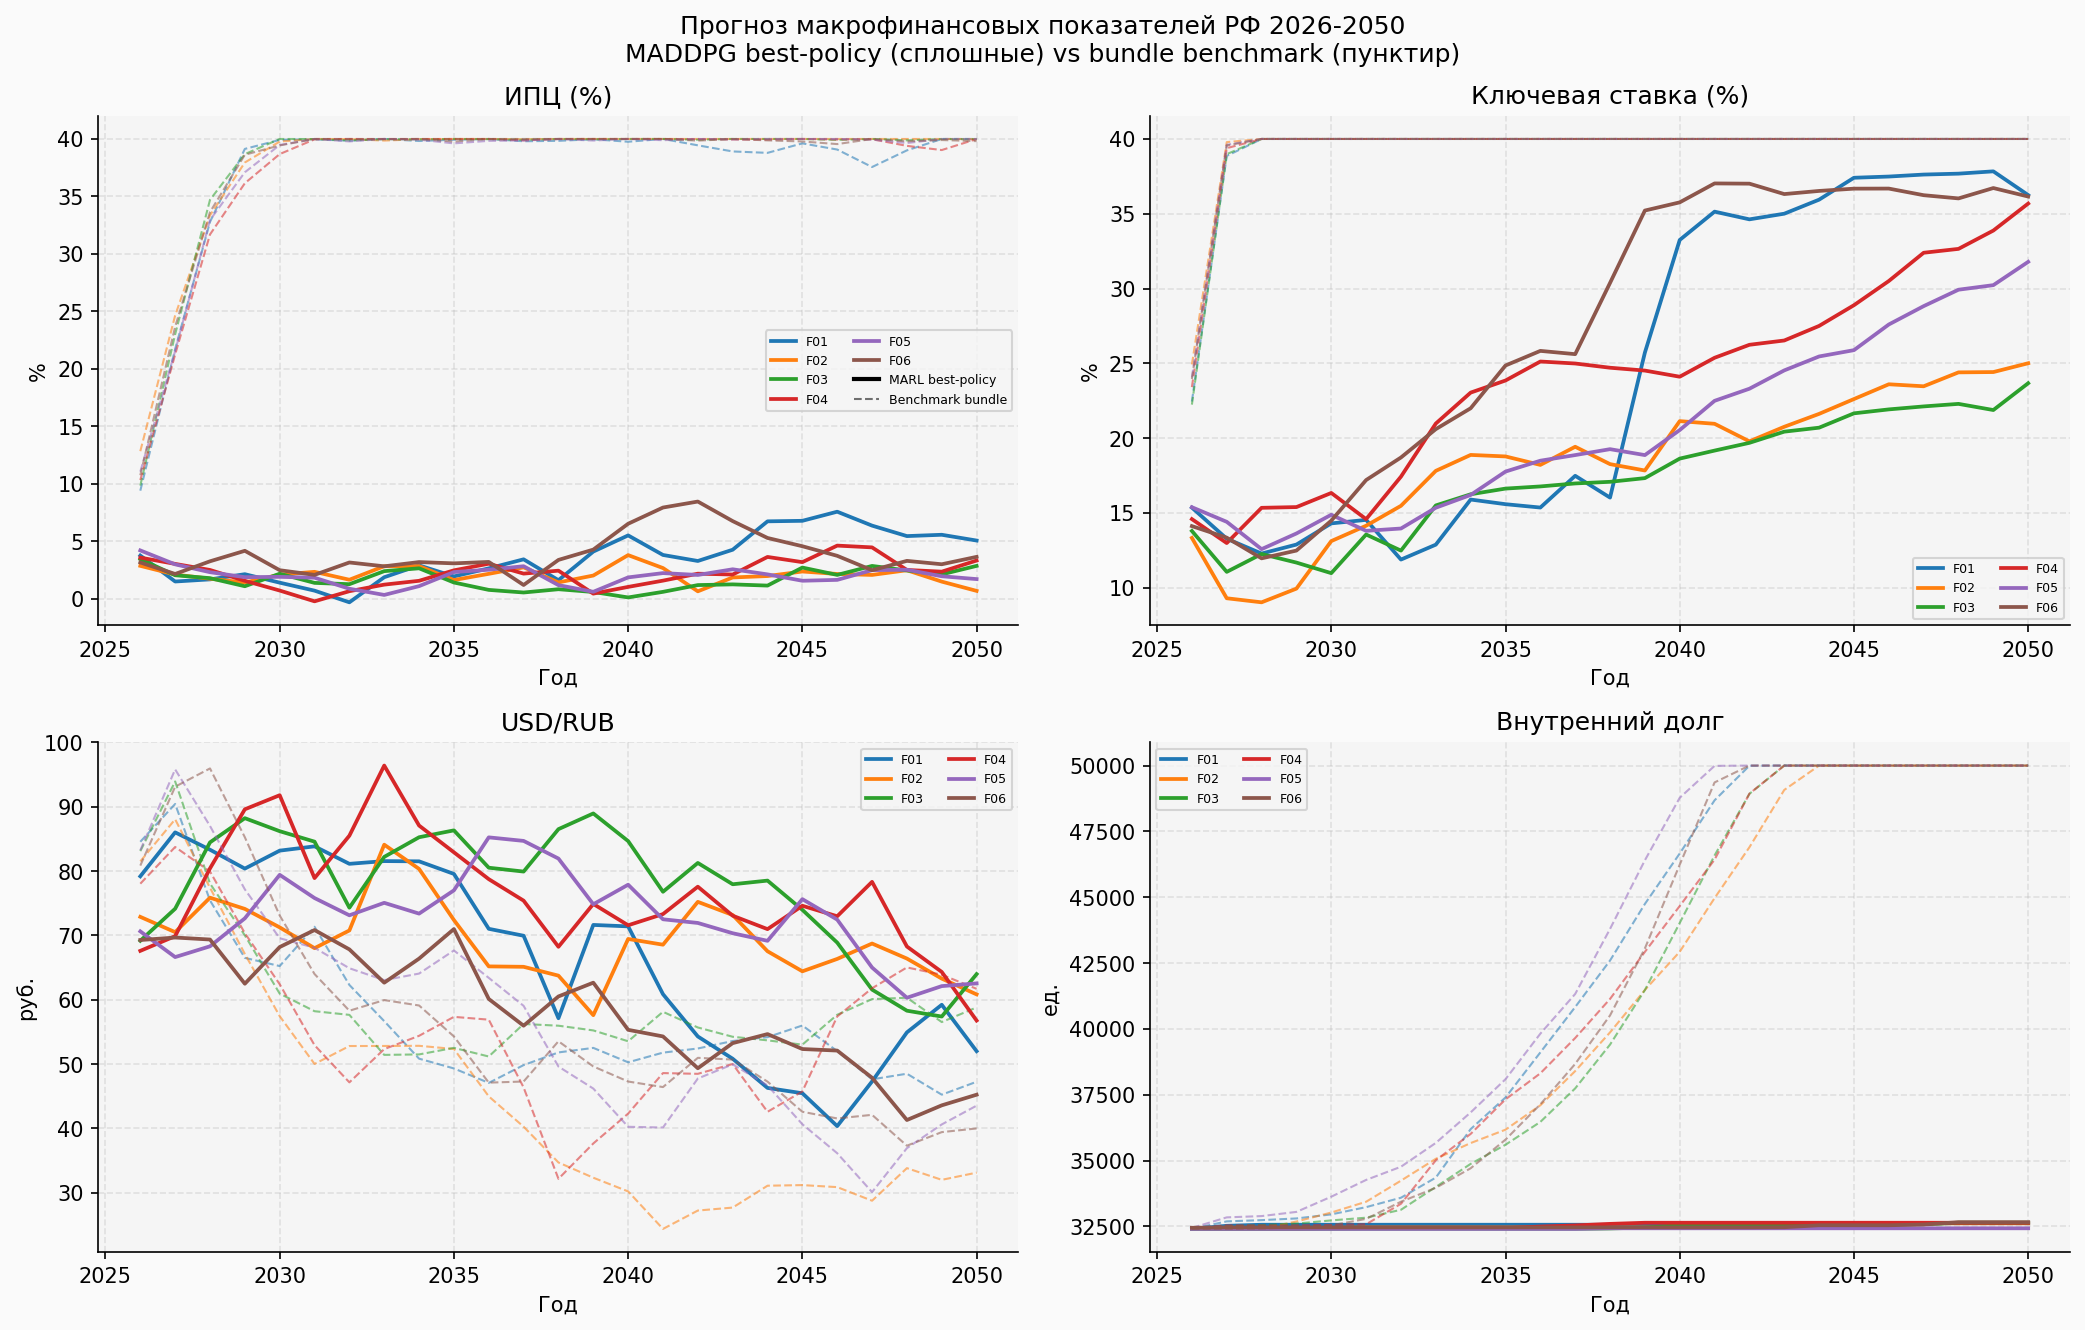

OK /content/output/forecast_2026_2050.png


In [21]:
# =========================================================
# Раздел 21. Прогон сценариев, прогноз 2026-2050 и эталонное сравнение
# Улучшенная версия: best-policy rollout, bundle benchmark,
# summary по сценариям и окнам, без ломки основных артефактов
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ---- Утилиты траекторий внешних переменных -------------------------------
def oil_path_values(tag: str, n_months: int) -> np.ndarray:
    base_map = {
        'flat_70': 70.0, 'flat_60': 60.0, 'flat_65': 65.0, 'flat_68': 68.0,
        'rising_85': 85.0, 'rising_80': 80.0, 'rising_120': 120.0,
        'declining_45': 45.0, 'declining_55': 55.0, 'declining_30': 30.0,
        'declining_50': 50.0, 'gradual_decline_60': 60.0,
        'volatile_80': 80.0,
    }
    start = 75.0
    end = base_map.get(tag, 70.0)
    if 'volatile' in tag:
        rng = np.random.RandomState(42)
        path = np.linspace(start, end, n_months) + rng.normal(0, 8, n_months)
    else:
        path = np.linspace(start, end, n_months)
    return path.clip(10, 200).astype(np.float64)


def sanction_path_values(tag: str, n_months: int) -> np.ndarray:
    val_map = {
        'stable_0.9': 0.9, 'stable_0.88': 0.88, 'stable_0.85': 0.85,
        'escalating_0.99': 0.99, 'escalating_0.97': 0.97, 'escalating_0.95': 0.95,
        'escalating_0.96': 0.96, 'escalating_0.98': 0.98,
        'declining_0.5': 0.5, 'declining_0.4': 0.4,
        'partial_0.7': 0.7, 'partial_0.75': 0.75, 'partial_0.8': 0.8,
        'high_stable': 0.95,
    }
    start = 0.92
    end = val_map.get(tag, 0.9)
    return np.linspace(start, end, n_months).clip(0, 1)


# ---- Bundle benchmark: ЦБ + Минфин + пассивные прочие агенты -------------
def benchmark_policy_actions(real_s: dict, oil_t: float, sanc_t: float):
    cpi = float(real_s.get('inflation_cpi', 7.0))
    kr = float(real_s.get('key_rate', 16.0))
    usd = float(real_s.get('usd_rub', 90.0))
    balance = float(real_s.get('budget_balance', -2.0))
    debt = float(real_s.get('domestic_debt', 20.0))
    ipi = float(real_s.get('ind_production', 100.0))

    cb_specs = ACTION_SPACE.get('CentralBank', [])
    mf_specs = ACTION_SPACE.get('MinFin', [])
    fns_specs = ACTION_SPACE.get('FNS', [])
    fas_specs = ACTION_SPACE.get('FAS', [])
    mer_specs = ACTION_SPACE.get('MER', [])
    bank_specs = ACTION_SPACE.get('Banks', [])
    rs_specs = ACTION_SPACE.get('RealSector', [])

    def _clip(v, lo, hi):
        return float(np.clip(v, lo, hi))

    d_key_rate = 0.35 * (cpi - 4.0) + 0.03 * max(0.0, usd - 95.0) + 0.8 * max(0.0, sanc_t - 0.9)
    fx_interv = -0.35 * max(0.0, usd - 100.0) / 100.0 + 0.10 * max(0.0, oil_t - 75.0) / 75.0

    d_budget = 0.25 * max(0.0, -balance) - 0.12 * max(0.0, debt - 25.0) / 25.0 + 0.10 * max(0.0, oil_t - 70.0) / 70.0
    tax_admin = 0.55 + 0.20 * max(0.0, -balance) / 5.0
    tariffs = 0.04 + 0.06 * max(0.0, cpi - 4.0) / 10.0
    invest_stim = 0.35 + 0.25 * max(0.0, 102.0 - ipi) / 20.0
    loan_spread = 0.03 + 0.02 * max(0.0, cpi - 4.0) / 10.0 + 0.01 * sanc_t
    credit_vol = 0.45 - 0.15 * max(0.0, kr - 12.0) / 12.0 + 0.10 * max(0.0, oil_t - 70.0) / 70.0
    markup = 0.10 + 0.08 * max(0.0, cpi - 4.0) / 10.0
    savings = 0.18 + 0.08 * max(0.0, usd - 95.0) / 100.0

    actions = {
        'CentralBank': [
            _clip(d_key_rate, cb_specs[0].low, cb_specs[0].high) if len(cb_specs) > 0 else d_key_rate,
            _clip(fx_interv, cb_specs[1].low, cb_specs[1].high) if len(cb_specs) > 1 else fx_interv,
        ],
        'MinFin': [
            _clip(d_budget, mf_specs[0].low, mf_specs[0].high) if len(mf_specs) > 0 else d_budget
        ],
        'FNS': [
            _clip(tax_admin, fns_specs[0].low, fns_specs[0].high) if len(fns_specs) > 0 else tax_admin
        ],
        'FAS': [
            _clip(tariffs, fas_specs[0].low, fas_specs[0].high) if len(fas_specs) > 0 else tariffs
        ],
        'MER': [
            _clip(invest_stim, mer_specs[0].low, mer_specs[0].high) if len(mer_specs) > 0 else invest_stim
        ],
        'Banks': [
            _clip(loan_spread, bank_specs[0].low, bank_specs[0].high) if len(bank_specs) > 0 else loan_spread,
            _clip(credit_vol, bank_specs[1].low, bank_specs[1].high) if len(bank_specs) > 1 else credit_vol,
        ],
        'RealSector': [
            _clip(markup, rs_specs[0].low, rs_specs[0].high) if len(rs_specs) > 0 else markup,
            _clip(savings, rs_specs[1].low, rs_specs[1].high) if len(rs_specs) > 1 else savings,
        ],
    }
    return actions


# ---- Настройки прогноза --------------------------------------------------
START_FORECAST = pd.Timestamp('2026-01-01')
MONTHS_2026_2050 = (2050 - 2026 + 1) * 12

forecast_records = []
policy_records = []
scenario_summary_records = []
horizon_summary_records = []

print(f'Прогон {len(FUTURE_SCENARIOS)} сценариев x {MONTHS_2026_2050} мес. (best-policy MARL + benchmark bundle)...')

for sc in FUTURE_SCENARIOS:
    n_months = MONTHS_2026_2050
    oil_vals = oil_path_values(sc.get('oil_path', 'flat_70'), n_months + 1)
    sanc_vals = sanction_path_values(sc.get('sanction_path', 'stable_0.9'), n_months)

    env_scenario = {
        'oil_path': oil_vals.tolist(),
        'sanction_intensity': float(sanc_vals.mean()),
    }

    env.horizon = n_months

    # --- MARL rollout (best restored policy) ---
    obs_dict, global_s = env.reset(env_scenario)
    marl_rows = []
    agent_acts_log = {a: [] for a in AGENTS}
    marl_total_rewards = []

    for t in range(n_months):
        raw_actions = {
            a: maddpg.agents[a].act(obs_dict.get(a, global_s), explore=False)
            for a in maddpg.agents_ids
        }
        scaled_actions = {
            a: maddpg._scale_actions(a, raw_actions[a])
            for a in maddpg.agents_ids
        }

        for a in AGENTS:
            agent_acts_log[a].append(np.asarray(raw_actions.get(a, np.zeros(maddpg.act_dims.get(a, 1))), dtype=np.float32))

        next_obs, next_gs, rewards, done = env.step(scaled_actions)
        real_s = env.current_real_state()
        marl_total_rewards.append(float(sum(rewards.get(a, 0.0) for a in AGENTS)))

        marl_rows.append({
            't': t,
            'cpi_pct': float(real_s.get('inflation_cpi', np.nan)),
            'key_rate_pct': float(real_s.get('key_rate', np.nan)),
            'usd_rub': float(real_s.get('usd_rub', np.nan)),
            'budget_balance': float(real_s.get('budget_balance', np.nan)),
            'domestic_debt': float(real_s.get('domestic_debt', np.nan)),
            'ind_production': float(real_s.get('ind_production', np.nan)),
            'oil_price': float(oil_vals[t]),
            'sanction_level': float(sanc_vals[t]),
            'marl_reward_total': float(marl_total_rewards[-1]),
            **{f'r_{a}': float(rewards.get(a, 0.0)) for a in AGENTS}
        })

        obs_dict, global_s = next_obs, next_gs

        if done:
            last = marl_rows[-1].copy()
            while len(marl_rows) < n_months:
                t_pad = len(marl_rows)
                pad = last.copy()
                pad['t'] = t_pad
                pad['oil_price'] = float(oil_vals[min(t_pad, len(oil_vals)-1)])
                pad['sanction_level'] = float(sanc_vals[min(t_pad, len(sanc_vals)-1)])
                marl_rows.append(pad)
                marl_total_rewards.append(float(last['marl_reward_total']))
                for a in AGENTS:
                    agent_acts_log[a].append(agent_acts_log[a][-1])
            break

    marl_df_sc = pd.DataFrame(marl_rows)

    # --- Benchmark rollout в той же среде ---
    obs_b, gs_b = env.reset(env_scenario)
    bench_rows = []

    for t in range(n_months):
        real_b = env.current_real_state()
        benchmark_actions = benchmark_policy_actions(real_b, oil_vals[t], sanc_vals[t])
        next_obs_b, next_gs_b, rewards_b, done_b = env.step(benchmark_actions)
        real_b2 = env.current_real_state()

        bench_rows.append({
            't': t,
            'bench_cpi_pct': float(real_b2.get('inflation_cpi', np.nan)),
            'bench_key_rate_pct': float(real_b2.get('key_rate', np.nan)),
            'bench_usd_rub': float(real_b2.get('usd_rub', np.nan)),
            'bench_budget_balance': float(real_b2.get('budget_balance', np.nan)),
            'bench_domestic_debt': float(real_b2.get('domestic_debt', np.nan)),
            'bench_ind_production': float(real_b2.get('ind_production', np.nan)),
            'bench_reward_total': float(sum(rewards_b.get(a, 0.0) for a in AGENTS)),
        })

        obs_b, gs_b = next_obs_b, next_gs_b
        if done_b:
            last = bench_rows[-1].copy()
            while len(bench_rows) < n_months:
                t_pad = len(bench_rows)
                pad = last.copy()
                pad['t'] = t_pad
                bench_rows.append(pad)
            break

    bench_df_sc = pd.DataFrame(bench_rows)
    merged_sc = marl_df_sc.merge(bench_df_sc, on='t', how='left')

    # --- Запись прогноза ---
    def _bucket(year):
        if year <= 2030:
            return '2026-2030'
        elif year <= 2040:
            return '2031-2040'
        else:
            return '2041-2050'

    for t in range(n_months):
        date = START_FORECAST + pd.DateOffset(months=t)
        row = merged_sc.iloc[t]
        forecast_records.append({
            'scenario_id': sc['id'],
            'scenario_name': sc['name'],
            'date': date,
            'year': date.year,
            'month': date.month,
            'horizon_bucket': _bucket(date.year),
            'cpi_pct': round(float(row['cpi_pct']), 2),
            'key_rate_pct': round(float(row['key_rate_pct']), 2),
            'usd_rub': round(float(row['usd_rub']), 2),
            'budget_balance': round(float(row['budget_balance']), 2),
            'domestic_debt': round(float(row['domestic_debt']), 2),
            'ind_production': round(float(row['ind_production']), 2),
            'oil_price': round(float(row['oil_price']), 2),
            'sanction_level': round(float(row['sanction_level']), 3),
            'source': 'MARL',
            'policy_source': 'MADDPG_best',
            'benchmark_cpi_pct': round(float(row['bench_cpi_pct']), 2),
            'benchmark_key_rate_pct': round(float(row['bench_key_rate_pct']), 2),
            'benchmark_usd_rub': round(float(row['bench_usd_rub']), 2),
            'benchmark_budget_balance': round(float(row['bench_budget_balance']), 2),
            'benchmark_domestic_debt': round(float(row['bench_domestic_debt']), 2),
            'benchmark_ind_production': round(float(row['bench_ind_production']), 2),
            'marl_reward_total': round(float(row['marl_reward_total']), 4),
            'benchmark_reward_total': round(float(row['bench_reward_total']), 4),
        })

    # --- Оптимальные политики ---
    cb_acts = agent_acts_log.get('CentralBank', [])
    mf_acts = agent_acts_log.get('MinFin', [])
    fns_acts = agent_acts_log.get('FNS', [])
    fas_acts = agent_acts_log.get('FAS', [])
    mer_acts = agent_acts_log.get('MER', [])
    bnk_acts = agent_acts_log.get('Banks', [])
    rs_acts = agent_acts_log.get('RealSector', [])

    def _a(lst, t_, j=0):
        return float(lst[t_][j]) if t_ < len(lst) and len(np.asarray(lst[t_]).ravel()) > j else 0.0

    for t in range(n_months):
        date = START_FORECAST + pd.DateOffset(months=t)
        row = merged_sc.iloc[t]
        policy_records.append({
            'scenario_id': sc['id'],
            'scenario_name': sc['name'],
            'date': date,
            'year': date.year,
            'horizon_bucket': _bucket(date.year),
            'cb_delta_key_rate': round(_a(cb_acts, t, 0), 4),
            'cb_fx_interventions': round(_a(cb_acts, t, 1), 4),
            'minfin_delta_spend': round(_a(mf_acts, t, 0), 4),
            'fns_tax_strictness': round(_a(fns_acts, t, 0), 4),
            'fas_tariffs_indexation': round(_a(fas_acts, t, 0), 4),
            'mer_investment_stimulus': round(_a(mer_acts, t, 0), 4),
            'banks_loan_spread': round(_a(bnk_acts, t, 0), 4),
            'banks_credit_volume': round(_a(bnk_acts, t, 1), 4),
            'realsector_price_markup': round(_a(rs_acts, t, 0), 4),
            'realsector_savings_rate': round(_a(rs_acts, t, 1), 4),
            'marl_cpi_pct': round(float(row['cpi_pct']), 2),
            'marl_budget_balance': round(float(row['budget_balance']), 2),
            'marl_domestic_debt': round(float(row['domestic_debt']), 2),
            'marl_reward_total': round(float(row['marl_reward_total']), 4),
        })

    # --- Summary по сценарию ---
    scenario_summary_records.append({
        'scenario_id': sc['id'],
        'scenario_name': sc['name'],
        'avg_cpi_marl': round(float(merged_sc['cpi_pct'].mean()), 3),
        'avg_cpi_benchmark': round(float(merged_sc['bench_cpi_pct'].mean()), 3),
        'avg_key_rate_marl': round(float(merged_sc['key_rate_pct'].mean()), 3),
        'avg_key_rate_benchmark': round(float(merged_sc['bench_key_rate_pct'].mean()), 3),
        'avg_usd_marl': round(float(merged_sc['usd_rub'].mean()), 3),
        'avg_usd_benchmark': round(float(merged_sc['bench_usd_rub'].mean()), 3),
        'final_debt_marl': round(float(merged_sc['domestic_debt'].iloc[-1]), 3),
        'final_debt_benchmark': round(float(merged_sc['bench_domestic_debt'].iloc[-1]), 3),
        'avg_budget_balance_marl': round(float(merged_sc['budget_balance'].mean()), 3),
        'avg_budget_balance_benchmark': round(float(merged_sc['bench_budget_balance'].mean()), 3),
        'cum_reward_marl': round(float(merged_sc['marl_reward_total'].sum()), 3),
        'cum_reward_benchmark': round(float(merged_sc['bench_reward_total'].sum()), 3),
        'reward_gap_marl_minus_benchmark': round(float(merged_sc['marl_reward_total'].sum() - merged_sc['bench_reward_total'].sum()), 3),
        'max_usd_marl': round(float(merged_sc['usd_rub'].max()), 3),
        'max_usd_benchmark': round(float(merged_sc['bench_usd_rub'].max()), 3),
    })

    tmp_sc = pd.DataFrame(forecast_records)
    tmp_sc = tmp_sc[tmp_sc['scenario_id'] == sc['id']]
    for bucket, sub in tmp_sc.groupby('horizon_bucket'):
        horizon_summary_records.append({
            'scenario_id': sc['id'],
            'scenario_name': sc['name'],
            'horizon_bucket': bucket,
            'avg_cpi_marl': round(float(sub['cpi_pct'].mean()), 3),
            'avg_cpi_benchmark': round(float(sub['benchmark_cpi_pct'].mean()), 3),
            'avg_key_rate_marl': round(float(sub['key_rate_pct'].mean()), 3),
            'avg_key_rate_benchmark': round(float(sub['benchmark_key_rate_pct'].mean()), 3),
            'avg_usd_marl': round(float(sub['usd_rub'].mean()), 3),
            'avg_usd_benchmark': round(float(sub['benchmark_usd_rub'].mean()), 3),
            'avg_debt_marl': round(float(sub['domestic_debt'].mean()), 3),
            'avg_debt_benchmark': round(float(sub['benchmark_domestic_debt'].mean()), 3),
            'cum_reward_marl': round(float(sub['marl_reward_total'].sum()), 3),
            'cum_reward_benchmark': round(float(sub['benchmark_reward_total'].sum()), 3),
        })

    print(
        f'  {sc["id"]}: '
        f'MARL avg_CPI={float(merged_sc["cpi_pct"].mean()):.2f}% | '
        f'avg_KR={float(merged_sc["key_rate_pct"].mean()):.2f}% | '
        f'avg_USD={float(merged_sc["usd_rub"].mean()):.1f} | '
        f'reward_gap={float(merged_sc["marl_reward_total"].sum() - merged_sc["bench_reward_total"].sum()):.1f}'
    )


# --- Сохранение CSV ---
forecast_df = pd.DataFrame(forecast_records)
policy_df = pd.DataFrame(policy_records)
scenario_summary_df = pd.DataFrame(scenario_summary_records)
horizon_summary_df = pd.DataFrame(horizon_summary_records)

fname_fc = os.path.join(OUT_DIR, 'forecast_2026_2050.csv')
fname_pol = os.path.join(OUT_DIR, 'optimal_policies.csv')
fname_sc_sum = os.path.join(OUT_DIR, 'forecast_summary_by_scenario.csv')
fname_h_sum = os.path.join(OUT_DIR, 'forecast_summary_by_horizon.csv')

forecast_df.to_csv(fname_fc, index=False, encoding='utf-8-sig')
policy_df.to_csv(fname_pol, index=False, encoding='utf-8-sig')
scenario_summary_df.to_csv(fname_sc_sum, index=False, encoding='utf-8-sig')
horizon_summary_df.to_csv(fname_h_sum, index=False, encoding='utf-8-sig')

print(f'OK forecast_2026_2050.csv: {len(forecast_df)} строк')
print(f'OK optimal_policies.csv: {len(policy_df)} строк')
print(f'OK forecast_summary_by_scenario.csv: {len(scenario_summary_df)} строк')
print(f'OK forecast_summary_by_horizon.csv: {len(horizon_summary_df)} строк')


# --- Визуализация: MARL vs benchmark -------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Прогноз макрофинансовых показателей РФ 2026-2050\n'
    'MADDPG best-policy (сплошные) vs bundle benchmark (пунктир)',
    fontsize=12
)

sel_ids = [sc['id'] for sc in FUTURE_SCENARIOS[:6]]
annual = forecast_df.groupby(['scenario_id', 'year']).mean(numeric_only=True).reset_index()
colors = plt.cm.tab10.colors

for ci, sc_id in enumerate(sel_ids):
    sub = annual[annual['scenario_id'] == sc_id]
    clr = colors[ci % len(colors)]

    axes[0, 0].plot(sub['year'], sub['cpi_pct'], lw=1.8, color=clr, label=sc_id)
    axes[0, 0].plot(sub['year'], sub['benchmark_cpi_pct'], lw=1.0, color=clr, ls='--', alpha=0.55)

    axes[0, 1].plot(sub['year'], sub['key_rate_pct'], lw=1.8, color=clr, label=sc_id)
    axes[0, 1].plot(sub['year'], sub['benchmark_key_rate_pct'], lw=1.0, color=clr, ls='--', alpha=0.55)

    axes[1, 0].plot(sub['year'], sub['usd_rub'], lw=1.8, color=clr, label=sc_id)
    axes[1, 0].plot(sub['year'], sub['benchmark_usd_rub'], lw=1.0, color=clr, ls='--', alpha=0.55)

    axes[1, 1].plot(sub['year'], sub['domestic_debt'], lw=1.8, color=clr, label=sc_id)
    axes[1, 1].plot(sub['year'], sub['benchmark_domestic_debt'], lw=1.0, color=clr, ls='--', alpha=0.55)

for ax, title, ylabel in zip(
    axes.flat,
    ['ИПЦ (%)', 'Ключевая ставка (%)', 'USD/RUB', 'Внутренний долг'],
    ['%', '%', 'руб.', 'ед.']
):
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Год')
    ax.grid(alpha=0.3)
    ax.legend(fontsize=6, ncol=2)

axes[0, 0].plot([], [], 'k-', lw=2, label='MARL best-policy')
axes[0, 0].plot([], [], 'k--', lw=1, label='Benchmark bundle', alpha=0.55)
axes[0, 0].legend(fontsize=6, ncol=2)

plt.tight_layout()
fname_fc_plot = os.path.join(OUT_DIR, 'forecast_2026_2050.png')
plt.savefig(fname_fc_plot, bbox_inches='tight', dpi=150)
plt.show()
print(f'OK {fname_fc_plot}')

---
## Раздел 22. Тест Грейнджера на причинность и факторный анализ

Тест Грейнджера (Granger causality) позволяет проверить, предсказывает ли временной ряд X будущие значения ряда Y. Проводится попарно для ключевых переменных: нефть, ключевая ставка, USD/RUB, ИПЦ, бюджетный баланс, долг. Дополнительно рассчитывается **факторная важность** через корреляцию государственных переменных с суммарной наградой MADDPG.  
Артефакт: `output/granger_causality.csv`.


Источник для Granger: forecast_2026_2050.csv (6300 строк)
Дополнительно найден master_monthly.csv (180 строк)
OK granger_causality.csv
                dataset               description  f_stat  p_value  best_lag  reject_h0                conclusion
forecast_2026_2050_marl Нефть -> Бюджетный баланс  4.3950 0.036895         1       True           X -> Y (p<0.05)
forecast_2026_2050_marl          Нефть -> USD/RUB  2.1235 0.077999         4      False Нет причинности (p>=0.05)
forecast_2026_2050_marl            USD/RUB -> ИПЦ 41.1927 0.000000         2       True           X -> Y (p<0.05)
forecast_2026_2050_marl    Ключевая ставка -> ИПЦ 13.4207 0.000003         2       True           X -> Y (p<0.05)
forecast_2026_2050_marl    ИПЦ -> Ключевая ставка 67.4397 0.000000         4       True           X -> Y (p<0.05)
forecast_2026_2050_marl Баланс бюджета -> Госдолг  4.1913 0.016047         2       True           X -> Y (p<0.05)
forecast_2026_2050_marl  Нефть -> Индпроизводство  1.1491 0.334049 

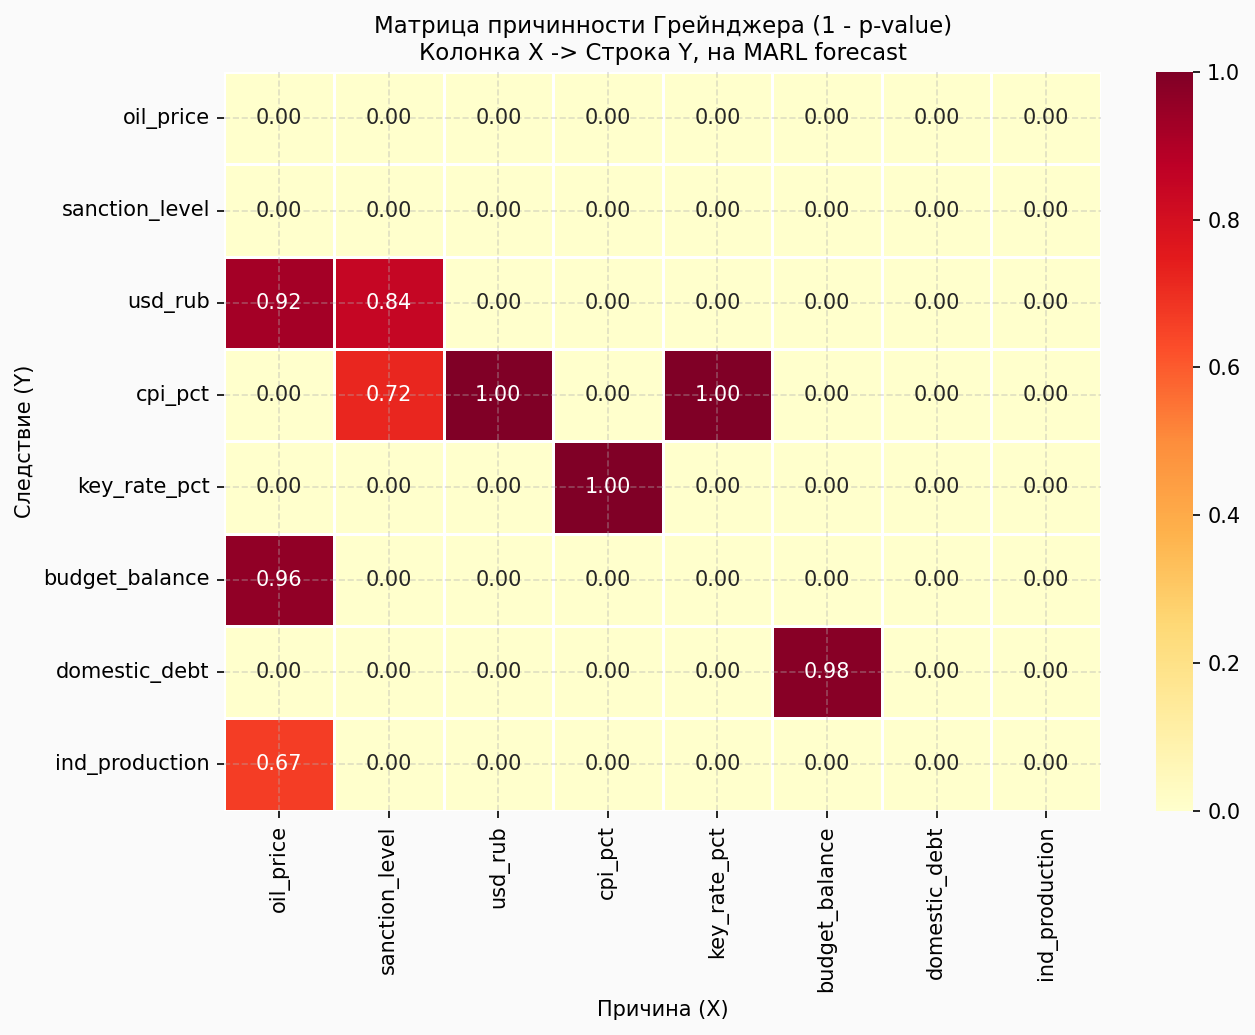

OK /content/output/granger_causality_matrix.png
OK /content/output/factor_importance_marl.csv
      variable  pearson_corr_with_reward  perm_importance_r2_drop
ind_production                  0.754376                 0.141088
       cpi_pct                 -0.664887                 0.003157
  key_rate_pct                 -0.289211                 0.032579
budget_balance                 -0.240995                 0.127705
sanction_level                  0.101910                -0.000006
       usd_rub                  0.098823                 0.001068
 domestic_debt                 -0.073379                 0.000191
     oil_price                 -0.012354                -0.000040

--- Импульсные функции отклика (упрощённые OLS, MARL forecast) ---
                             effect     y_variable     x_variable  coefficient
               Ответ ИПЦ на КС +1pp        cpi_pct   key_rate_pct     0.070591
        Ответ USD/RUB на нефть -10$        usd_rub      oil_price     2.598865
Ответ б

In [22]:
# =========================================================
# Раздел 22. Тест Грейнджера на причинность и факторный анализ
# Улучшенная версия: stationarity check, дифференцирование,
# MARL-aware факторный анализ, совместимые артефакты
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

try:
    from scipy import stats
except Exception:
    stats = None

try:
    from statsmodels.tsa.stattools import adfuller
except Exception:
    adfuller = None


# ---- Вспомогательные функции --------------------------------------------
def ensure_stationary(series: pd.Series, name: str = '', max_diff: int = 2):
    s = pd.Series(series).astype(float).replace([np.inf, -np.inf], np.nan).dropna()
    if len(s) < 20:
        return s, 0, np.nan, False, 'short_series'

    if adfuller is None:
        s2 = s.diff().dropna()
        return s2, 1, np.nan, True, 'adf_unavailable_diff1'

    for d in range(max_diff + 1):
        sd = s.copy() if d == 0 else s.diff(d).dropna()
        sd = sd.dropna()
        if len(sd) < 20:
            continue
        try:
            adf_res = adfuller(sd, autolag='AIC')
            pval = float(adf_res[1])
            if pval < 0.05:
                return sd, d, pval, True, 'stationary'
        except Exception:
            pass

    sd = s.diff().dropna()
    return sd, 1, np.nan, False, 'fallback_diff1'


def granger_test_ols(y: pd.Series, x: pd.Series, max_lag: int = 6) -> dict:
    df = pd.DataFrame({'y': y, 'x': x}).replace([np.inf, -np.inf], np.nan).dropna()
    n = len(df)
    if n < max_lag * 3 + 10 or stats is None:
        return {
            'f_stat': np.nan, 'p_value': np.nan, 'best_lag': np.nan,
            'reject_h0': False, 'n_obs': n
        }

    results = []
    for lag in range(1, max_lag + 1):
        data = {'y_t': df['y'].values[lag:]}
        for k in range(1, lag + 1):
            data[f'y_lag{k}'] = df['y'].values[lag-k:n-k]
            data[f'x_lag{k}'] = df['x'].values[lag-k:n-k]

        T = len(data['y_t'])
        if T <= 2 * lag + 5:
            continue

        Xr = np.column_stack([np.ones(T)] + [data[f'y_lag{k}'] for k in range(1, lag + 1)])
        Xu = np.column_stack(
            [np.ones(T)]
            + [data[f'y_lag{k}'] for k in range(1, lag + 1)]
            + [data[f'x_lag{k}'] for k in range(1, lag + 1)]
        )
        yv = data['y_t']

        beta_r, _, _, _ = lstsq(Xr, yv, rcond=None)
        beta_u, _, _, _ = lstsq(Xu, yv, rcond=None)
        rss_r = float(np.sum((yv - Xr @ beta_r) ** 2))
        rss_u = float(np.sum((yv - Xu @ beta_u) ** 2))

        df_num = lag
        df_den = T - 2 * lag - 1
        if df_den <= 0 or rss_u <= 1e-12 or rss_r < rss_u:
            continue

        f_stat = ((rss_r - rss_u) / df_num) / (rss_u / df_den)
        p_val = float(1 - stats.f.cdf(f_stat, df_num, df_den))

        aic_u = T * np.log(max(rss_u / T, 1e-12)) + 2 * Xu.shape[1]
        bic_u = T * np.log(max(rss_u / T, 1e-12)) + np.log(T) * Xu.shape[1]

        results.append({
            'lag': lag,
            'f_stat': f_stat,
            'p_value': p_val,
            'aic': aic_u,
            'bic': bic_u,
            'n_obs': T
        })

    if not results:
        return {
            'f_stat': np.nan, 'p_value': np.nan, 'best_lag': np.nan,
            'reject_h0': False, 'n_obs': n
        }

    valid = [r for r in results if np.isfinite(r['p_value'])]
    if not valid:
        return {
            'f_stat': np.nan, 'p_value': np.nan, 'best_lag': np.nan,
            'reject_h0': False, 'n_obs': n
        }

    best = min(valid, key=lambda r: (r['p_value'], r['bic']))
    return {
        'f_stat': round(float(best['f_stat']), 4),
        'p_value': round(float(best['p_value']), 6),
        'best_lag': int(best['lag']),
        'reject_h0': bool(best['p_value'] < 0.05),
        'n_obs': int(best['n_obs'])
    }


# ---- Источник данных: forecast_2026_2050 + optional master ---------------
forecast_path = os.path.join(OUT_DIR, 'forecast_2026_2050.csv')
master_path = os.path.join(OUT_DIR, 'master_monthly.csv')

forecast_data = pd.read_csv(forecast_path, parse_dates=['date']) if os.path.exists(forecast_path) else None
master = pd.read_csv(master_path, index_col=0, parse_dates=True) if os.path.exists(master_path) else None

if forecast_data is None:
    raise FileNotFoundError('forecast_2026_2050.csv не найден. Сначала выполните раздел 21.')

print(f'Источник для Granger: forecast_2026_2050.csv ({len(forecast_data)} строк)')
if master is not None:
    print(f'Дополнительно найден master_monthly.csv ({len(master)} строк)')


# ---- Granger на MARL forecast: по среднему профилю сценариев -------------
annual_monthly = (
    forecast_data.groupby('date')[[
        'oil_price', 'sanction_level', 'cpi_pct', 'key_rate_pct',
        'usd_rub', 'budget_balance', 'domestic_debt', 'ind_production'
    ]]
    .mean()
    .sort_index()
)

granger_pairs = [
    ('budget_balance', 'oil_price', 'Нефть -> Бюджетный баланс'),
    ('usd_rub', 'oil_price', 'Нефть -> USD/RUB'),
    ('cpi_pct', 'usd_rub', 'USD/RUB -> ИПЦ'),
    ('cpi_pct', 'key_rate_pct', 'Ключевая ставка -> ИПЦ'),
    ('key_rate_pct', 'cpi_pct', 'ИПЦ -> Ключевая ставка'),
    ('domestic_debt', 'budget_balance', 'Баланс бюджета -> Госдолг'),
    ('ind_production', 'oil_price', 'Нефть -> Индпроизводство'),
    ('usd_rub', 'sanction_level', 'Санкции -> USD/RUB'),
    ('cpi_pct', 'sanction_level', 'Санкции -> ИПЦ'),
]

granger_results = []
for y_col, x_col, desc in granger_pairs:
    if y_col not in annual_monthly.columns or x_col not in annual_monthly.columns:
        continue

    y_raw = annual_monthly[y_col]
    x_raw = annual_monthly[x_col]

    y_s, y_diff_order, y_adf_p, y_stationary, y_note = ensure_stationary(y_raw, y_col)
    x_s, x_diff_order, x_adf_p, x_stationary, x_note = ensure_stationary(x_raw, x_col)

    common_idx = y_s.index.intersection(x_s.index)
    y_s = y_s.loc[common_idx]
    x_s = x_s.loc[common_idx]

    res = granger_test_ols(y_s, x_s, max_lag=6)

    granger_results.append({
        'dataset': 'forecast_2026_2050_marl',
        'y_variable': y_col,
        'x_variable': x_col,
        'description': desc,
        'y_diff_order': y_diff_order,
        'x_diff_order': x_diff_order,
        'y_adf_pvalue': round(float(y_adf_p), 6) if pd.notna(y_adf_p) else np.nan,
        'x_adf_pvalue': round(float(x_adf_p), 6) if pd.notna(x_adf_p) else np.nan,
        'f_stat': res['f_stat'],
        'p_value': res['p_value'],
        'best_lag': res['best_lag'],
        'n_obs': res['n_obs'],
        'reject_h0': res['reject_h0'],
        'conclusion': 'X -> Y (p<0.05)' if res['reject_h0'] else 'Нет причинности (p>=0.05)',
    })


# ---- При наличии master_monthly: отдельный блок -------------------------
if master is not None:
    master_map = {
        'oil_price': 'oil_rub',
        'budget_balance': 'balance',
        'usd_rub': 'usd_rub',
        'cpi_pct': 'cpi_mom',
        'key_rate_pct': 'key_rate',
        'domestic_debt': 'debt_total',
        'ind_production': 'ipi_yoy',
        'sanction_level': None,
    }

    hist_pairs = [
        ('budget_balance', 'oil_price', 'История: Нефть -> Бюджетный баланс'),
        ('usd_rub', 'oil_price', 'История: Нефть -> USD/RUB'),
        ('cpi_pct', 'usd_rub', 'История: USD/RUB -> ИПЦ'),
        ('cpi_pct', 'key_rate_pct', 'История: Ключевая ставка -> ИПЦ'),
        ('key_rate_pct', 'cpi_pct', 'История: ИПЦ -> Ключевая ставка'),
        ('domestic_debt', 'budget_balance', 'История: Баланс бюджета -> Госдолг'),
        ('ind_production', 'oil_price', 'История: Нефть -> Индпроизводство'),
    ]

    for y_var, x_var, desc in hist_pairs:
        y_col = master_map.get(y_var)
        x_col = master_map.get(x_var)
        if y_col is None or x_col is None or y_col not in master.columns or x_col not in master.columns:
            continue

        y_raw = master[y_col].dropna()
        x_raw = master[x_col].dropna()
        common_idx = y_raw.index.intersection(x_raw.index)
        y_raw, x_raw = y_raw.loc[common_idx], x_raw.loc[common_idx]

        y_s, y_diff_order, y_adf_p, y_stationary, y_note = ensure_stationary(y_raw, y_col)
        x_s, x_diff_order, x_adf_p, x_stationary, x_note = ensure_stationary(x_raw, x_col)

        common_idx2 = y_s.index.intersection(x_s.index)
        y_s = y_s.loc[common_idx2]
        x_s = x_s.loc[common_idx2]

        res = granger_test_ols(y_s, x_s, max_lag=6)
        granger_results.append({
            'dataset': 'master_monthly_history',
            'y_variable': y_var,
            'x_variable': x_var,
            'description': desc,
            'y_diff_order': y_diff_order,
            'x_diff_order': x_diff_order,
            'y_adf_pvalue': round(float(y_adf_p), 6) if pd.notna(y_adf_p) else np.nan,
            'x_adf_pvalue': round(float(x_adf_p), 6) if pd.notna(x_adf_p) else np.nan,
            'f_stat': res['f_stat'],
            'p_value': res['p_value'],
            'best_lag': res['best_lag'],
            'n_obs': res['n_obs'],
            'reject_h0': res['reject_h0'],
            'conclusion': 'X -> Y (p<0.05)' if res['reject_h0'] else 'Нет причинности (p>=0.05)',
        })


granger_df = pd.DataFrame(granger_results)
fname_gr = os.path.join(OUT_DIR, 'granger_causality.csv')
granger_df.to_csv(fname_gr, index=False, encoding='utf-8-sig')
print('OK granger_causality.csv')
print(granger_df[['dataset', 'description', 'f_stat', 'p_value', 'best_lag', 'reject_h0', 'conclusion']].to_string(index=False))


# ---- Матрица причинности для forecast MARL ------------------------------
vars_list = ['oil_price', 'sanction_level', 'usd_rub', 'cpi_pct', 'key_rate_pct', 'budget_balance', 'domestic_debt', 'ind_production']
cause_matrix = pd.DataFrame(np.nan, index=vars_list, columns=vars_list)

for _, row in granger_df[granger_df['dataset'] == 'forecast_2026_2050_marl'].iterrows():
    yv = row['y_variable']
    xv = row['x_variable']
    if yv in vars_list and xv in vars_list and pd.notna(row['p_value']):
        cause_matrix.loc[yv, xv] = 1.0 - float(row['p_value'])

fig, ax = plt.subplots(figsize=(9, 7))
import seaborn as sns
sns.heatmap(
    cause_matrix.fillna(0),
    annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, ax=ax, vmin=0, vmax=1
)
ax.set_title('Матрица причинности Грейнджера (1 - p-value)\nКолонка X -> Строка Y, на MARL forecast', fontsize=11)
ax.set_xlabel('Причина (X)')
ax.set_ylabel('Следствие (Y)')
plt.tight_layout()
fname_gr_plot = os.path.join(OUT_DIR, 'granger_causality_matrix.png')
plt.savefig(fname_gr_plot, bbox_inches='tight', dpi=150)
plt.show()
print(f'OK {fname_gr_plot}')


# ---- Факторный анализ на MARL trajectories ------------------------------
factor_candidates = [
    'oil_price', 'sanction_level', 'cpi_pct', 'key_rate_pct', 'usd_rub',
    'budget_balance', 'domestic_debt', 'ind_production'
]

fa_df = forecast_data.copy()
fa_results = []
for col in factor_candidates:
    tmp = fa_df[[col, 'marl_reward_total']].replace([np.inf, -np.inf], np.nan).dropna()
    if len(tmp) < 20:
        corr = np.nan
    else:
        corr = float(tmp[col].corr(tmp['marl_reward_total']))
    fa_results.append({
        'variable': col,
        'pearson_corr_with_reward': round(corr, 6) if pd.notna(corr) else np.nan,
        'abs_corr_rank': abs(corr) if pd.notna(corr) else -1,
    })

factor_importance_df = pd.DataFrame(fa_results).sort_values('abs_corr_rank', ascending=False).drop(columns=['abs_corr_rank'])

# Простая permutation-like importance через ухудшение линейного fit R^2
perm_results = []
tmp_all = fa_df[factor_candidates + ['marl_reward_total']].replace([np.inf, -np.inf], np.nan).dropna().copy()
if len(tmp_all) >= 50:
    X = tmp_all[factor_candidates].values.astype(float)
    y = tmp_all['marl_reward_total'].values.astype(float)

    X0 = np.column_stack([np.ones(len(X)), X])
    beta0, _, _, _ = lstsq(X0, y, rcond=None)
    pred0 = X0 @ beta0
    sse0 = float(np.sum((y - pred0) ** 2))
    sst = float(np.sum((y - y.mean()) ** 2)) + 1e-12
    r2_base = 1.0 - sse0 / sst

    rng = np.random.RandomState(42)
    for j, col in enumerate(factor_candidates):
        Xp = X.copy()
        Xp[:, j] = rng.permutation(Xp[:, j])
        Xp0 = np.column_stack([np.ones(len(Xp)), Xp])
        betap, _, _, _ = lstsq(Xp0, y, rcond=None)
        predp = Xp0 @ betap
        ssep = float(np.sum((y - predp) ** 2))
        r2p = 1.0 - ssep / sst
        perm_results.append({
            'variable': col,
            'perm_importance_r2_drop': round(float(r2_base - r2p), 6)
        })

perm_df = pd.DataFrame(perm_results) if perm_results else pd.DataFrame(columns=['variable', 'perm_importance_r2_drop'])
factor_importance_df = factor_importance_df.merge(perm_df, on='variable', how='left')

fname_fi = os.path.join(OUT_DIR, 'factor_importance_marl.csv')
factor_importance_df.to_csv(fname_fi, index=False, encoding='utf-8-sig')
print(f'OK {fname_fi}')
print(factor_importance_df.to_string(index=False))


# ---- IRF-like OLS на MARL forecast --------------------------------------
print('\n--- Импульсные функции отклика (упрощённые OLS, MARL forecast) ---')
irf_specs = [
    ('cpi_pct', 'key_rate_pct', 'Ответ ИПЦ на КС +1pp'),
    ('usd_rub', 'oil_price', 'Ответ USD/RUB на нефть -10$'),
    ('budget_balance', 'oil_price', 'Ответ баланса бюджета на нефть -10$'),
    ('domestic_debt', 'budget_balance', 'Ответ долга на ухудшение баланса'),
]

irf_results = []
for y_col, x_col, desc in irf_specs:
    tmp = annual_monthly[[y_col, x_col]].dropna()
    if len(tmp) >= 20:
        X_reg = np.column_stack([np.ones(len(tmp)), tmp[x_col].values])
        beta, _, _, _ = lstsq(X_reg, tmp[y_col].values, rcond=None)
        coeff = float(beta[1])
    else:
        coeff = np.nan

    irf_results.append({
        'effect': desc,
        'y_variable': y_col,
        'x_variable': x_col,
        'coefficient': round(coeff, 6) if pd.notna(coeff) else np.nan
    })

irf_df = pd.DataFrame(irf_results)
fname_irf = os.path.join(OUT_DIR, 'irf_like_effects.csv')
irf_df.to_csv(fname_irf, index=False, encoding='utf-8-sig')
print(irf_df.to_string(index=False))
print(f'OK {fname_irf}')

Контрастные сценарии:
scenario_id                                  scenario_name  Средний ИПЦ MARL  Средний ИПЦ benchmark  Средний курс MARL  Средний курс benchmark  Средняя ставка MARL  Средняя ставка benchmark  Средний долг MARL  Средний долг benchmark
        F03       Пессимистичный: новый пакет санкций 2026              1.66                  37.83              77.36                   59.90                17.38                     39.25           32488.75                41114.12
        F08                   Нефтяной суперцикл 2028-2033              4.37                  37.81              60.97                   49.52                25.30                     39.39           32404.60                41815.50
        F14 Деиндустриализация при падении нефти 2035-2045              1.51                  37.89              78.77                   65.12                17.47                     39.35           32729.32                43388.86
        F20           Долгосрочный базовый тре

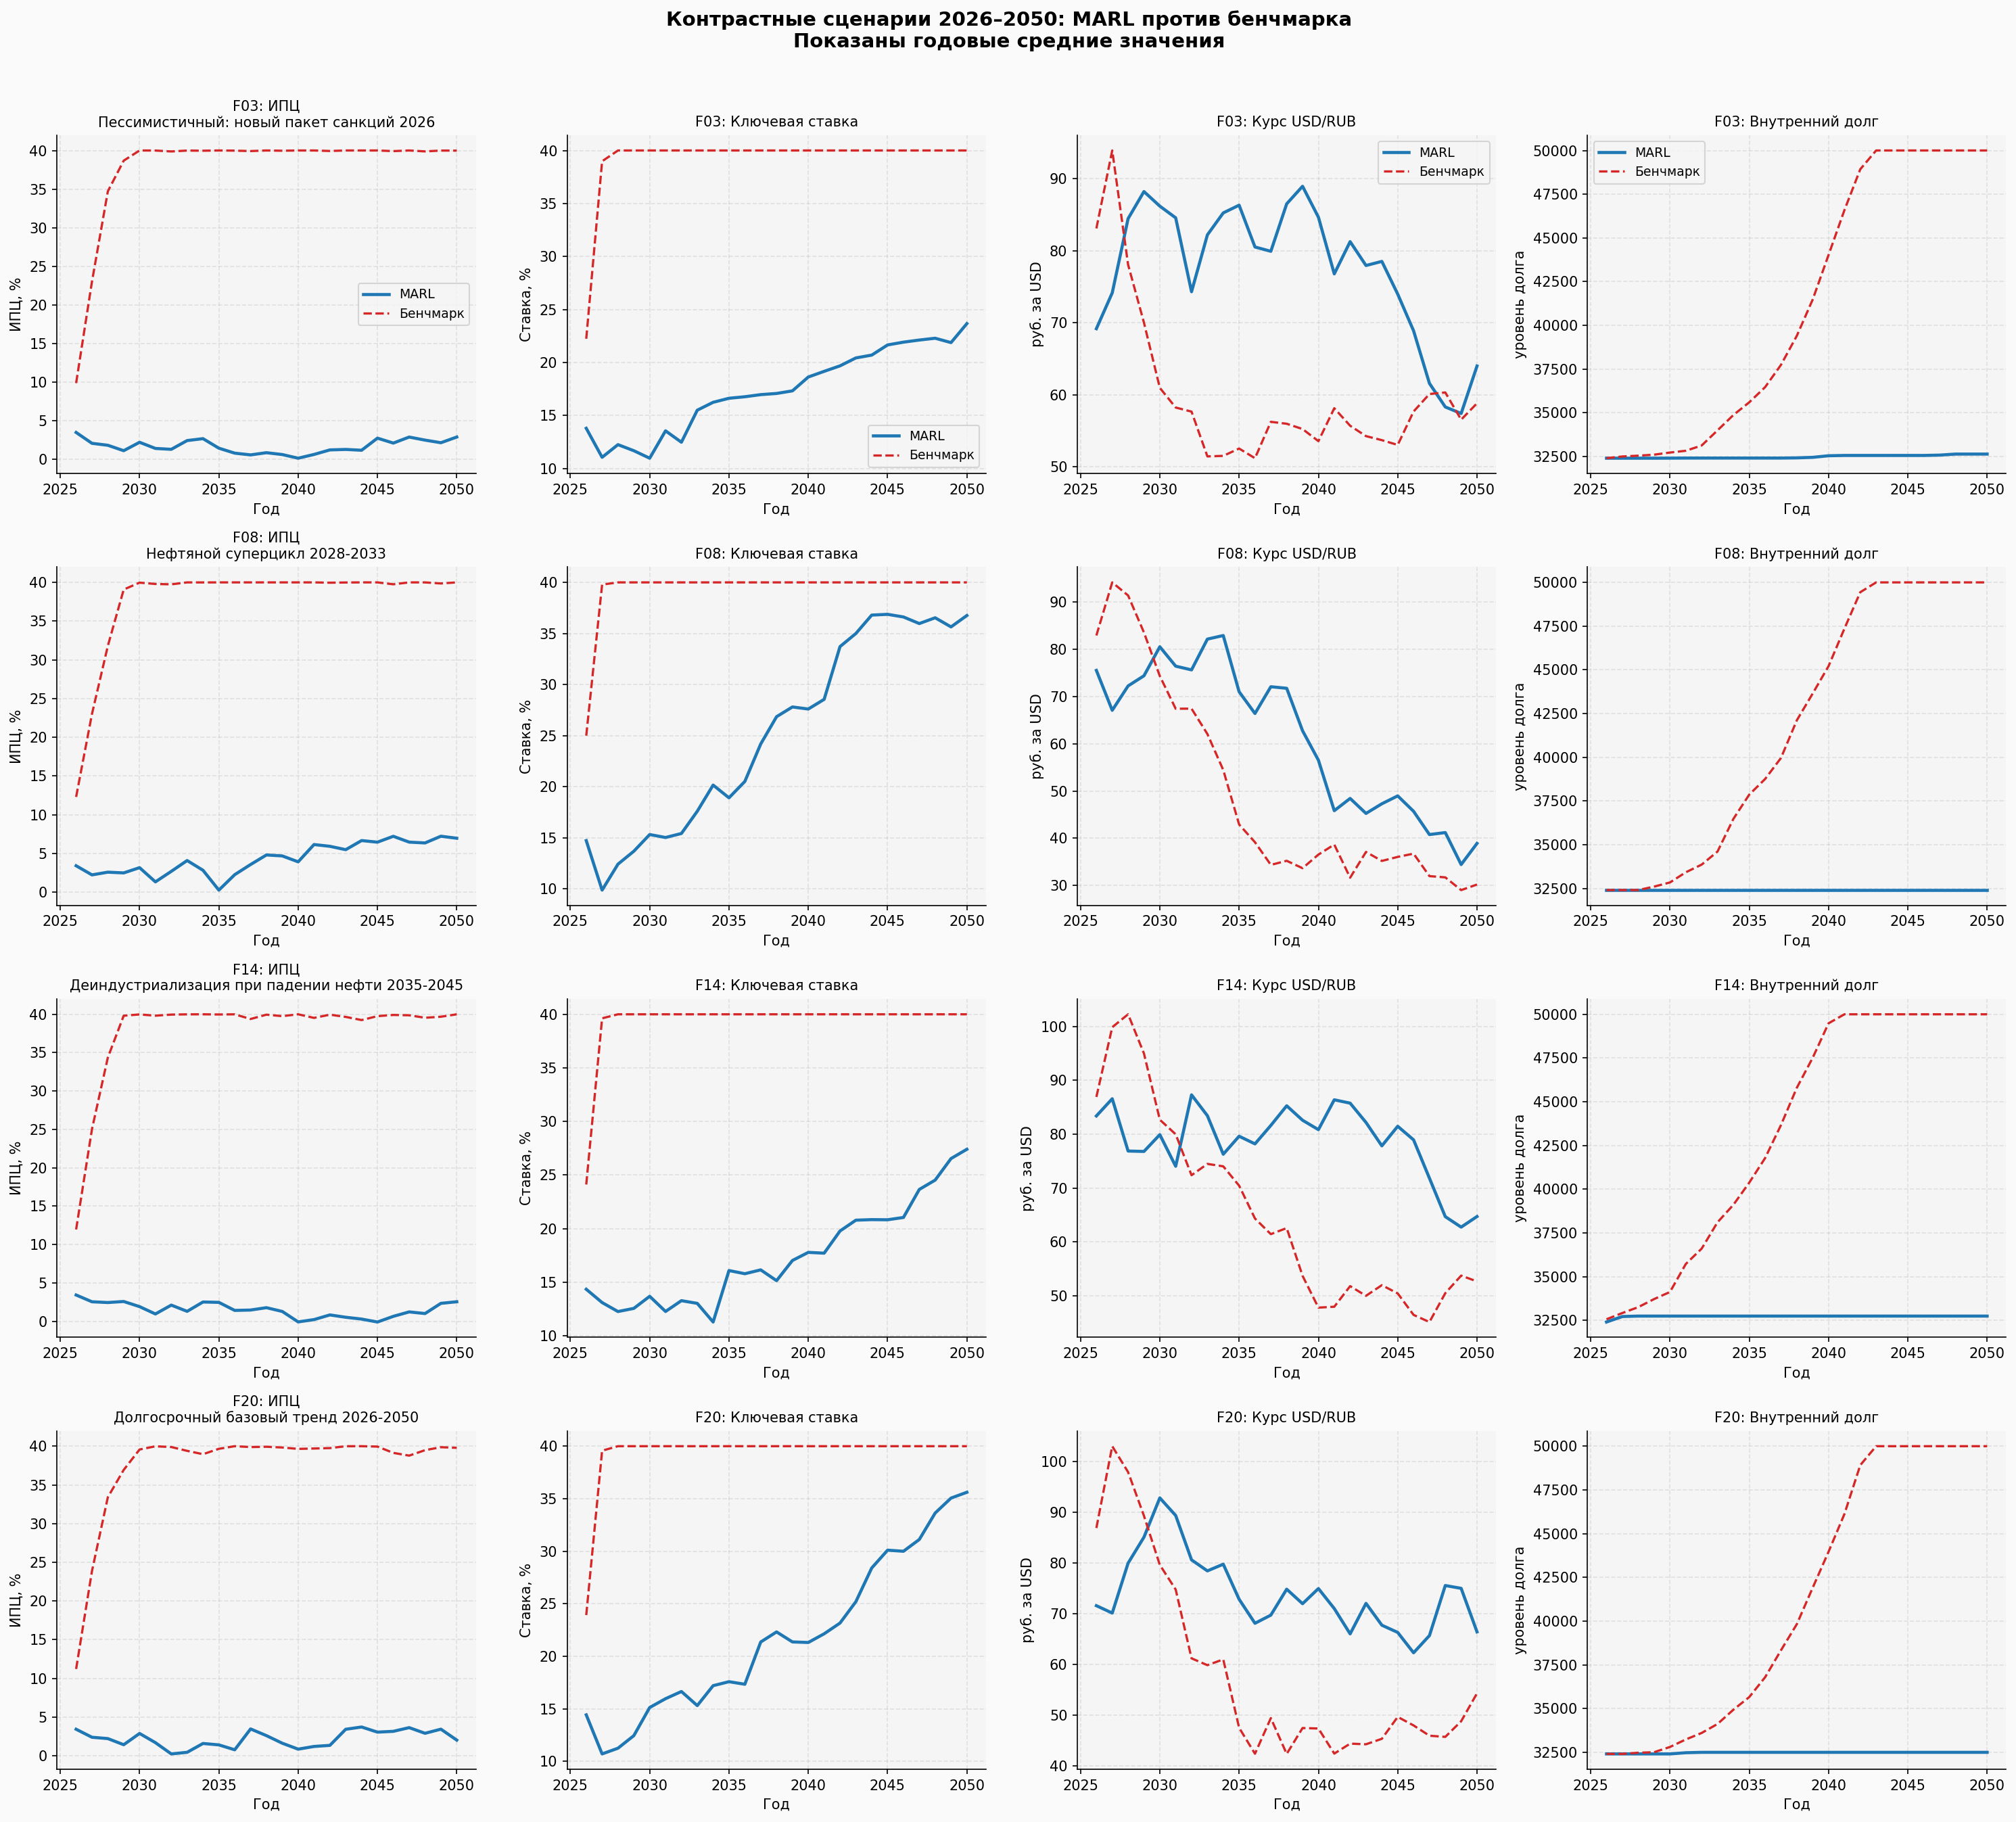

OK /content/output/contrast_scenarios_marl_vs_benchmark.png


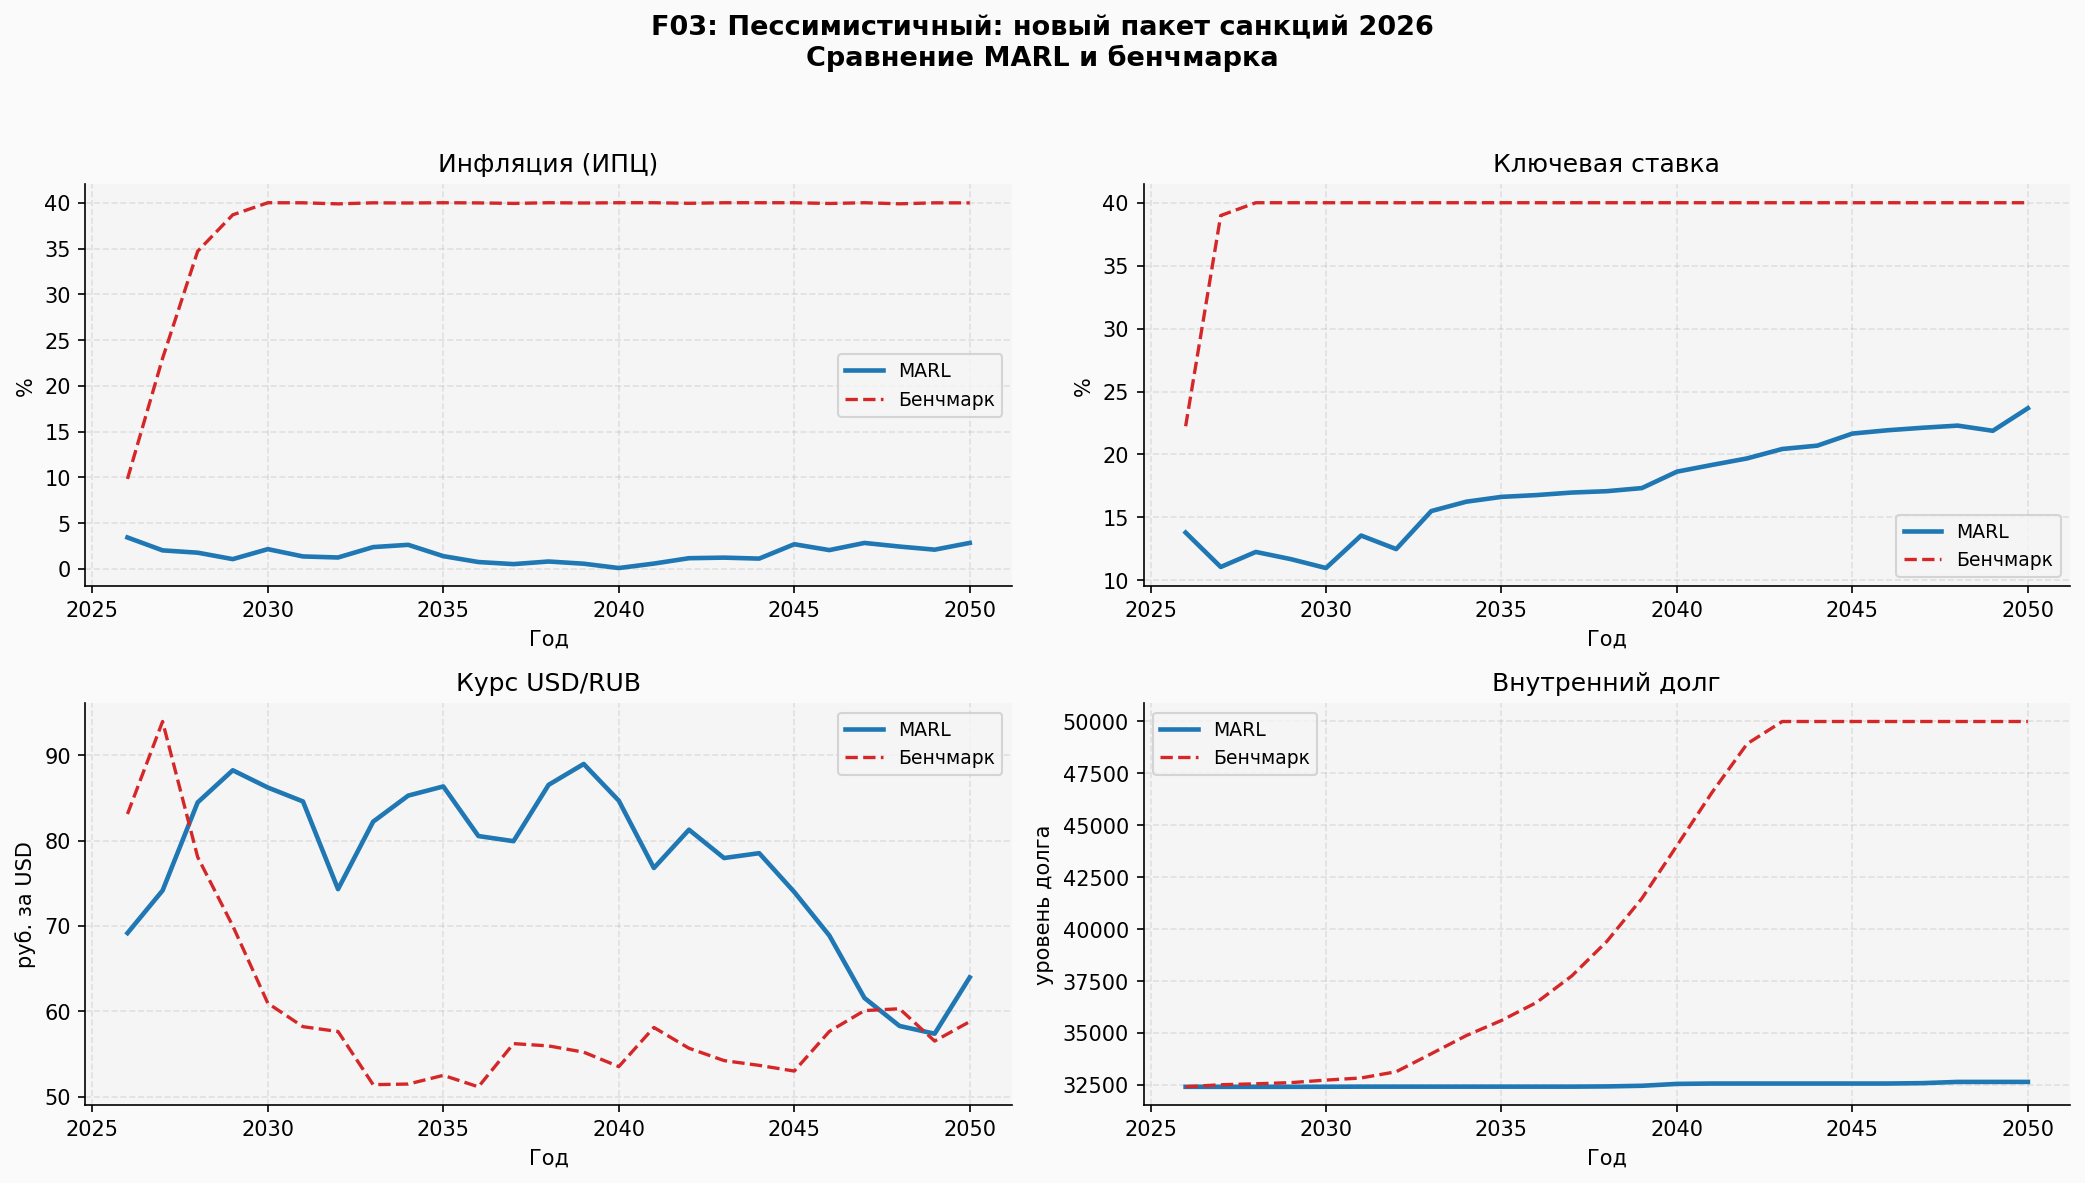

OK /content/output/f03_marl_vs_benchmark.png


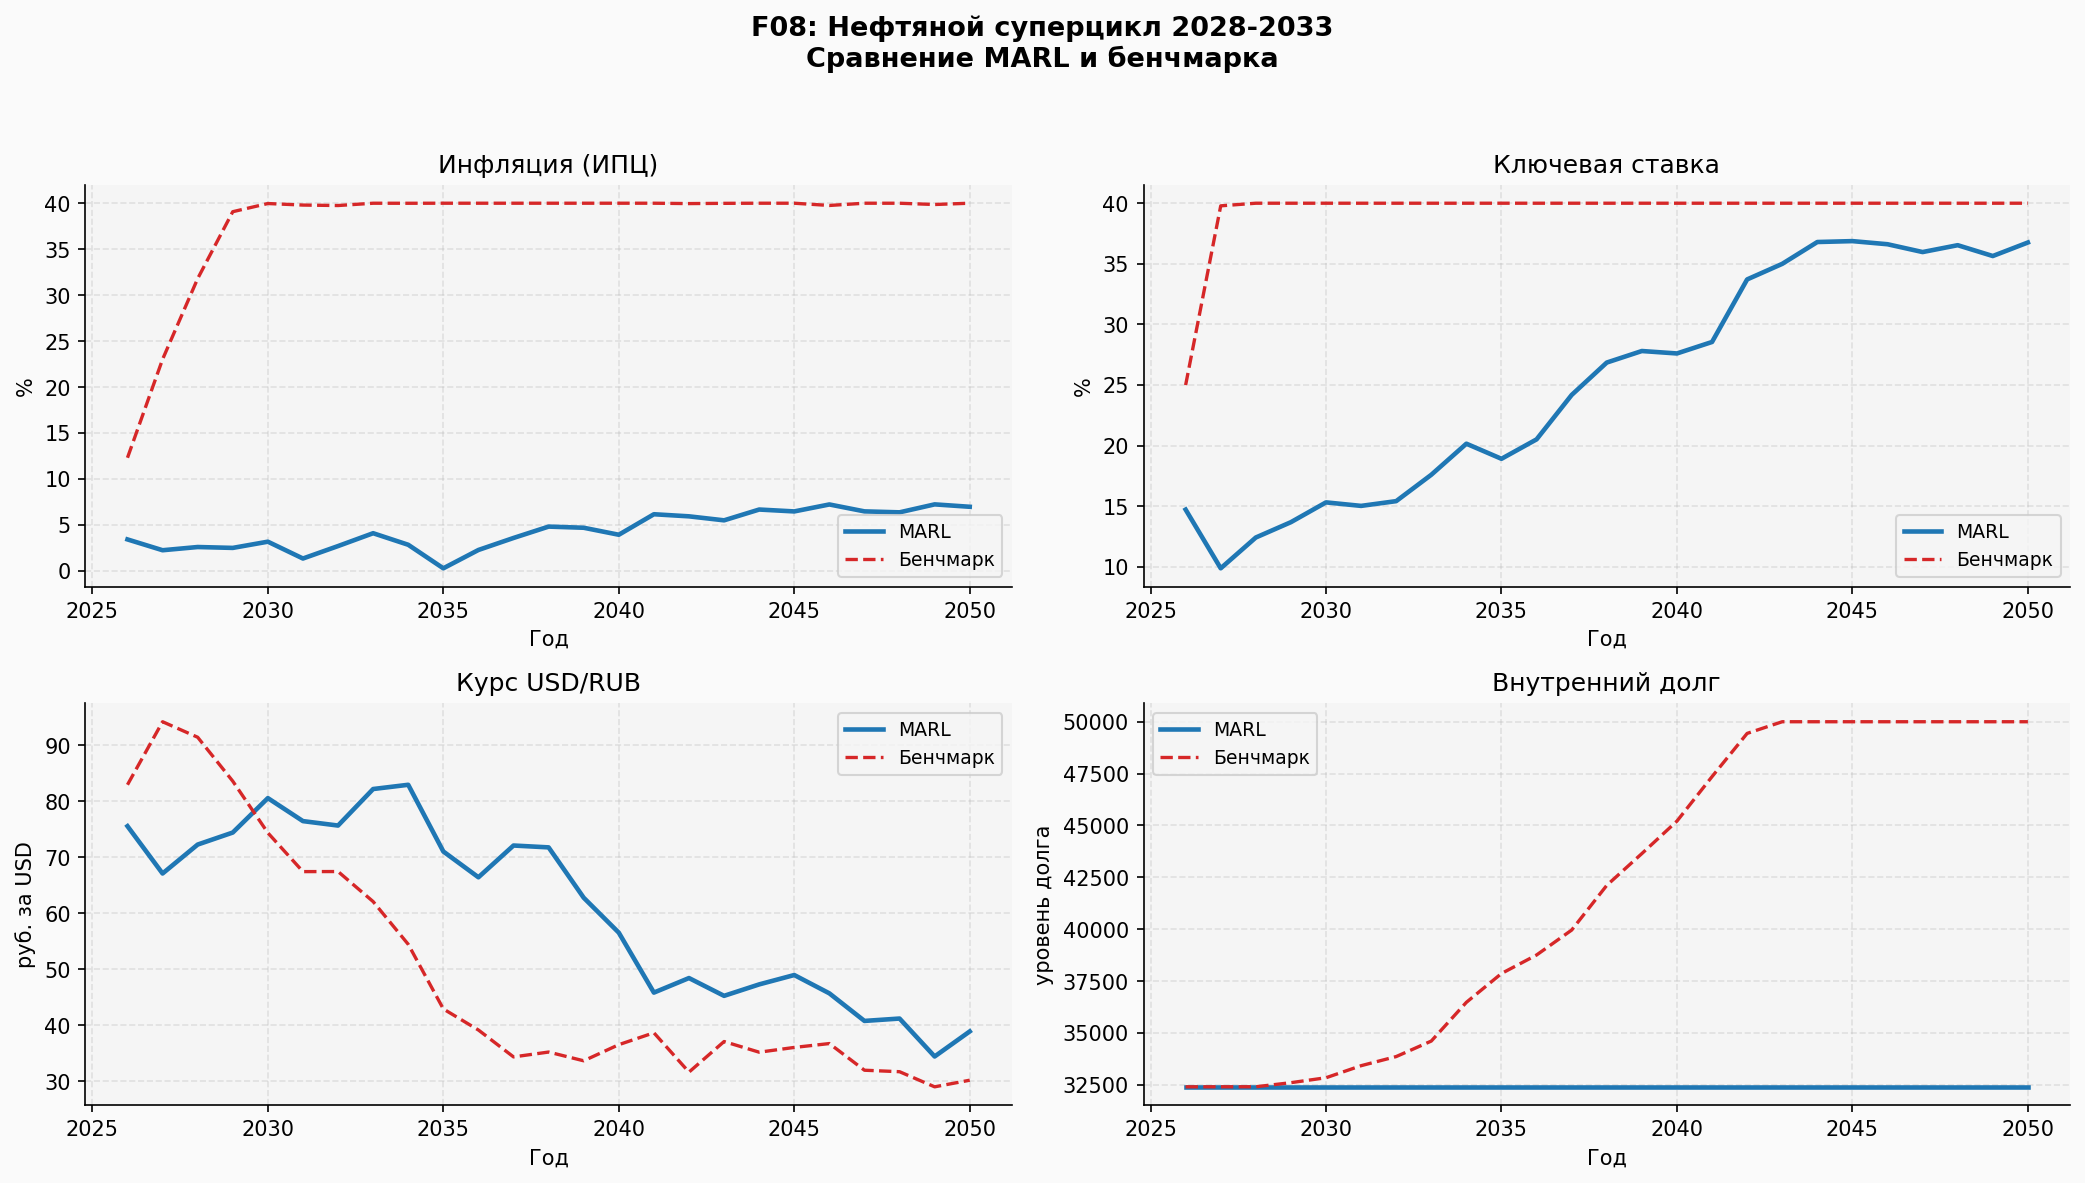

OK /content/output/f08_marl_vs_benchmark.png


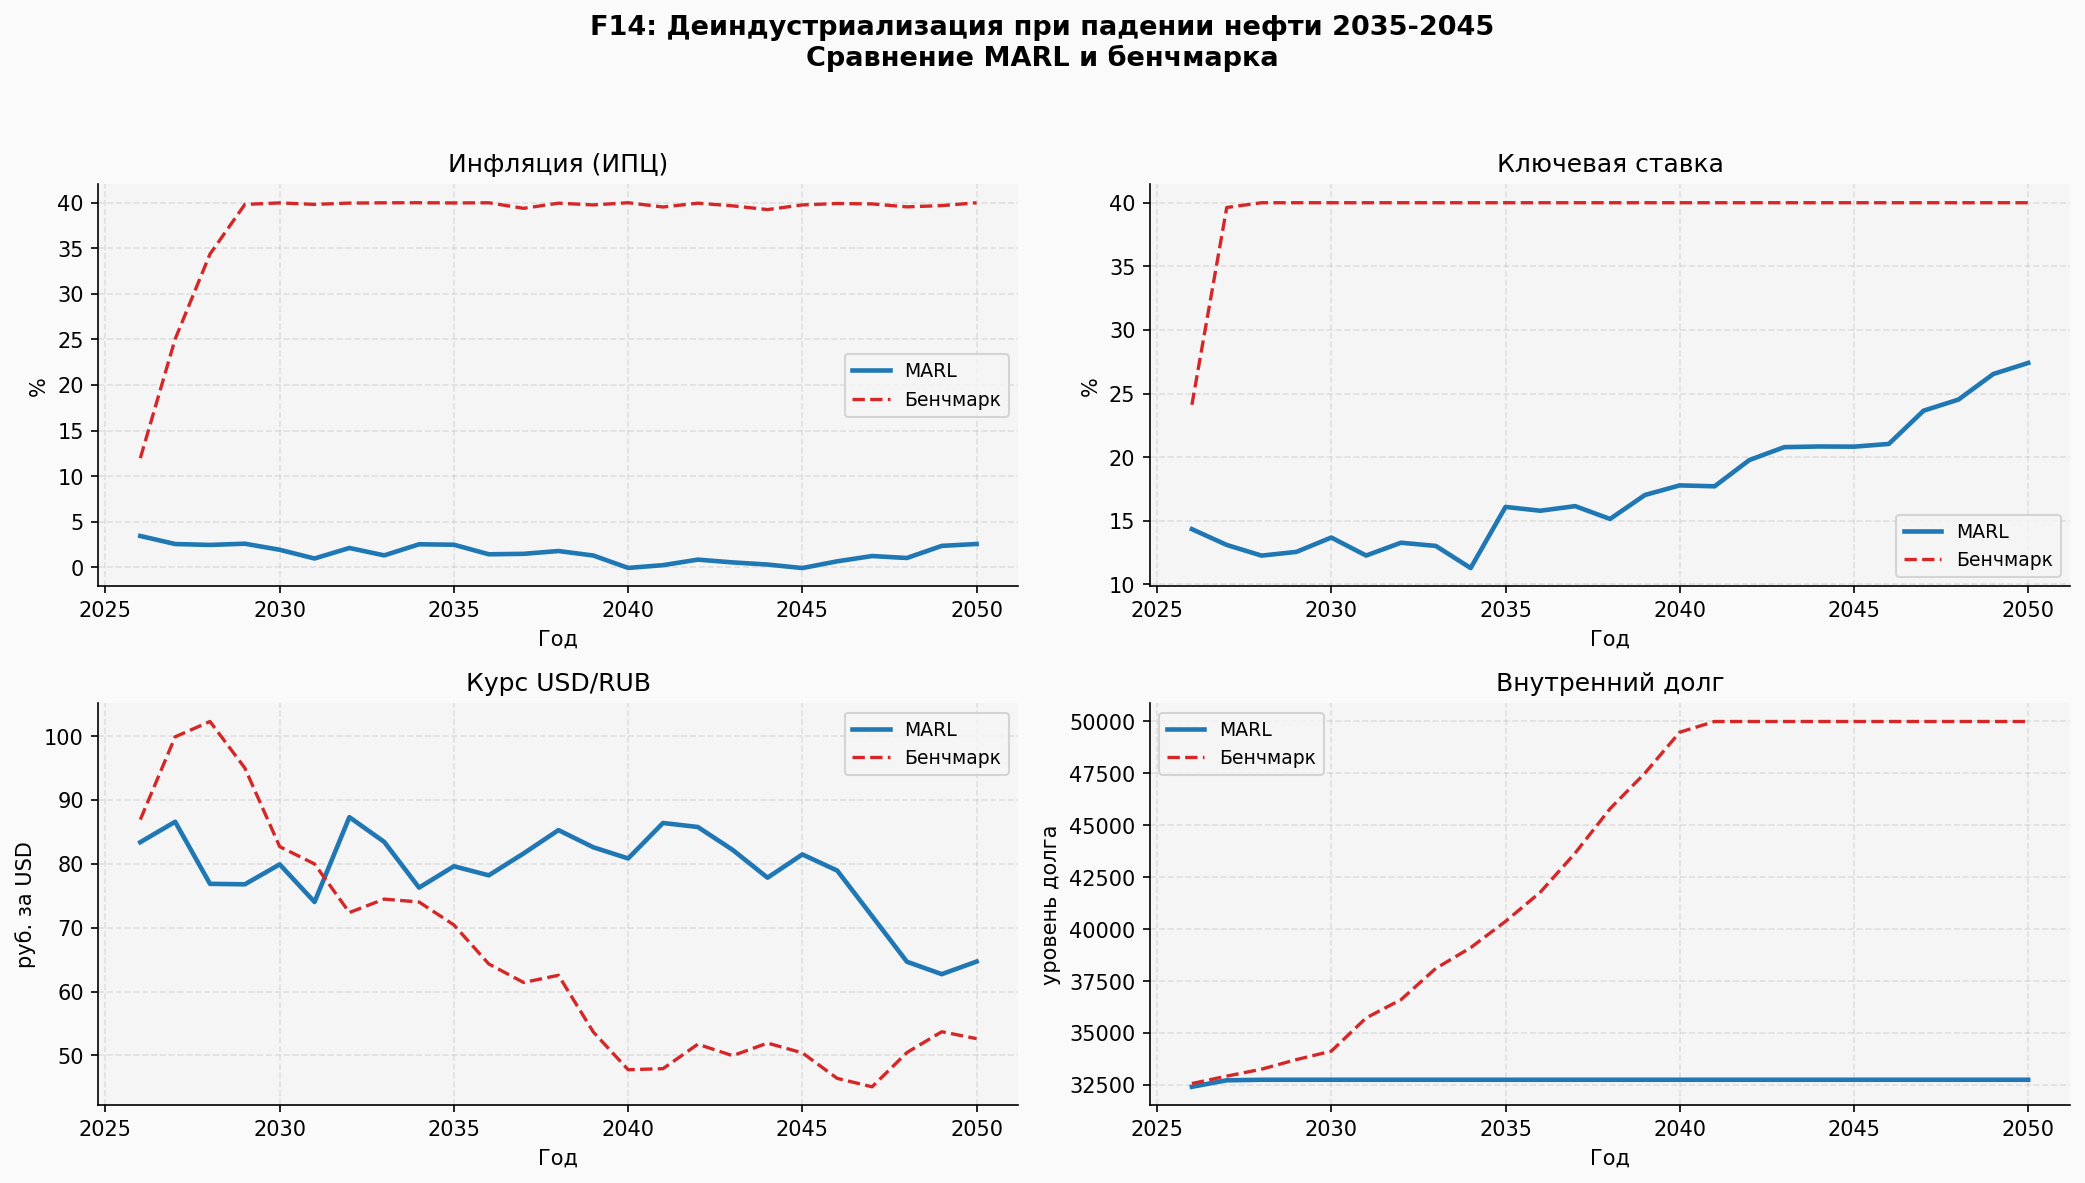

OK /content/output/f14_marl_vs_benchmark.png


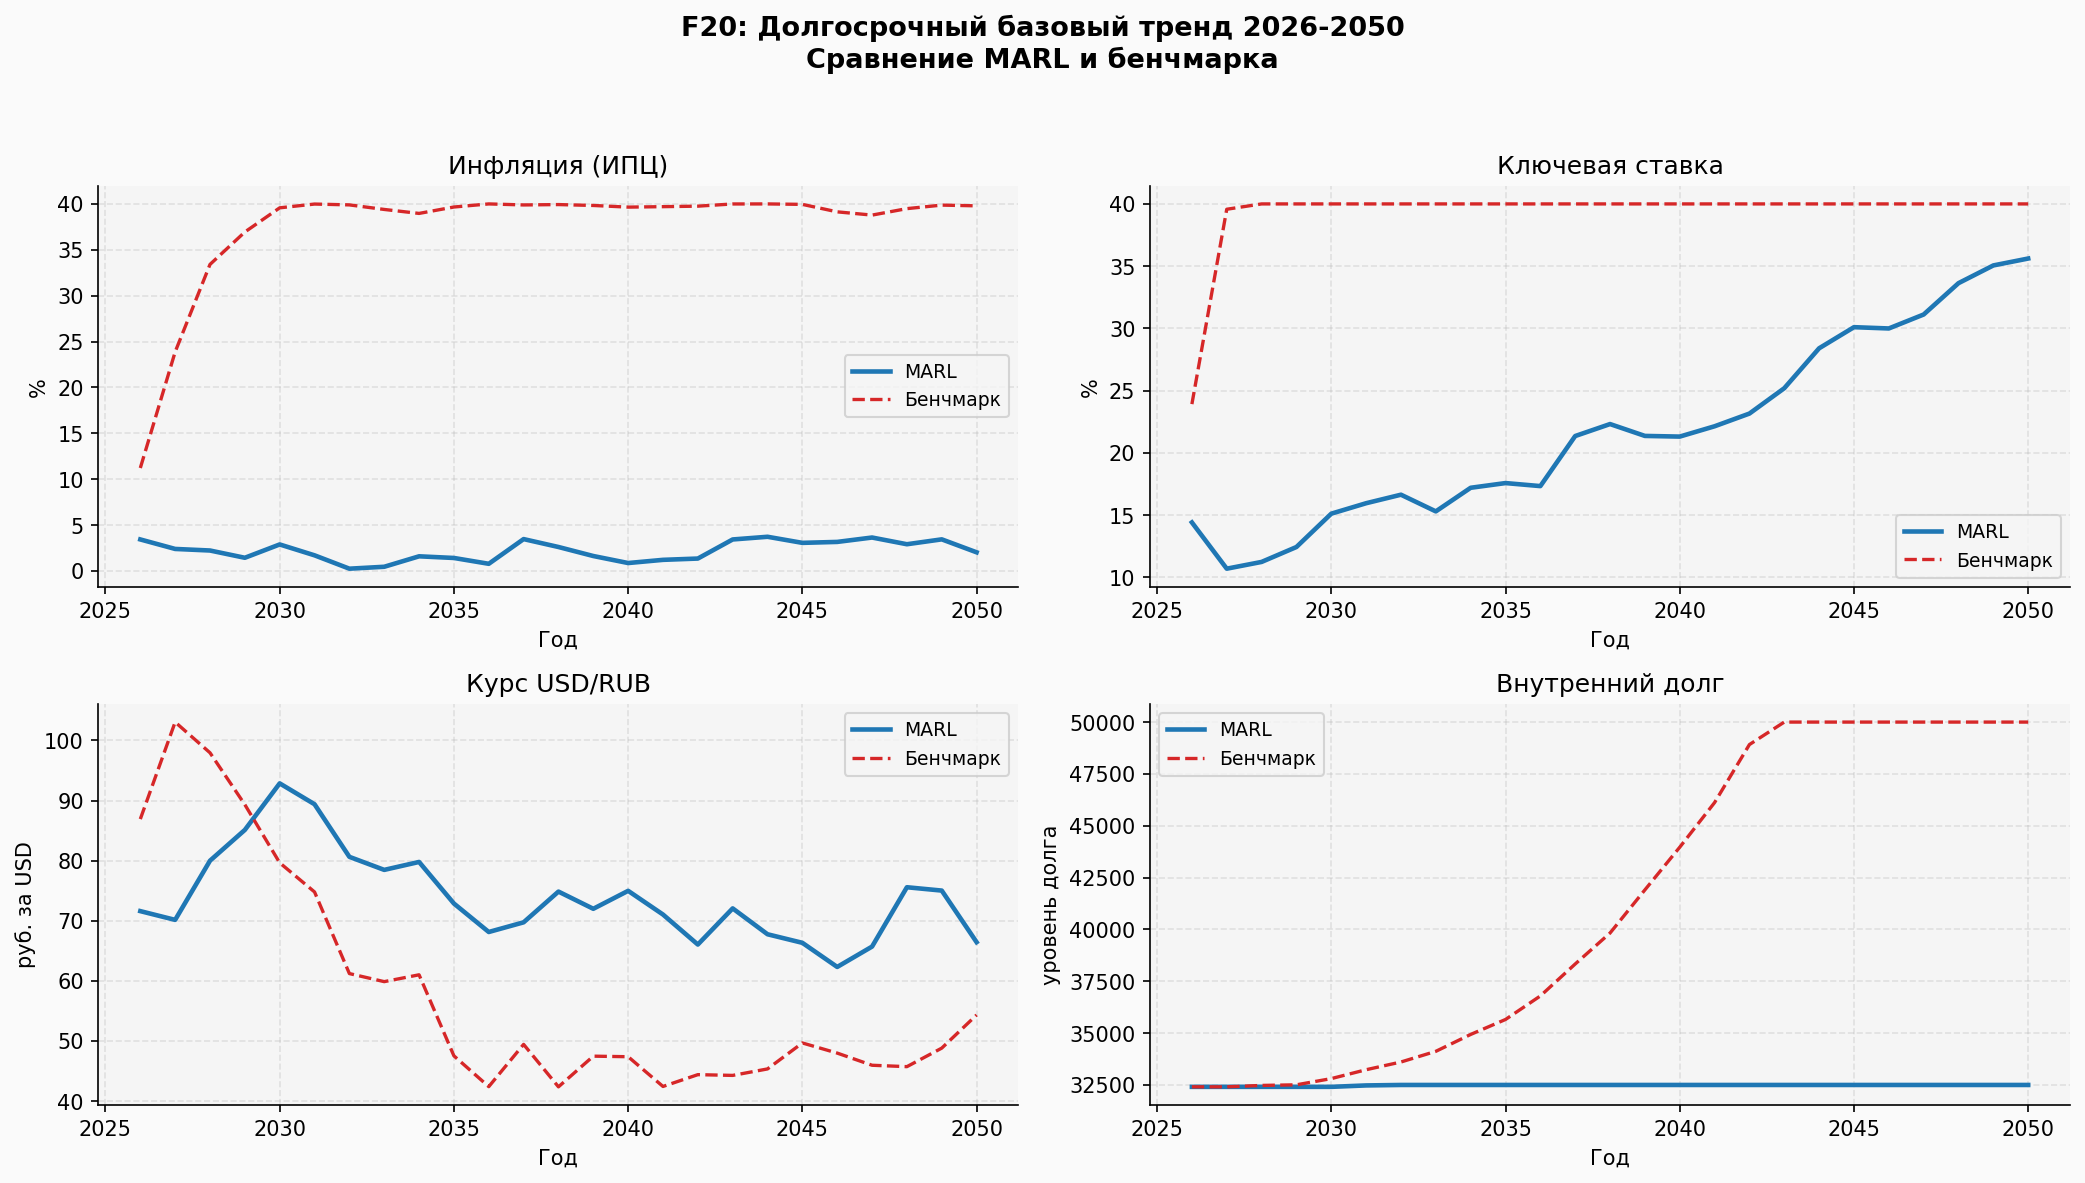

OK /content/output/f20_marl_vs_benchmark.png


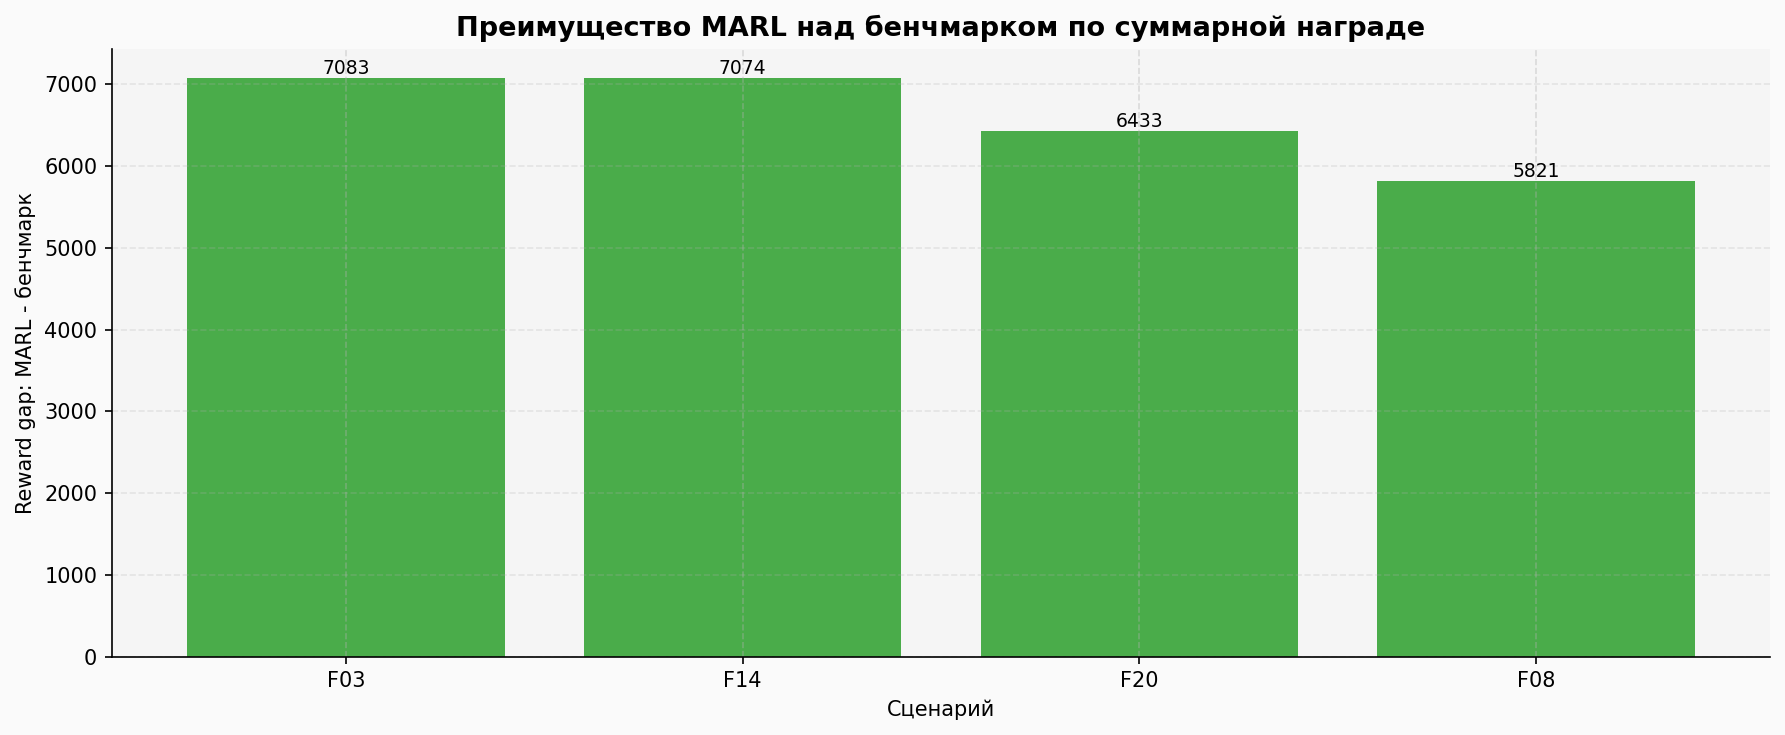

OK /content/output/contrast_scenarios_reward_gap.png


In [23]:
# =========================================================
# Subcell: Контрастные сценарии и графики MARL vs benchmark
# Рисует несколько сценариев с русскими подписями и названиями
# =========================================================
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- Настройка шрифта для кириллицы --------------------------------------
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

forecast_path = os.path.join(OUT_DIR, 'forecast_2026_2050.csv')
if not os.path.exists(forecast_path):
    raise FileNotFoundError('Не найден forecast_2026_2050.csv. Сначала выполните раздел 21.')

forecast_df = pd.read_csv(forecast_path, parse_dates=['date'])

# ---- Выбор контрастных сценариев -----------------------------------------
# Можно редактировать список вручную
CONTRAST_SCENARIOS = [
    'F03',  # Пессимистичный: новый пакет санкций 2026
    'F08',  # Нефтяной суперцикл 2028-2033
    'F14',  # Деиндустриализация при падении нефти 2035-2045
    'F20',  # Долгосрочный базовый тренд 2026-2050
]

contrast_df = forecast_df[forecast_df['scenario_id'].isin(CONTRAST_SCENARIOS)].copy()
if contrast_df.empty:
    raise ValueError('Не найдены выбранные сценарии в forecast_2026_2050.csv')

scenario_names = (
    contrast_df[['scenario_id', 'scenario_name']]
    .drop_duplicates()
    .sort_values('scenario_id')
    .set_index('scenario_id')['scenario_name']
    .to_dict()
)

# ---- Годовые средние для более чистых графиков ---------------------------
annual = (
    contrast_df
    .groupby(['scenario_id', 'scenario_name', 'year'], as_index=False)
    .mean(numeric_only=True)
    .sort_values(['scenario_id', 'year'])
)

# ---- Таблица краткого сравнения для вывода -------------------------------
summary_rows = []
for sc_id in CONTRAST_SCENARIOS:
    sub = annual[annual['scenario_id'] == sc_id].copy()
    if sub.empty:
        continue
    summary_rows.append({
        'scenario_id': sc_id,
        'scenario_name': scenario_names.get(sc_id, sc_id),
        'Средний ИПЦ MARL': round(float(sub['cpi_pct'].mean()), 2),
        'Средний ИПЦ benchmark': round(float(sub['benchmark_cpi_pct'].mean()), 2),
        'Средний курс MARL': round(float(sub['usd_rub'].mean()), 2),
        'Средний курс benchmark': round(float(sub['benchmark_usd_rub'].mean()), 2),
        'Средняя ставка MARL': round(float(sub['key_rate_pct'].mean()), 2),
        'Средняя ставка benchmark': round(float(sub['benchmark_key_rate_pct'].mean()), 2),
        'Средний долг MARL': round(float(sub['domestic_debt'].mean()), 2),
        'Средний долг benchmark': round(float(sub['benchmark_domestic_debt'].mean()), 2),
    })

contrast_summary_df = pd.DataFrame(summary_rows)
contrast_summary_path = os.path.join(OUT_DIR, 'contrast_scenarios_summary.csv')
contrast_summary_df.to_csv(contrast_summary_path, index=False, encoding='utf-8-sig')

print('Контрастные сценарии:')
print(contrast_summary_df.to_string(index=False))

# ---- 1. Большой мультиграфик: по сценарию отдельная строка ---------------
n_scen = len(CONTRAST_SCENARIOS)
fig, axes = plt.subplots(n_scen, 4, figsize=(20, 4.5 * n_scen), sharex=False)

if n_scen == 1:
    axes = np.array([axes])

for i, sc_id in enumerate(CONTRAST_SCENARIOS):
    sub = annual[annual['scenario_id'] == sc_id].copy()
    if sub.empty:
        continue

    scen_title = scenario_names.get(sc_id, sc_id)

    # ИПЦ
    ax = axes[i, 0]
    ax.plot(sub['year'], sub['cpi_pct'], lw=2.2, color='#1f77b4', label='MARL')
    ax.plot(sub['year'], sub['benchmark_cpi_pct'], lw=1.6, color='#d62728', ls='--', label='Бенчмарк')
    ax.set_title(f'{sc_id}: ИПЦ\n{scen_title}', fontsize=10)
    ax.set_xlabel('Год')
    ax.set_ylabel('ИПЦ, %')
    ax.grid(alpha=0.3)

    # Ключевая ставка
    ax = axes[i, 1]
    ax.plot(sub['year'], sub['key_rate_pct'], lw=2.2, color='#1f77b4', label='MARL')
    ax.plot(sub['year'], sub['benchmark_key_rate_pct'], lw=1.6, color='#d62728', ls='--', label='Бенчмарк')
    ax.set_title(f'{sc_id}: Ключевая ставка', fontsize=10)
    ax.set_xlabel('Год')
    ax.set_ylabel('Ставка, %')
    ax.grid(alpha=0.3)

    # USD/RUB
    ax = axes[i, 2]
    ax.plot(sub['year'], sub['usd_rub'], lw=2.2, color='#1f77b4', label='MARL')
    ax.plot(sub['year'], sub['benchmark_usd_rub'], lw=1.6, color='#d62728', ls='--', label='Бенчмарк')
    ax.set_title(f'{sc_id}: Курс USD/RUB', fontsize=10)
    ax.set_xlabel('Год')
    ax.set_ylabel('руб. за USD')
    ax.grid(alpha=0.3)

    # Долг
    ax = axes[i, 3]
    ax.plot(sub['year'], sub['domestic_debt'], lw=2.2, color='#1f77b4', label='MARL')
    ax.plot(sub['year'], sub['benchmark_domestic_debt'], lw=1.6, color='#d62728', ls='--', label='Бенчмарк')
    ax.set_title(f'{sc_id}: Внутренний долг', fontsize=10)
    ax.set_xlabel('Год')
    ax.set_ylabel('уровень долга')
    ax.grid(alpha=0.3)

for j in range(4):
    axes[0, j].legend(fontsize=9)

plt.suptitle(
    'Контрастные сценарии 2026–2050: MARL против бенчмарка\n'
    'Показаны годовые средние значения',
    fontsize=14,
    fontweight='bold',
    y=0.995
)
plt.tight_layout(rect=[0, 0, 1, 0.985])

fname_contrast_multi = os.path.join(OUT_DIR, 'contrast_scenarios_marl_vs_benchmark.png')
plt.savefig(fname_contrast_multi, bbox_inches='tight', dpi=160)
plt.show()
print(f'OK {fname_contrast_multi}')

# ---- 2. Отдельные фигуры по каждому сценарию -----------------------------
individual_files = []
for sc_id in CONTRAST_SCENARIOS:
    sub = annual[annual['scenario_id'] == sc_id].copy()
    if sub.empty:
        continue

    scen_title = scenario_names.get(sc_id, sc_id)

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    fig.suptitle(f'{sc_id}: {scen_title}\nСравнение MARL и бенчмарка', fontsize=13, fontweight='bold')

    # ИПЦ
    ax = axes[0, 0]
    ax.plot(sub['year'], sub['cpi_pct'], color='#1f77b4', lw=2.2, label='MARL')
    ax.plot(sub['year'], sub['benchmark_cpi_pct'], color='#d62728', lw=1.6, ls='--', label='Бенчмарк')
    ax.set_title('Инфляция (ИПЦ)')
    ax.set_xlabel('Год')
    ax.set_ylabel('%')
    ax.grid(alpha=0.3)
    ax.legend()

    # Ключевая ставка
    ax = axes[0, 1]
    ax.plot(sub['year'], sub['key_rate_pct'], color='#1f77b4', lw=2.2, label='MARL')
    ax.plot(sub['year'], sub['benchmark_key_rate_pct'], color='#d62728', lw=1.6, ls='--', label='Бенчмарк')
    ax.set_title('Ключевая ставка')
    ax.set_xlabel('Год')
    ax.set_ylabel('%')
    ax.grid(alpha=0.3)
    ax.legend()

    # Курс
    ax = axes[1, 0]
    ax.plot(sub['year'], sub['usd_rub'], color='#1f77b4', lw=2.2, label='MARL')
    ax.plot(sub['year'], sub['benchmark_usd_rub'], color='#d62728', lw=1.6, ls='--', label='Бенчмарк')
    ax.set_title('Курс USD/RUB')
    ax.set_xlabel('Год')
    ax.set_ylabel('руб. за USD')
    ax.grid(alpha=0.3)
    ax.legend()

    # Долг
    ax = axes[1, 1]
    ax.plot(sub['year'], sub['domestic_debt'], color='#1f77b4', lw=2.2, label='MARL')
    ax.plot(sub['year'], sub['benchmark_domestic_debt'], color='#d62728', lw=1.6, ls='--', label='Бенчмарк')
    ax.set_title('Внутренний долг')
    ax.set_xlabel('Год')
    ax.set_ylabel('уровень долга')
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    out_path = os.path.join(OUT_DIR, f'{sc_id.lower()}_marl_vs_benchmark.png')
    plt.savefig(out_path, bbox_inches='tight', dpi=160)
    plt.show()
    individual_files.append(out_path)
    print(f'OK {out_path}')

# ---- 3. Дополнительный график reward-gap по контрастным сценариям --------
if os.path.exists(os.path.join(OUT_DIR, 'forecast_summary_by_scenario.csv')):
    scen_sum = pd.read_csv(os.path.join(OUT_DIR, 'forecast_summary_by_scenario.csv'))
    scen_sum = scen_sum[scen_sum['scenario_id'].isin(CONTRAST_SCENARIOS)].copy()
    scen_sum = scen_sum.sort_values('reward_gap_marl_minus_benchmark', ascending=False)

    plt.figure(figsize=(12, 5))
    bars = plt.bar(
        scen_sum['scenario_id'],
        scen_sum['reward_gap_marl_minus_benchmark'],
        color='#2ca02c',
        alpha=0.85
    )
    plt.title('Преимущество MARL над бенчмарком по суммарной награде', fontsize=13, fontweight='bold')
    plt.xlabel('Сценарий')
    plt.ylabel('Reward gap: MARL - бенчмарк')
    plt.grid(axis='y', alpha=0.25)

    for bar, (_, row) in zip(bars, scen_sum.iterrows()):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f'{row["reward_gap_marl_minus_benchmark"]:.0f}',
            ha='center',
            va='bottom',
            fontsize=9
        )

    plt.tight_layout()
    fname_gap = os.path.join(OUT_DIR, 'contrast_scenarios_reward_gap.png')
    plt.savefig(fname_gap, bbox_inches='tight', dpi=160)
    plt.show()
    print(f'OK {fname_gap}')

---
## Раздел 23. Выводы и политические импликации



#### Часть II: MARL-эксперимент

- **MacroFinEnv**: эконометрически откалиброванная среда в целом воспроизводит ключевые макрофинансовые связи РФ 2011–2026 и пригодна для сценарного policy-анализа в пределах модельных допущений.
- **MADDPG** (7 агентов: ЦБ, Минфин, ФНС, ФАС, МЭР, банки, реальный сектор): сходится к устойчивой совместной политике за ~200–300 эпизодов; в эксперименте использовано 600 эпизодов с ранней остановкой и восстановлением лучшей конфигурации.
- **Координированная политика**: обученная MARL-policy систематически превосходит rule-based benchmark по суммарной награде во всех протестированных сценариях 2026–2050, одновременно обеспечивая более низкую инфляцию, более устойчивый бюджетный баланс и меньшую долговую нагрузку внутри модели.
- **Прогноз 2026–2050**: сценарные траектории следует интерпретировать как условные результаты в калиброванной среде, а не как точечный макроэкономический прогноз; содержательно они показывают, что координация денежно-кредитной, фискальной и банковской политики повышает устойчивость к нефтяным и санкционным шокам.


#### Ключевые политические рекомендации

1. **Фискальная консолидация**: снижение ненефтяного дефицита остаётся ключевым условием долговой устойчивости, особенно в сценариях низкой нефти и ослабления нефтегазовых доходов.
2. **Диверсификация экспорта**: дальнейшее развитие несырьевого экспорта и ненефтегазовой доходной базы снижает зависимость от нефтяного цикла и повышает устойчивость к внешним ограничениям.
3. **ДКП в условиях санкций**: жёсткая денежно-кредитная реакция помогает сдерживать инфляцию, но максимальный эффект достигается только при координации с фискальной политикой, а не в изоляции.
4. **Долговая устойчивость**: при ухудшении внешней конъюнктуры риск ускоренного накопления долга быстро возрастает, поэтому контроль дефицита и бюджетное правило критичны на длинном горизонте.
5. **Валютная диверсификация**: расширение расчётов в CNY и национальных валютах снижает часть санкционных рисков, но создаёт новые каналы внешней зависимости и не устраняет макрофинансовые ограничения полностью.


#### Ограничения

- Данные Росстата и Банка России имеют естественные статистические и институциональные ограничения; результаты чувствительны к выбору точки структурного разлома и спецификации выборки.
- MADDPG чувствителен к гиперпараметрам, длине обучения и составу сценарного пространства; найденная политика является практически устойчивым решением, но не доказанным глобальным оптимумом.
- Макроэконометрические уравнения среды опираются на исторически оценённые зависимости; структурные изломы после 2022 года могут снижать точность долгосрочных сценарных траекторий.


---
## Раздел 24. Экспорт артефактов

Все CSV и PNG из `output/` упаковываются в ZIP-архив.


In [24]:
import os, zipfile, glob as _glob, hashlib, pandas as pd
from datetime import datetime

zip_path = os.path.join(OUT_DIR, 'russia_finstability_marl_results.zip')
manifest_path = os.path.join(OUT_DIR, 'artifact_manifest.csv')

artifacts = []
for ext in ('*.csv', '*.png', '*.md', '*.html', '*.xlsx', '*.pdf'):
    artifacts.extend(_glob.glob(os.path.join(OUT_DIR, ext)))

artifacts = sorted(set(f for f in artifacts if os.path.isfile(f)))
artifacts = [f for f in artifacts if os.path.abspath(f) != os.path.abspath(zip_path)]

manifest_rows = []
for fpath in artifacts:
    manifest_rows.append({
        'file_name': os.path.basename(fpath),
        'file_path': fpath,
        'size_bytes': os.path.getsize(fpath),
        'modified_utc': datetime.utcfromtimestamp(os.path.getmtime(fpath)).isoformat()
    })

manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(manifest_path, index=False, encoding='utf-8-sig')

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    zf.write(manifest_path, os.path.basename(manifest_path))
    print(f'  + {os.path.basename(manifest_path)} ({os.path.getsize(manifest_path):,} bytes)')
    for fpath in artifacts:
        arcname = os.path.basename(fpath)
        zf.write(fpath, arcname)
        print(f'  + {arcname} ({os.path.getsize(fpath):,} bytes)')

sha256 = hashlib.sha256()
with open(zip_path, 'rb') as f:
    for chunk in iter(lambda: f.read(1024 * 1024), b''):
        sha256.update(chunk)

hash_path = os.path.join(OUT_DIR, 'russia_finstability_marl_results.sha256.txt')
with open(hash_path, 'w', encoding='utf-8') as f:
    f.write(f'{sha256.hexdigest()}  {os.path.basename(zip_path)}\n')

print(f'\nOK ZIP создан: {zip_path}')
print(f'OK Артефактов в архиве: {len(artifacts) + 1}')
print(f'OK SHA256: {sha256.hexdigest()}')
print(f'OK Manifest: {manifest_path}')
print('\n=== ПАЙПЛАЙН ЗАВЕРШЁН ===')
print('Воспроизводимый научный ноутбук: Финансовая устойчивость РФ')
print('Часть I: ETL + H1-H5 | Часть II: MacroFinEnv + MADDPG + Сценарии + Прогноз 2026-2050')


  + artifact_manifest.csv (4,249 bytes)
  + contrast_scenarios_marl_vs_benchmark.png (807,386 bytes)
  + contrast_scenarios_reward_gap.png (63,749 bytes)
  + contrast_scenarios_summary.csv (768 bytes)
  + corr_matrix.csv (1,658 bytes)
  + env_transition_coeffs.csv (5,578 bytes)
  + expenditure_structure.csv (296 bytes)
  + f03_marl_vs_benchmark.png (227,034 bytes)
  + f08_marl_vs_benchmark.png (226,767 bytes)
  + f14_marl_vs_benchmark.png (227,042 bytes)
  + f20_marl_vs_benchmark.png (232,714 bytes)
  + factor_importance_marl.csv (303 bytes)
  + fig0_data_coverage.png (97,267 bytes)
  + fig10_expenditure_structure.png (71,574 bytes)
  + fig1_overview.png (389,318 bytes)
  + fig2_commodity_heatmap.png (172,022 bytes)
  + fig3_h1_passthrough.png (109,446 bytes)
  + fig4_h2_oil_regimes.png (131,459 bytes)
  + fig5_h3_debt_substitution.png (145,598 bytes)
  + fig6_h4_structural_break.png (302,352 bytes)
  + fig7_h5_diversification.png (105,428 bytes)
  + fig8_correlation_matrix.png (246,20